# UPSAMPLING / SUBSAMPLING - notebook riepilogativo pulito

Versione semplificata: mantiene solo i due protocolli finali sul dataset originale.

Preset disponibili:
- `train_upsampling_original`
- `subsampling_cv_plus_final_refit_original`


In [ ]:
# ============================================================
# 1. CONFIGURAZIONE ESPERIMENTO - MODIFICA SOLO QUI
# ============================================================

from pathlib import Path

REPO_ROOT = Path.cwd().resolve()

CONFIG = {
    # ========================================================
    # SCENARIO ESPERIMENTO
    # ========================================================
    # Preset disponibili:
    # - "train_upsampling_original": split 80/10/10, upsampling solo train, training, test.
    # - "subsampling_cv_plus_final_refit_original": subsampling, 5-fold CV, final refit, test.
    "EXPERIMENT_PRESET": "subsampling_cv_plus_final_refit_original",

    # ========================================================
    # MODELLO
    # ========================================================
    "MODEL_NAME": "resnet18",       # "lenet", "alexnet", "vggnet", "resnet18", "resnet34", "mobilenetv2", "mobilenetv3_small", "mobilenetv3_large", "squeezenet", "efficientnet_b0", "googlenet", "xception", "resnet50", "vit_tiny_patch16_224", "vit_small_patch16_224", "vit_base_patch16_224", "dinov2_vit_small_patch14", "dinov2_vit_base_patch14"
    "TRANSFER_MODE": "scratch",  # "scratch", "feature_extract", "fine_tune"
    "OPTIMIZER_NAME": "adam",      # "sgd", "nesterov", "rmsprop", "adagrad", "adadelta", "adam", "adamax", "amsgrad", "adamw"

    # ========================================================
    # TRAINING
    # ========================================================
    "NUM_EPOCHS": 5,
    "BATCH_SIZE_OVERRIDE": 32,
    "LEARNING_RATE": 1e-4,
    "WEIGHT_DECAY": 5e-4,
    "MAX_TRAIN_SAMPLES": None,
    "MAX_VAL_SAMPLES": None,

    # ========================================================
    # TRAINING CONTROL
    # ========================================================
    "EARLY_STOPPING_ENABLED": True,
    "EARLY_STOPPING_PATIENCE": 10,
    "EARLY_STOPPING_MIN_DELTA": 0.001,

    "LR_SCHEDULER_NAME": "auto",   # "auto", "plateau", "warmup_cosine", "none"

    "WARMUP_EPOCHS": 3,
    "COSINE_MIN_LR": 1e-7,

    "LR_SCHEDULER_ENABLED": True,
    "LR_SCHEDULER_PATIENCE": 3,
    "LR_SCHEDULER_FACTOR": 0.2,
    "LR_SCHEDULER_MIN_LR": 1e-7,

    "GRADIENT_CLIPPING_ENABLED": True,
    "GRADIENT_CLIP_MAX_NORM": 1.0,
    "GRADIENT_CLIPPING_MODE": "auto",  # "auto", "always", "none"

    # ========================================================
    # DATASET
    # ========================================================
    "DATASET_DRIVE_DIR": str(REPO_ROOT / "_external_dataset"),
    "DATASET_LOCAL_DIR": str(REPO_ROOT / "_external_dataset"),
    "USE_TAR_LOCAL_DATASET": True,

    "TAR_ORIGINAL_PATH": str(REPO_ROOT / "_external_dataset" / "Comics_original_224.tar"),

    # Per il preset train_upsampling_original:
    # True  -> usa il TAR delle immagini augmentate, se esiste già.
    # False -> usa/copia direttamente la cartella augmentata generata dal notebook.
    # Nel subsampling questi due parametri vengono semplicemente ignorati.
    "USE_TAR_AUGMENTED_UPSAMPLING": True,
    "TAR_AUG_ORIGINAL_PATH": str(REPO_ROOT / "_external_dataset" / "augmented_train_only_original_seed42_test0p1.tar"),

    "SEED": 42,
    "TEST_SIZE": 0.10,
    "N_SPLITS": 5,

    # ========================================================
    # AUGMENTATION EXTRA NEL SUBSAMPLING
    # ========================================================
    "SUBSAMPLING_TRAIN_AUGMENT_OFFLINE": False,
    "SUBSAMPLING_TRAIN_AUGMENT_RATIO": 0.15,

    # ========================================================
    # PERFORMANCE / COLAB
    # ========================================================
    "FAST_DEV_RUN": False,
    "NUM_WORKERS": 0,
    "PRELOAD_TO_RAM": True,
    "PIN_MEMORY": True,
    "USE_AMP": True,
    "RESIZE_MODE": "if_needed",
}


def apply_experiment_preset(config: dict) -> dict:
    """
    Applica uno dei due preset riepilogativi mantenuti nel notebook.

    Preset disponibili:
    - train_upsampling_original:
      split train/validation/test sul dataset originale, upsampling solo del train,
      training e test finale.
    - subsampling_cv_plus_final_refit_original:
      intero protocollo subsampling sul dataset originale:
      5-fold cross-validation, test del best fold, final refit su train+validation
      e test del modello finale.
    """
    config = config.copy()
    preset = config["EXPERIMENT_PRESET"]

    if preset == "train_upsampling_original":
        config["SAMPLING_MODE"] = "upsampling"

    elif preset == "subsampling_cv_plus_final_refit_original":
        config["SAMPLING_MODE"] = "subsampling"

    else:
        allowed = [
            "train_upsampling_original",
            "subsampling_cv_plus_final_refit_original",
        ]
        raise ValueError(
            f"EXPERIMENT_PRESET non riconosciuto: {preset}. "
            f"Preset validi: {allowed}"
        )

    return config


def print_effective_config_summary(config: dict):
    """
    Stampa un riepilogo leggibile delle configurazioni realmente usate.
    Le opzioni interne non modificabili dall'utente sono derivate automaticamente dal preset.
    """

    preset = config["EXPERIMENT_PRESET"]
    sampling_mode = config["SAMPLING_MODE"]

    print("\n" + "=" * 70)
    print("CONFIGURAZIONE EFFETTIVA ESPERIMENTO")
    print("=" * 70)

    print("\n[SCENARIO]")
    print(f"Preset: {preset}")
    print(f"Sampling mode effettivo: {sampling_mode}")
    print("Dataset usato: Comics originale")

    if sampling_mode == "upsampling":
        print("Flusso: split train/validation/test -> upsampling solo train -> training -> test finale")
    else:
        print("Flusso: subsampling bilanciato -> 5-fold CV -> test best fold -> final refit -> test finale")

    print("\n[MODELLO]")
    print(f"MODEL_NAME: {config['MODEL_NAME']}")
    print(f"TRANSFER_MODE: {config['TRANSFER_MODE']}")
    print(f"OPTIMIZER_NAME: {config['OPTIMIZER_NAME']}")

    print("\n[TRAINING]")
    print(f"NUM_EPOCHS: {config['NUM_EPOCHS']}")
    print(f"BATCH_SIZE_OVERRIDE: {config['BATCH_SIZE_OVERRIDE']}")
    print(f"LEARNING_RATE: {config['LEARNING_RATE']}")
    print(f"WEIGHT_DECAY: {config['WEIGHT_DECAY']}")
    print(f"EARLY_STOPPING_ENABLED: {config['EARLY_STOPPING_ENABLED']}")
    print(f"EARLY_STOPPING_PATIENCE: {config['EARLY_STOPPING_PATIENCE']}")
    print(f"EARLY_STOPPING_MIN_DELTA: {config['EARLY_STOPPING_MIN_DELTA']}")

    print(f"LR_SCHEDULER_ENABLED: {config['LR_SCHEDULER_ENABLED']}")
    print(f"LR_SCHEDULER_NAME: {config.get('LR_SCHEDULER_NAME', 'auto')}")
    print(f"WARMUP_EPOCHS: {config.get('WARMUP_EPOCHS', 3)}")
    print(f"GRADIENT_CLIPPING_MODE: {config.get('GRADIENT_CLIPPING_MODE', 'auto')}")

    print("\n[SPLIT / DATASET]")
    print(f"SEED: {config['SEED']}")
    print(f"TEST_SIZE: {config['TEST_SIZE']}")
    print(f"N_SPLITS: {config['N_SPLITS']}")
    print(f"DATASET_DRIVE_DIR: {config['DATASET_DRIVE_DIR']}")
    print(f"DATASET_LOCAL_DIR: {config['DATASET_LOCAL_DIR']}")
    print(f"USE_TAR_LOCAL_DATASET: {config.get('USE_TAR_LOCAL_DATASET', False)}")

    if config.get("USE_TAR_LOCAL_DATASET", False):
        print(f"TAR_ORIGINAL_PATH: {config.get('TAR_ORIGINAL_PATH')}")

    if sampling_mode == "upsampling":
        print("\n[UPSAMPLING]")
        print("Il train set viene bilanciato con augmentation offline.")
        print("Validation e test restano non augmentati.")
        print(f"USE_TAR_AUGMENTED_UPSAMPLING: {config.get('USE_TAR_AUGMENTED_UPSAMPLING', False)}")
        if config.get("USE_TAR_AUGMENTED_UPSAMPLING", False):
            print(f"TAR_AUG_ORIGINAL_PATH: {config.get('TAR_AUG_ORIGINAL_PATH')}")

    if sampling_mode == "subsampling":
        print("\n[SUBSAMPLING]")
        print("Le classi vengono ridotte alla numerosità della classe meno frequente.")
        print(f"SUBSAMPLING_TRAIN_AUGMENT_OFFLINE: {config['SUBSAMPLING_TRAIN_AUGMENT_OFFLINE']}")
        if config["SUBSAMPLING_TRAIN_AUGMENT_OFFLINE"]:
            print(f"SUBSAMPLING_TRAIN_AUGMENT_RATIO: {config['SUBSAMPLING_TRAIN_AUGMENT_RATIO']}")
            print("Augmentation extra applicata solo al training set di ogni fold.")
        else:
            print("Nessuna augmentation offline extra nel subsampling.")

    print("\n[PERFORMANCE / COLAB]")
    print(f"FAST_DEV_RUN: {config['FAST_DEV_RUN']}")
    print(f"NUM_WORKERS: {config['NUM_WORKERS']}")
    print(f"PRELOAD_TO_RAM: {config['PRELOAD_TO_RAM']}")
    print(f"PIN_MEMORY: {config['PIN_MEMORY']}")
    print(f"USE_AMP: {config['USE_AMP']}")
    print(f"RESIZE_MODE: {config['RESIZE_MODE']}")

    print("\n[OUTPUT]")
    print("Output principale: modelli, metriche, predizioni, grafici, Grad-CAM/Attention Rollout.")
    print("Le predizioni di validation vengono salvate automaticamente per tracciabilità e analisi errori.")

    print("\n" + "=" * 70)


CONFIG = apply_experiment_preset(CONFIG)
print_effective_config_summary(CONFIG)



CONFIGURAZIONE EFFETTIVA ESPERIMENTO

[SCENARIO]
Preset: subsampling_cv_plus_final_refit_original
Sampling mode effettivo: subsampling
Dataset usato: Comics originale
Flusso: subsampling bilanciato -> 5-fold CV -> test best fold -> final refit -> test finale

[MODELLO]
MODEL_NAME: resnet18
TRANSFER_MODE: scratch
OPTIMIZER_NAME: adam

[TRAINING]
NUM_EPOCHS: 5
BATCH_SIZE_OVERRIDE: 32
LEARNING_RATE: 0.0001
WEIGHT_DECAY: 0.0005
EARLY_STOPPING_ENABLED: True
EARLY_STOPPING_PATIENCE: 10
EARLY_STOPPING_MIN_DELTA: 0.001
LR_SCHEDULER_ENABLED: True
LR_SCHEDULER_NAME: auto
WARMUP_EPOCHS: 3
GRADIENT_CLIPPING_MODE: auto

[SPLIT / DATASET]
SEED: 42
TEST_SIZE: 0.1
N_SPLITS: 5
DATASET_DRIVE_DIR: /content/drive/MyDrive/Dataset Fargetta_224x224
DATASET_LOCAL_DIR: /content/Dataset Fargetta_224x224
USE_TAR_LOCAL_DATASET: True
TAR_ORIGINAL_PATH: /content/drive/MyDrive/Dataset Fargetta_224x224/Comics_original_224.tar

[SUBSAMPLING]
Le classi vengono ridotte alla numerosità della classe meno frequente.
SUBSA

In [ ]:
# ============================================================
# 2. LETTURA CONFIG E CONTROLLI INIZIALI
# ============================================================

from pathlib import Path
import torch

FAST_DEV_RUN = CONFIG["FAST_DEV_RUN"]
MODEL_NAME = CONFIG["MODEL_NAME"]
TRANSFER_MODE = CONFIG["TRANSFER_MODE"]
USE_PRETRAINED = (TRANSFER_MODE != "scratch")

SEED = CONFIG["SEED"]

DATASET_DRIVE_DIR = Path(CONFIG["DATASET_DRIVE_DIR"])
DATASET_LOCAL_DIR = Path(CONFIG["DATASET_LOCAL_DIR"])
USE_TAR_LOCAL_DATASET = CONFIG.get("USE_TAR_LOCAL_DATASET", False)
TAR_ORIGINAL_PATH = Path(CONFIG.get("TAR_ORIGINAL_PATH", ""))

USE_TAR_AUGMENTED_UPSAMPLING = CONFIG.get("USE_TAR_AUGMENTED_UPSAMPLING", False)
TAR_AUG_ORIGINAL_PATH = Path(CONFIG.get("TAR_AUG_ORIGINAL_PATH", ""))

NUM_WORKERS = CONFIG["NUM_WORKERS"]
PRELOAD_TO_RAM = CONFIG["PRELOAD_TO_RAM"]
RESIZE_MODE = CONFIG["RESIZE_MODE"]
TEST_SIZE = CONFIG["TEST_SIZE"]
N_SPLITS = CONFIG["N_SPLITS"]

CONFIG_NUM_EPOCHS = CONFIG["NUM_EPOCHS"]
CONFIG_LEARNING_RATE = CONFIG["LEARNING_RATE"]
CONFIG_WEIGHT_DECAY = CONFIG["WEIGHT_DECAY"]
CONFIG_MAX_TRAIN_SAMPLES = CONFIG["MAX_TRAIN_SAMPLES"]
CONFIG_MAX_VAL_SAMPLES = CONFIG["MAX_VAL_SAMPLES"]
CONFIG_BATCH_SIZE_OVERRIDE = CONFIG["BATCH_SIZE_OVERRIDE"]
OPTIMIZER_NAME = CONFIG.get("OPTIMIZER_NAME", "adamw").lower()

EARLY_STOPPING_ENABLED = CONFIG.get("EARLY_STOPPING_ENABLED", True)
EARLY_STOPPING_PATIENCE = CONFIG.get("EARLY_STOPPING_PATIENCE", 10)
EARLY_STOPPING_MIN_DELTA = CONFIG.get("EARLY_STOPPING_MIN_DELTA", 0.001)

LR_SCHEDULER_ENABLED = CONFIG.get("LR_SCHEDULER_ENABLED", True)
LR_SCHEDULER_PATIENCE = CONFIG.get("LR_SCHEDULER_PATIENCE", 3)
LR_SCHEDULER_FACTOR = CONFIG.get("LR_SCHEDULER_FACTOR", 0.3)
LR_SCHEDULER_MIN_LR = CONFIG.get("LR_SCHEDULER_MIN_LR", 1e-7)

if EARLY_STOPPING_PATIENCE < 1:
    raise ValueError("EARLY_STOPPING_PATIENCE deve essere >= 1")

if EARLY_STOPPING_MIN_DELTA < 0:
    raise ValueError("EARLY_STOPPING_MIN_DELTA deve essere >= 0")

if LR_SCHEDULER_PATIENCE < 1:
    raise ValueError("LR_SCHEDULER_PATIENCE deve essere >= 1")

if not (0 < LR_SCHEDULER_FACTOR < 1):
    raise ValueError("LR_SCHEDULER_FACTOR deve essere compreso tra 0 e 1")

if LR_SCHEDULER_MIN_LR <= 0:
    raise ValueError("LR_SCHEDULER_MIN_LR deve essere > 0")

LR_SCHEDULER_NAME = CONFIG.get("LR_SCHEDULER_NAME", "auto").lower()
WARMUP_EPOCHS = int(CONFIG.get("WARMUP_EPOCHS", 3))
COSINE_MIN_LR = float(CONFIG.get("COSINE_MIN_LR", LR_SCHEDULER_MIN_LR))

if LR_SCHEDULER_NAME not in {"auto", "plateau", "warmup_cosine", "none"}:
    raise ValueError("LR_SCHEDULER_NAME deve essere: 'auto', 'plateau', 'warmup_cosine', oppure 'none'.")

if WARMUP_EPOCHS < 0:
    raise ValueError("WARMUP_EPOCHS deve essere >= 0")

if COSINE_MIN_LR <= 0:
    raise ValueError("COSINE_MIN_LR deve essere > 0")

GRADIENT_CLIPPING_ENABLED = CONFIG.get("GRADIENT_CLIPPING_ENABLED", False)
GRADIENT_CLIP_MAX_NORM = float(CONFIG.get("GRADIENT_CLIP_MAX_NORM", 1.0))
GRADIENT_CLIPPING_MODE = CONFIG.get("GRADIENT_CLIPPING_MODE", "auto").lower()

if GRADIENT_CLIPPING_MODE not in {"auto", "always", "none"}:
    raise ValueError("GRADIENT_CLIPPING_MODE deve essere: 'auto', 'always', oppure 'none'.")

if GRADIENT_CLIP_MAX_NORM <= 0:
    raise ValueError("GRADIENT_CLIP_MAX_NORM deve essere > 0")

def resolve_gradient_clipping_enabled(
    enabled: bool,
    mode: str,
    model_name: str,
    transfer_mode: str
):
    """
    Decide se applicare gradient clipping.

    auto:
    - ViT/DINOv2 in full fine-tuning -> True
    - altri casi -> False
    """
    if not enabled:
        return False

    mode = mode.lower()
    model_name = model_name.lower()

    if mode == "none":
        return False

    if mode == "always":
        return True

    if mode == "auto":
        return (
            (model_name.startswith("vit") or model_name.startswith("dinov2"))
            and transfer_mode == "fine_tune"
        )

    raise ValueError(f"GRADIENT_CLIPPING_MODE non valido: {mode}")

GRADIENT_CLIPPING_EFFECTIVE = resolve_gradient_clipping_enabled(
    enabled=GRADIENT_CLIPPING_ENABLED,
    mode=GRADIENT_CLIPPING_MODE,
    model_name=MODEL_NAME,
    transfer_mode=TRANSFER_MODE,
)

print("GRADIENT_CLIPPING_ENABLED:", GRADIENT_CLIPPING_ENABLED)
print("GRADIENT_CLIPPING_MODE:", GRADIENT_CLIPPING_MODE)
print("GRADIENT_CLIPPING_EFFECTIVE:", GRADIENT_CLIPPING_EFFECTIVE)
print("GRADIENT_CLIP_MAX_NORM:", GRADIENT_CLIP_MAX_NORM)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = CONFIG["PIN_MEMORY"] and (device.type == "cuda")
USE_AMP = CONFIG["USE_AMP"] and (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

SAMPLING_MODE = CONFIG["SAMPLING_MODE"]
if SAMPLING_MODE not in {"subsampling", "upsampling"}:
    raise ValueError("SAMPLING_MODE deve essere 'subsampling' o 'upsampling'")

# Il preset determina il flusso operativo:
# - upsampling: un solo training fisso + test finale.
# - subsampling: 5-fold CV + final refit + test finale.
# Non servono più flag separati: il flusso è determinato dal preset.

SUBSAMPLING_TRAIN_AUGMENT_OFFLINE = CONFIG["SUBSAMPLING_TRAIN_AUGMENT_OFFLINE"]
SUBSAMPLING_TRAIN_AUGMENT_RATIO = CONFIG["SUBSAMPLING_TRAIN_AUGMENT_RATIO"]

SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE = (
    SUBSAMPLING_TRAIN_AUGMENT_OFFLINE and SAMPLING_MODE == "subsampling"
)

if SUBSAMPLING_TRAIN_AUGMENT_RATIO < 0:
    raise ValueError("SUBSAMPLING_TRAIN_AUGMENT_RATIO deve essere >= 0")

if SUBSAMPLING_TRAIN_AUGMENT_OFFLINE and SAMPLING_MODE != "subsampling":
    print("SUBSAMPLING_TRAIN_AUGMENT_OFFLINE=True ignorato perché SAMPLING_MODE non è 'subsampling'.")

if MODEL_NAME == "lenet" and TRANSFER_MODE != "scratch":
    raise ValueError("LeNet supporta solo TRANSFER_MODE='scratch'")


GRADIENT_CLIPPING_ENABLED: True
GRADIENT_CLIPPING_MODE: auto
GRADIENT_CLIPPING_EFFECTIVE: False
GRADIENT_CLIP_MAX_NORM: 1.0


In [ ]:
print(f"REPO_ROOT: {REPO_ROOT}")
print("Notebook configurato per usare percorsi locali del repo.")


Esiste /content/drive? True
Contenuto: ['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 4. IMPORT, DEVICE, SEED E RIPRODUCIBILITÀ
# ============================================================

# ------------------------------------------------------------
# Import librerie
# ------------------------------------------------------------
import os
import random
import copy
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

from tqdm.auto import tqdm

import timm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from torchvision.models import (
    alexnet, AlexNet_Weights,
    vgg16, VGG16_Weights,
    resnet18, ResNet18_Weights,
    resnet34, ResNet34_Weights,
    resnet50, ResNet50_Weights,
    googlenet, GoogLeNet_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    squeezenet1_1, SqueezeNet1_1_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from sklearn.metrics import confusion_matrix, classification_report, top_k_accuracy_score, balanced_accuracy_score, log_loss, precision_recall_fscore_support, roc_auc_score
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import plotly.express as px

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print("UMAP non disponibile: verranno generati solo PCA e t-SNE.")
import plotly.io as pio
pio.renderers.default = "colab"

import gc

# ============================================================
# ============================================================

# ------------------------------------------------------------
# Setup immagini troncate e riproducibilità
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = True
REPRODUCIBLE = False

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = REPRODUCIBLE
    torch.backends.cudnn.benchmark = not REPRODUCIBLE

# ------------------------------------------------------------
# Seed globale e worker seed
# ------------------------------------------------------------

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ------------------------------------------------------------
# Device, AMP e diagnostica ambiente
# ------------------------------------------------------------

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("ATTENZIONE: stai usando CPU")

print("REPRODUCIBLE:", REPRODUCIBLE)

if torch.backends.cudnn.is_available():
    print("cudnn.deterministic:", torch.backends.cudnn.deterministic)
    print("cudnn.benchmark:", torch.backends.cudnn.benchmark)


Using device: cuda
GPU: Tesla T4
REPRODUCIBLE: False
cudnn.deterministic: False
cudnn.benchmark: True


In [ ]:
# ============================================================
# 5. PATH E DIRECTORY DI LAVORO
# ============================================================

# ------------------------------------------------------------
# Directory risultati (su drive)
# ------------------------------------------------------------

RESULTS_BASE_DIR = DATASET_DRIVE_DIR
RESULTS_DIR = RESULTS_BASE_DIR / "results" / SAMPLING_MODE

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_DRIVE_DIR:", DATASET_DRIVE_DIR)
print("DATASET_LOCAL_DIR:", DATASET_LOCAL_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

# Il path effettivo del dataset viene impostato nella cella successiva.
# Qui creiamo solo la directory dei risultati su Drive.

DATASET_DRIVE_DIR: /content/drive/MyDrive/Dataset Fargetta_224x224
DATASET_LOCAL_DIR: /content/Dataset Fargetta_224x224
RESULTS_DIR: /content/drive/MyDrive/Dataset Fargetta_224x224/results/subsampling


In [ ]:
# ============================================================
# 6. IPERPARAMETRI ESPERIMENTO
# ============================================================

# ------------------------------------------------------------
# 6.1 Regole di selezione hyperparameters
# ------------------------------------------------------------

def get_experiment_hparams(model_name: str, transfer_mode: str, fast_dev_run: bool = False, batch_size_override: int = None):
    model_name = model_name.lower()

    if transfer_mode not in {"scratch", "feature_extract", "fine_tune"}:
        raise ValueError("transfer_mode deve essere 'scratch', 'feature_extract' o 'fine_tune'")

    # -------------------------------------------------------
    # Batch size per categoria di modello
    # -------------------------------------------------------
    light_models      = {"lenet", "alexnet", "squeezenet", "mobilenetv2", "mobilenetv3_small","vit_tiny_patch16_224"}
    medium_models     = {"vggnet", "resnet18", "resnet34", "googlenet", "mobilenetv3_large","vit_small_patch16_224", "dinov2_vit_small_patch14"}
    heavy_models      = {"resnet50", "efficientnet_b0","vit_base_patch16_224", "dinov2_vit_base_patch14"}
    very_heavy_models = {"xception"}

    if batch_size_override is not None:
        # override manuale dalla cella 1
        batch_size = batch_size_override
        print(f"⚠️ BATCH_SIZE_OVERRIDE attivo: batch_size = {batch_size}")
    elif model_name in light_models:
        batch_size = 128
    elif model_name in medium_models:
        batch_size = 64
    elif model_name in heavy_models:
        batch_size = 32
    elif model_name in very_heavy_models:
        batch_size = 16
    else:
        batch_size = 64  # fallback

    # -------------------------------------------------------
    # Learning rate base per transfer_mode
    # -------------------------------------------------------
    BASE_REFERENCE_BATCH = 64

    if transfer_mode == "scratch":
        base_lr = 1e-3
        num_epochs = 100 if not fast_dev_run else 3
    elif transfer_mode == "feature_extract":
        base_lr = 3e-4
        num_epochs = 50 if not fast_dev_run else 3
    elif transfer_mode == "fine_tune":
        base_lr = 1e-4
        num_epochs = 60 if not fast_dev_run else 3

    if model_name in {"resnet50", "xception", "efficientnet_b0"} and transfer_mode == "scratch":
        base_lr = 3e-4
    if model_name in {"alexnet", "vggnet"} and transfer_mode == "fine_tune":
        base_lr = 1e-4
    if model_name in {"efficientnet_b0", "xception"} and transfer_mode in {"feature_extract", "fine_tune"}:
        base_lr = 1e-4 if transfer_mode == "fine_tune" else 3e-4
    if model_name.startswith("vit"):
        if transfer_mode == "scratch":
           base_lr = 3e-4
        elif transfer_mode == "feature_extract":
           base_lr = 3e-4
        elif transfer_mode == "fine_tune":
           base_lr = 1e-5
    if model_name.startswith("dinov2"):
        if transfer_mode == "scratch":
            raise ValueError("DINOv2 ha senso solo pretrained: usa feature_extract oppure fine_tune.")
        elif transfer_mode == "feature_extract":
            base_lr = 3e-4
        elif transfer_mode == "fine_tune":
            base_lr = 5e-6
    # -------------------------------------------------------
    # Linear scaling rule
    # -------------------------------------------------------
    scaled_lr = base_lr * (batch_size / BASE_REFERENCE_BATCH)

    # -------------------------------------------------------
    # LeNet: solo scratch
    # -------------------------------------------------------
    if model_name == "lenet":
        if transfer_mode != "scratch":
            raise ValueError("LeNet supporta solo transfer_mode='scratch'")
        base_lr = 1e-3
        scaled_lr = base_lr * (batch_size / BASE_REFERENCE_BATCH)
        num_epochs = 100 if not fast_dev_run else 3

    cfg = {
        "learning_rate":       scaled_lr,
        "base_lr":             base_lr,
        "base_batch_size_ref": BASE_REFERENCE_BATCH,
        "batch_size_override": batch_size_override,  # None se automatico
        "weight_decay":        1e-4,
        "num_epochs":          num_epochs,
        "batch_size":          batch_size,
        "image_size":          224,
        "max_train_samples":   None if not fast_dev_run else 500,
        "max_val_samples":     None if not fast_dev_run else 100,
    }

    return cfg

# ------------------------------------------------------------
# 6.2 Hyperparameters selezionati per il run
# ------------------------------------------------------------

HPARAMS = get_experiment_hparams(
    model_name=MODEL_NAME,
    transfer_mode=TRANSFER_MODE,
    fast_dev_run=FAST_DEV_RUN,
    batch_size_override=CONFIG_BATCH_SIZE_OVERRIDE
)

NUM_EPOCHS = CONFIG_NUM_EPOCHS if CONFIG_NUM_EPOCHS is not None else HPARAMS["num_epochs"]
BATCH_SIZE = CONFIG_BATCH_SIZE_OVERRIDE if CONFIG_BATCH_SIZE_OVERRIDE is not None else HPARAMS["batch_size"]
IMAGE_SIZE = HPARAMS["image_size"]
MAX_TRAIN_SAMPLES = CONFIG_MAX_TRAIN_SAMPLES if CONFIG_MAX_TRAIN_SAMPLES is not None else HPARAMS["max_train_samples"]
MAX_VAL_SAMPLES = CONFIG_MAX_VAL_SAMPLES if CONFIG_MAX_VAL_SAMPLES is not None else HPARAMS["max_val_samples"]
LEARNING_RATE = CONFIG_LEARNING_RATE if CONFIG_LEARNING_RATE is not None else HPARAMS["learning_rate"]
WEIGHT_DECAY = CONFIG_WEIGHT_DECAY if CONFIG_WEIGHT_DECAY is not None else HPARAMS["weight_decay"]

LOCAL_RESULTS_ROOT = REPO_ROOT / "results"
LOCAL_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

EXPERIMENTS_ROOT = LOCAL_RESULTS_ROOT / MODEL_NAME
EXPERIMENTS_ROOT.mkdir(parents=True, exist_ok=True)

DRIVE_EXPERIMENTS_ROOT = RESULTS_DIR / MODEL_NAME

print("CONFIG_NUM_EPOCHS:", CONFIG_NUM_EPOCHS)
print("CONFIG_BATCH_SIZE_OVERRIDE:", CONFIG_BATCH_SIZE_OVERRIDE)
print("HPARAMS['batch_size']:", HPARAMS["batch_size"])
print("CONFIG_LEARNING_RATE:", CONFIG_LEARNING_RATE)
print("CONFIG_WEIGHT_DECAY:", CONFIG_WEIGHT_DECAY)
print("CONFIG_MAX_TRAIN_SAMPLES:", CONFIG_MAX_TRAIN_SAMPLES)
print("CONFIG_MAX_VAL_SAMPLES:", CONFIG_MAX_VAL_SAMPLES)
print("USE_PRETRAINED:", USE_PRETRAINED)
print("NUM_WORKERS:", NUM_WORKERS)
print("PIN_MEMORY:", PIN_MEMORY)
print("PIN_MEMORY effettivo:", PIN_MEMORY)
print("USE_AMP effettivo:", USE_AMP)
print("HPARAMS automatici proposti inizialmente:", HPARAMS)
print("/n")

print("MODEL_NAME:", MODEL_NAME)
print("TRANSFER_MODE:", TRANSFER_MODE)
print("BATCH_SIZE finale:", BATCH_SIZE)
print("NUM_EPOCHS:", NUM_EPOCHS)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)
print("WEIGHT_DECAY:", WEIGHT_DECAY)
print("RESIZE_MODE:", RESIZE_MODE)
print("Device:", device)
print("PRELOAD_TO_RAM:", PRELOAD_TO_RAM)

# ------------------------------------------------------------
# 6.3 Utility stima RAM per caricare immagini in memoria
# ------------------------------------------------------------

def estimate_ram_for_preload(num_images: int, image_size: int, channels: int = 3, dtype_bytes: int = 1):
    """
    Stima RAM necessaria per tenere immagini resize in memoria come uint8 RGB.
    dtype_bytes=1 assume uint8.
    """
    bytes_total = num_images * image_size * image_size * channels * dtype_bytes
    mb_total = bytes_total / (1024 ** 2)
    gb_total = bytes_total / (1024 ** 3)
    return bytes_total, mb_total, gb_total

⚠️ BATCH_SIZE_OVERRIDE attivo: batch_size = 32
CONFIG_NUM_EPOCHS: 5
CONFIG_BATCH_SIZE_OVERRIDE: 32
HPARAMS['batch_size']: 32
CONFIG_LEARNING_RATE: 0.0001
CONFIG_WEIGHT_DECAY: 0.0005
CONFIG_MAX_TRAIN_SAMPLES: None
CONFIG_MAX_VAL_SAMPLES: None
USE_PRETRAINED: False
NUM_WORKERS: 0
PIN_MEMORY: True
PIN_MEMORY effettivo: True
USE_AMP effettivo: True
HPARAMS automatici proposti inizialmente: {'learning_rate': 0.0005, 'base_lr': 0.001, 'base_batch_size_ref': 64, 'batch_size_override': 32, 'weight_decay': 0.0001, 'num_epochs': 100, 'batch_size': 32, 'image_size': 224, 'max_train_samples': None, 'max_val_samples': None}
/n
MODEL_NAME: resnet18
TRANSFER_MODE: scratch
BATCH_SIZE finale: 32
NUM_EPOCHS: 5
IMAGE_SIZE: 224
LEARNING_RATE: 0.0001
WEIGHT_DECAY: 0.0005
RESIZE_MODE: if_needed
Device: cuda
PRELOAD_TO_RAM: True


In [ ]:
# ============================================================
# 6bis. SELEZIONE DATASET ORIGINALE
# ============================================================

ORIGINAL_DATASET_ROOT = DATASET_DRIVE_DIR / "Comics"

if not ORIGINAL_DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset originale non trovato: {ORIGINAL_DATASET_ROOT}")

DATASET_ROOT = ORIGINAL_DATASET_ROOT
dataset_variant_tag = "original"

print("Dataset effettivo per il training:", DATASET_ROOT)
print("Tag dataset per output:", dataset_variant_tag)


Dataset effettivo per il training: /content/drive/MyDrive/Dataset Fargetta_224x224/Comics
Tag dataset per output: original


In [ ]:
# ============================================================
# 7. COSTRUZIONE METADATA DATASET
# ============================================================

# ------------------------------------------------------------
# 7.1 Scansione cartelle dataset
# ------------------------------------------------------------

valid_exts = {".jpg", ".jpeg", ".png", ".webp"}

records = []

class_dirs = [p for p in DATASET_ROOT.iterdir() if p.is_dir()]
class_dirs = sorted(class_dirs, key=lambda p: p.name.lower())

for class_dir in class_dirs:
    class_name = class_dir.name

    for img_path in sorted(class_dir.rglob("*"), key=lambda p: str(p).lower()):
        if img_path.is_file() and img_path.suffix.lower() in valid_exts:
            records.append({
                "image_path": str(img_path),
                "image_name": img_path.name,
                "class_name": class_name
            })

df_all = pd.DataFrame(records)

print("Numero totale immagini trovate:", len(df_all))
print("Numero classi trovate:", df_all["class_name"].nunique())
print(df_all.head())

# ------------------------------------------------------------
# 7.2 Label mapping
# ------------------------------------------------------------
valid_classes = sorted(df_all["class_name"].unique())
label_map = {class_name: idx for idx, class_name in enumerate(valid_classes)}
inv_label_map = {idx: class_name for class_name, idx in label_map.items()}

df_all["label"] = df_all["class_name"].map(label_map)

class_counts = df_all["class_name"].value_counts().sort_values()
min_class_count = class_counts.min()
max_class_count = class_counts.max()

print("Numero immagini per classe (prime 10 classi meno numerose):")
print(class_counts.head(10))
print("Min immagini per classe:", min_class_count)
print("Max immagini per classe:", max_class_count)
print("SAMPLING_MODE:", SAMPLING_MODE)

NUM_CLASSES = len(valid_classes)

print("NUM_CLASSES:", NUM_CLASSES)
print("Prime 10 classi:", valid_classes[:10])
print("NaN labels:", df_all["label"].isna().sum())

# ------------------------------------------------------------
# 7.3 Bilanciamento dataset
# ------------------------------------------------------------

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomGrayscale(p=0.05),
])

def augment_and_save(src_path: str, dst_path: str):
    with Image.open(src_path) as img:
        img = img.convert("RGB")
        img_aug = augment_transform(img)
        img_aug.save(dst_path)

def upsample_training_set_only(df_train: pd.DataFrame, aug_root: Path, seed: int = 42) -> pd.DataFrame:
    """
    Bilancia solo il training set generando immagini augmentate
    fino alla numerosità della classe più frequente nel train.
    """
    set_seed(seed)

    train_class_counts = df_train["class_name"].value_counts()
    max_train_class_count = train_class_counts.max()

    augmented_records = []

    for class_name, group in df_train.groupby("class_name"):
        n_existing = len(group)
        n_needed = max_train_class_count - n_existing

        print(f"[UPSAMPLING TRAIN] Classe '{class_name}': {n_existing} immagini, da generare: {n_needed}")

        # immagini originali del train
        for _, row in group.iterrows():
            augmented_records.append({
                "image_path": row["image_path"],
                "image_name": row["image_name"],
                "class_name": row["class_name"],
                "label": row["label"],
                "augmented": False,
                "augmentation_source_path": None,
                "augmentation_seed": None,
            })

        if n_needed > 0:
            class_aug_dir = aug_root / class_name
            class_aug_dir.mkdir(parents=True, exist_ok=True)

            src_paths = group["image_path"].tolist()
            sources = random.choices(src_paths, k=n_needed)

            for aug_idx, src_path in enumerate(tqdm(sources, desc=f"Augmenting {class_name}", leave=False)):
                stem = Path(src_path).stem
                dst_filename = f"{stem}_aug_{aug_idx:04d}.jpg"
                dst_path = class_aug_dir / dst_filename

                if not dst_path.exists():
                    augment_and_save(src_path, str(dst_path))

                augmented_records.append({
                "image_path": str(dst_path),
                "image_name": dst_filename,
                "class_name": class_name,
                "label": label_map[class_name],
                "augmented": True,
                "augmentation_source_path": str(src_path),
                "augmentation_seed": seed,
            })

    df_train_balanced = pd.DataFrame(augmented_records).reset_index(drop=True)
    return df_train_balanced

# ------------------------------------------------------------
# 7.4 Split in base a SAMPLING_MODE
# ------------------------------------------------------------

if SAMPLING_MODE == "subsampling":
    # prima bilanci tutto con subsampling
    df_all_balanced = (
        df_all.groupby("class_name", group_keys=False, sort=False)
        .sample(n=min_class_count, random_state=SEED)
        .reset_index(drop=True)
    )

    print("Shape df_all originale:", df_all.shape)
    print("Shape df_all bilanciato:", df_all_balanced.shape)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_idx, test_idx = next(sss.split(df_all_balanced, df_all_balanced["label"]))

    df_cv_pool = df_all_balanced.iloc[train_idx].reset_index(drop=True)
    df_test_final = df_all_balanced.iloc[test_idx].reset_index(drop=True)

    print("df_cv_pool shape:", df_cv_pool.shape)
    print("df_test_final shape:", df_test_final.shape)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    df_cv_pool["fold"] = -1

    min_class_count_cv = df_cv_pool["class_name"].value_counts().min()
    assert min_class_count_cv >= N_SPLITS, \
        f"Almeno una classe ha meno di {N_SPLITS} immagini nel CV pool"

    for fold_idx, (_, val_idx) in enumerate(skf.split(df_cv_pool, df_cv_pool["label"])):
        df_cv_pool.loc[val_idx, "fold"] = fold_idx

    print("Fold distribution:")
    print(df_cv_pool["fold"].value_counts().sort_index())

    assert (df_cv_pool["fold"] >= 0).all(), "Alcuni sample non hanno fold assegnato"

    df_train_fixed = None
    df_val_fixed = None

elif SAMPLING_MODE == "upsampling":
    # --------------------------------------------------------
    # STEP 1: split su immagini ORIGINALI
    # --------------------------------------------------------
    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_val_idx, test_idx = next(sss_test.split(df_all, df_all["label"]))

    df_train_val = df_all.iloc[train_val_idx].reset_index(drop=True)
    df_test_final = df_all.iloc[test_idx].reset_index(drop=True)

    # Secondo split: 0.1111 del train_val equivale a circa 10% del dataset totale.
    # Risultato finale atteso: train ≈ 80%, validation ≈ 10%, test ≈ 10%.
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.1111, random_state=SEED)
    train_idx, val_idx = next(sss_val.split(df_train_val, df_train_val["label"]))

    df_train_fixed_original = df_train_val.iloc[train_idx].reset_index(drop=True)
    df_val_fixed = df_train_val.iloc[val_idx].reset_index(drop=True)

    print("Split originale prima dell'upsampling:")
    print(f"df_train_fixed_original shape: {df_train_fixed_original.shape}")
    print(f"df_val_fixed shape:            {df_val_fixed.shape}")
    print(f"df_test_final shape:           {df_test_final.shape}")

    # --------------------------------------------------------
    # STEP 2: upsampling SOLO sul train
    # --------------------------------------------------------
    # Le immagini generate con augmentation vengono aggiunte esclusivamente al train.
    # Validation e test rimangono originali: così evitiamo data leakage e misuriamo
    # la generalizzazione su immagini non create artificialmente.

    AUG_DIR = DATASET_DRIVE_DIR / (
        f"augmented_train_only_"
        f"{dataset_variant_tag}_"
        f"seed{SEED}_"
        f"test{str(TEST_SIZE).replace('.', 'p')}"
    )

    AUG_DIR.mkdir(parents=True, exist_ok=True)

    df_train_fixed = upsample_training_set_only(
        df_train=df_train_fixed_original,
        aug_root=AUG_DIR,
        seed=SEED
    )

    # Salvo il manifest dell'upsampling, cioè il train set finale
    # con immagini originali + immagini augmentate.
    df_train_fixed.to_csv(
        AUG_DIR / "train_upsampling_manifest.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("Manifest upsampling salvato in:", AUG_DIR / "train_upsampling_manifest.csv")


    print("Dopo upsampling del solo train:")
    print(f"df_train_fixed shape: {df_train_fixed.shape}")
    print(f"df_val_fixed shape:   {df_val_fixed.shape}")
    print(f"df_test_final shape:  {df_test_final.shape}")

    print("Distribuzione classi train dopo upsampling:")
    print(df_train_fixed["class_name"].value_counts().sort_index().head(10))

    print("\nControllo leakage logico:")
    print("Train augmented presenti:", df_train_fixed["augmented"].sum() if "augmented" in df_train_fixed.columns else 0)
    print("Val augmented presenti:", df_val_fixed["image_path"].astype(str).str.contains("augmented_train_only").sum())
    print("Test augmented presenti:", df_test_final["image_path"].astype(str).str.contains("augmented_train_only").sum())

    df_cv_pool = None



# ------------------------------------------------------------
def compute_ranking_metrics(y_true, y_prob):
    """
    Calcola:
    - rank della classe vera per ogni immagine
    - Mean True Class Rank
    - Mean Reciprocal Rank
    """
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    true_ranks = []

    for true_label, probs in zip(y_true, y_prob):
        ranking = np.argsort(probs)[::-1]
        rank = int(np.where(ranking == true_label)[0][0]) + 1
        true_ranks.append(rank)

    true_ranks = np.array(true_ranks)

    mean_true_class_rank = float(np.mean(true_ranks))
    mean_reciprocal_rank = float(np.mean(1.0 / true_ranks))

    return true_ranks, mean_true_class_rank, mean_reciprocal_rank


def compute_expected_calibration_error(y_true, y_pred, y_prob, n_bins: int = 10):
    """
    Expected Calibration Error.

    Divide le predizioni in fasce di confidenza.
    Per ogni fascia confronta:
    - confidenza media
    - accuracy media

    ECE = somma pesata degli scarti tra accuracy e confidence.
    """
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    y_prob = np.array(y_prob)

    confidences = np.max(y_prob, axis=1)
    correctness = (y_true == y_pred).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    rows = []

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]

        if bin_idx == n_bins - 1:
            mask = (confidences >= lower) & (confidences <= upper)
        else:
            mask = (confidences >= lower) & (confidences < upper)

        bin_count = int(mask.sum())

        if bin_count > 0:
            bin_accuracy = float(correctness[mask].mean())
            bin_confidence = float(confidences[mask].mean())
            bin_gap = abs(bin_accuracy - bin_confidence)
            bin_weight = bin_count / len(y_true)
            ece += bin_weight * bin_gap
        else:
            bin_accuracy = np.nan
            bin_confidence = np.nan
            bin_gap = np.nan
            bin_weight = 0.0

        rows.append({
            "bin_idx": bin_idx,
            "confidence_lower": float(lower),
            "confidence_upper": float(upper),
            "count": bin_count,
            "weight": float(bin_weight),
            "accuracy": bin_accuracy,
            "mean_confidence": bin_confidence,
            "calibration_gap": bin_gap,
        })

    calibration_df = pd.DataFrame(rows)

    return float(ece), calibration_df


def compute_confidence_bin_accuracy(y_true, y_pred, y_prob):
    """
    Accuracy per fascia di confidenza.
    Fasce:
    [0.00, 0.50)
    [0.50, 0.70)
    [0.70, 0.90)
    [0.90, 1.00]
    """
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    y_prob = np.array(y_prob)

    confidences = np.max(y_prob, axis=1)
    correctness = (y_true == y_pred)

    bins = [
        (0.00, 0.50, "0.00-0.50"),
        (0.50, 0.70, "0.50-0.70"),
        (0.70, 0.90, "0.70-0.90"),
        (0.90, 1.01, "0.90-1.00"),
    ]

    rows = []

    confidence_bin_labels = []

    for conf in confidences:
        assigned_label = None
        for lower, upper, label in bins:
            if lower <= conf < upper:
                assigned_label = label
                break
        confidence_bin_labels.append(assigned_label)

    for lower, upper, label in bins:
        mask = (confidences >= lower) & (confidences < upper)

        count = int(mask.sum())

        if count > 0:
            acc = float(correctness[mask].mean())
            mean_conf = float(confidences[mask].mean())
            n_correct = int(correctness[mask].sum())
        else:
            acc = np.nan
            mean_conf = np.nan
            n_correct = 0

        rows.append({
            "confidence_bin": label,
            "confidence_lower": float(lower),
            "confidence_upper": float(min(upper, 1.0)),
            "count": count,
            "correct": n_correct,
            "accuracy": acc,
            "mean_confidence": mean_conf,
        })

    confidence_bins_df = pd.DataFrame(rows)

    return confidence_bins_df, confidence_bin_labels



Numero totale immagini trovate: 8153
Numero classi trovate: 46
                                          image_path  \
0  /content/drive/MyDrive/Dataset Fargetta_224x22...   
1  /content/drive/MyDrive/Dataset Fargetta_224x22...   
2  /content/drive/MyDrive/Dataset Fargetta_224x22...   
3  /content/drive/MyDrive/Dataset Fargetta_224x22...   
4  /content/drive/MyDrive/Dataset Fargetta_224x22...   

                                     image_name  \
0    Must Have 01 - Civil War (2020)_page_1.jpg   
1   Must Have 01 - Civil War (2020)_page_10.jpg   
2  Must Have 01 - Civil War (2020)_page_100.jpg   
3  Must Have 01 - Civil War (2020)_page_101.jpg   
4  Must Have 01 - Civil War (2020)_page_102.jpg   

                        class_name  
0  Must Have 01 - Civil War (2020)  
1  Must Have 01 - Civil War (2020)  
2  Must Have 01 - Civil War (2020)  
3  Must Have 01 - Civil War (2020)  
4  Must Have 01 - Civil War (2020)  
Numero immagini per classe (prime 10 classi meno numerose):
class_name


In [ ]:
# ============================================================
# 8. COPIA LOCALE DEL DATASET E CONTROLLI FINALI
# ============================================================
import shutil

# ------------------------------------------------------------
# 8.1 Definizione funzioni
# ------------------------------------------------------------
def remap_drive_path_to_local(path_str: str, drive_root: Path, local_root: Path) -> str:
    src = Path(path_str)
    rel_path = src.relative_to(drive_root)
    dst = local_root / rel_path
    return str(dst)

def copy_subset(df_paths):
    copied = 0
    skipped_existing = 0
    missing_files = []

    for p in tqdm(df_paths["image_path"], desc="Copy subset", leave=False):
        src = Path(p)

        if not src.exists():
            missing_files.append(str(src))
            continue

        rel = src.relative_to(DATASET_DRIVE_DIR)
        dst = DATASET_LOCAL_DIR / rel

        if dst.exists():
            skipped_existing += 1
            continue

        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        copied += 1

    print("File già presenti/skippati:", skipped_existing)

    return copied, missing_files

def extract_tar_dataset_if_needed(
    tar_path: Path,
    local_dataset_dir: Path,
    expected_folder_name: str,
    overwrite: bool = False
):
    """
    Estrae un dataset .tar in /content se non è già presente.

    tar_path:
        archivio .tar su Drive

    local_dataset_dir:
        cartella locale base, es. /content/Dataset Fargetta_224x224_

    expected_folder_name:
        cartella attesa dentro local_dataset_dir:
        - Comics
    """
    import tarfile
    import shutil
    import time

    tar_path = Path(tar_path)
    local_dataset_dir = Path(local_dataset_dir)
    expected_root = local_dataset_dir / expected_folder_name

    if expected_root.exists() and not overwrite:
        print("✅ Dataset già estratto da TAR:", expected_root)
        return expected_root

    if overwrite and expected_root.exists():
        print("Rimuovo vecchio dataset estratto:", expected_root)
        shutil.rmtree(expected_root)

    if not tar_path.exists():
        raise FileNotFoundError(
            f"Archivio TAR non trovato: {tar_path}\n"
            "Devi prima creare il file .tar su Drive oppure mettere USE_TAR_LOCAL_DATASET=False."
        )

    local_dataset_dir.mkdir(parents=True, exist_ok=True)

    start = time.time()

    print("\n===== ESTRAZIONE DATASET DA TAR =====")
    print("Archivio:", tar_path)
    print("Destinazione:", local_dataset_dir)
    print("Cartella attesa:", expected_root)

    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=local_dataset_dir)

    elapsed = time.time() - start

    if not expected_root.exists():
        raise RuntimeError(
            f"Estrazione completata ma cartella attesa non trovata: {expected_root}. "
            "Probabilmente il TAR è stato creato con arcname diverso."
        )

    print(f"✅ Estrazione completata in {elapsed:.2f} sec")
    print("Dataset locale pronto:", expected_root)

    return expected_root

# ------------------------------------------------------------
# 8.2 Raccolta path da usare in base alla modalità
# ------------------------------------------------------------
if SAMPLING_MODE == "subsampling":
    df_used = pd.concat(
        [df_cv_pool[["image_path"]], df_test_final[["image_path"]]],
        axis=0
    ).drop_duplicates().reset_index(drop=True)

elif SAMPLING_MODE == "upsampling":
    df_used = pd.concat(
        [df_train_fixed[["image_path"]], df_val_fixed[["image_path"]],
         df_test_final[["image_path"]]],
        axis=0
    ).drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# 8.2bis Estrazione dataset base da TAR, se abilitata
# ------------------------------------------------------------
# In Colab leggere migliaia di immagini direttamente da Drive è lento.
# Questa sezione permette di lavorare su /content usando un TAR già pronto;
# se il TAR non viene usato, il notebook copia solo i file necessari.
if USE_TAR_LOCAL_DATASET:
    tar_path = TAR_ORIGINAL_PATH
    expected_folder_name = "Comics"

    local_dataset_root_from_tar = extract_tar_dataset_if_needed(
        tar_path=tar_path,
        local_dataset_dir=DATASET_LOCAL_DIR,
        expected_folder_name=expected_folder_name,
        overwrite=False
    )

    print("Dataset base locale da TAR:", local_dataset_root_from_tar)

else:
    print("USE_TAR_LOCAL_DATASET=False: userò la copia file-per-file come prima.")
# ------------------------------------------------------------
# 8.2ter Estrazione cartella augmented_train_only da TAR, se abilitata
# ------------------------------------------------------------
if (
    SAMPLING_MODE == "upsampling"
    and USE_TAR_AUGMENTED_UPSAMPLING
):
    aug_tar_path = TAR_AUG_ORIGINAL_PATH
    expected_aug_folder_name = (
        f"augmented_train_only_original_"
        f"seed{SEED}_"
        f"test{str(TEST_SIZE).replace('.', 'p')}"
    )

    local_aug_root_from_tar = extract_tar_dataset_if_needed(
        tar_path=aug_tar_path,
        local_dataset_dir=DATASET_LOCAL_DIR,
        expected_folder_name=expected_aug_folder_name,
        overwrite=False
    )

    print("Cartella augmented_train_only locale da TAR:", local_aug_root_from_tar)

else:
    if SAMPLING_MODE == "upsampling":
        print("USE_TAR_AUGMENTED_UPSAMPLING=False: eventuali immagini augmentate mancanti saranno copiate file-per-file.")

# ------------------------------------------------------------
# 8.3 Controlla se il dataset locale esiste già
# ------------------------------------------------------------
files_already_present = sum(
    1 for p in df_used["image_path"]
    if Path(remap_drive_path_to_local(p, DATASET_DRIVE_DIR, DATASET_LOCAL_DIR)).exists()
)

print(f"File già presenti in locale: {files_already_present} / {len(df_used)}")

if files_already_present == len(df_used):
    print("✅ Dataset locale già completo, salto la copia.")
    print(f"[TIME] Copy subset: 0.00 sec (skippato)")

else:
    print(f"⚠️ {len(df_used) - files_already_present} file mancanti, avvio copia...")
    copy_start_time = time.time()

    if DATASET_LOCAL_DIR.exists() and not USE_TAR_LOCAL_DATASET:
        print("Rimuovo vecchio dataset locale incompleto...")
        shutil.rmtree(DATASET_LOCAL_DIR)

    elif DATASET_LOCAL_DIR.exists() and USE_TAR_LOCAL_DATASET:
        print(
            "USE_TAR_LOCAL_DATASET=True: non rimuovo DATASET_LOCAL_DIR, "
            "perché contiene il dataset base estratto dal TAR."
        )

    DATASET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

    copied, missing_files = copy_subset(df_used)

    print("Copiate:", copied)

    if missing_files:
        print("Esempi file mancanti:")
        print(missing_files[:10])
        raise RuntimeError(f"Ci sono {len(missing_files)} file mancanti. Fermato.")

    print(f"[TIME] Copy subset: {time.time() - copy_start_time:.2f} sec")

# ------------------------------------------------------------
# 8.4 Remap path da Drive a locale
# ------------------------------------------------------------
# Da qui in poi DataLoader e dataset leggono i file da /content, non da Drive.
# Questo riduce molto il tempo di I/O durante il training.
if SAMPLING_MODE == "subsampling":
    df_cv_pool["image_path"] = df_cv_pool["image_path"].apply(
        lambda p: remap_drive_path_to_local(p, DATASET_DRIVE_DIR, DATASET_LOCAL_DIR)
    )

elif SAMPLING_MODE == "upsampling":
    df_train_fixed["image_path"] = df_train_fixed["image_path"].apply(
        lambda p: remap_drive_path_to_local(p, DATASET_DRIVE_DIR, DATASET_LOCAL_DIR)
    )
    df_val_fixed["image_path"] = df_val_fixed["image_path"].apply(
        lambda p: remap_drive_path_to_local(p, DATASET_DRIVE_DIR, DATASET_LOCAL_DIR)
    )

df_test_final["image_path"] = df_test_final["image_path"].apply(
    lambda p: remap_drive_path_to_local(p, DATASET_DRIVE_DIR, DATASET_LOCAL_DIR)
)

if SAMPLING_MODE == "subsampling":
    print("Esempio path CV locale:")
    print(df_cv_pool["image_path"].head(3).tolist())
elif SAMPLING_MODE == "upsampling":
    print("Esempio path TRAIN locale:")
    print(df_train_fixed["image_path"].head(3).tolist())
    print("Esempio path VAL locale:")
    print(df_val_fixed["image_path"].head(3).tolist())

print("Esempio path TEST locale:")
print(df_test_final["image_path"].head(3).tolist())

✅ Dataset già estratto da TAR: /content/Dataset Fargetta_224x224/Comics
Dataset base locale da TAR: /content/Dataset Fargetta_224x224/Comics
File già presenti in locale: 2392 / 2392
✅ Dataset locale già completo, salto la copia.
[TIME] Copy subset: 0.00 sec (skippato)
Esempio path CV locale:
['/content/Dataset Fargetta_224x224/Comics/Must Have 33 - Daredevil - Rinascita By Helena & Moby/Must Have 00062 By Helena & Moby.jpg', '/content/Dataset Fargetta_224x224/Comics/Must Have 36 - Wolverine Nemico Pubblico/Must Have 36 - Wolverine Nemico Pubblico_page_49.jpg', '/content/Dataset Fargetta_224x224/Comics/Must Have 47 – New X-Men, E Come Extinzione (Aprile 2022)(Panini Comics)/Must Have 47 – New X-Men, E Come Extinzione (Aprile 2022)(Panini Comics)_page_109.jpg']
Esempio path TEST locale:
['/content/Dataset Fargetta_224x224/Comics/Must Have 14 - Venom Origine Oscura (Panini 11-2020)/Must Have 14 - Venom Origine Oscura (Panini 11-2020)_page_136.jpg', "/content/Dataset Fargetta_224x224/Comic

In [ ]:
# ------------------------------------------------------------
# 8.5 Controlli finali dopo la copia locale
# ------------------------------------------------------------

# --- subsampling: controlla df_cv_pool ---
if SAMPLING_MODE == "subsampling":
    df_cv_pool = df_cv_pool[df_cv_pool["image_path"].notna()].reset_index(drop=True)
    df_cv_pool = df_cv_pool[df_cv_pool["image_path"].apply(
        lambda p: Path(p).exists())].reset_index(drop=True)

    print("CV shape dopo filtro path esistenti:", df_cv_pool.shape)
    print("NaN labels CV:", df_cv_pool["label"].isna().sum())
    assert df_cv_pool["label"].isna().sum() == 0, "Ci sono label NaN nel CV pool"
    df_cv_pool["label"] = df_cv_pool["label"].astype(int)

    classes_in_cv   = set(df_cv_pool["class_name"].unique())
    classes_in_test = set(df_test_final["class_name"].unique())
    if classes_in_test - classes_in_cv:
        print("Classi presenti solo nel test:", sorted(classes_in_test - classes_in_cv))
    if classes_in_cv - classes_in_test:
        print("Classi presenti solo nel CV:", sorted(classes_in_cv - classes_in_test))

    fold_values = sorted(df_cv_pool["fold"].unique())
    FOLDS_TO_RUN = fold_values[:3] if FAST_DEV_RUN else fold_values
    assert all((df_cv_pool["fold"] == f).sum() > 0 for f in fold_values), \
        "Almeno un fold è vuoto"

    print("Fold disponibili:", fold_values)
    print("FOLDS_TO_RUN:", FOLDS_TO_RUN)

    total_images = len(df_cv_pool) + len(df_test_final)

# --- upsampling: controlla df_train_fixed e df_val_fixed ---
elif SAMPLING_MODE == "upsampling":
    df_train_fixed = df_train_fixed[df_train_fixed["image_path"].notna()].reset_index(drop=True)
    df_train_fixed = df_train_fixed[df_train_fixed["image_path"].apply(
        lambda p: Path(p).exists())].reset_index(drop=True)

    df_val_fixed = df_val_fixed[df_val_fixed["image_path"].notna()].reset_index(drop=True)
    df_val_fixed = df_val_fixed[df_val_fixed["image_path"].apply(
        lambda p: Path(p).exists())].reset_index(drop=True)

    print("TRAIN shape dopo filtro:", df_train_fixed.shape)
    print("VAL shape dopo filtro:",   df_val_fixed.shape)
    print("NaN labels TRAIN:", df_train_fixed["label"].isna().sum())
    print("NaN labels VAL:",   df_val_fixed["label"].isna().sum())

    assert df_train_fixed["label"].isna().sum() == 0, "Ci sono label NaN nel train"
    assert df_val_fixed["label"].isna().sum() == 0,   "Ci sono label NaN nel val"

    df_train_fixed["label"] = df_train_fixed["label"].astype(int)
    df_val_fixed["label"]   = df_val_fixed["label"].astype(int)

    FOLDS_TO_RUN = []  # non usato in upsampling

    total_images = len(df_train_fixed) + len(df_val_fixed) + len(df_test_final)

# --- sempre: controlla df_test_final ---
df_test_final = df_test_final[df_test_final["image_path"].notna()].reset_index(drop=True)
df_test_final = df_test_final[df_test_final["image_path"].apply(
    lambda p: Path(p).exists())].reset_index(drop=True)

print("TEST shape dopo filtro:", df_test_final.shape)
print("NaN labels TEST:", df_test_final["label"].isna().sum())
assert df_test_final["label"].isna().sum() == 0, "Ci sono label NaN nel test set"
df_test_final["label"] = df_test_final["label"].astype(int)

NUM_CLASSES = len(label_map)
print("NUM_CLASSES:", NUM_CLASSES)
print("Prime 10 classi:", list(label_map.items())[:10])

_, total_mb, total_gb = estimate_ram_for_preload(total_images, IMAGE_SIZE)
print(f"[RAM ESTIMATE] Immagini totali: {total_images}")
print(f"[RAM ESTIMATE] Preload RGB uint8 @ {IMAGE_SIZE}x{IMAGE_SIZE}: "
      f"{total_mb:.2f} MB ({total_gb:.2f} GB)")

CV shape dopo filtro path esistenti: (2152, 5)
NaN labels CV: 0
Fold disponibili: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
FOLDS_TO_RUN: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
TEST shape dopo filtro: (240, 4)
NaN labels TEST: 0
NUM_CLASSES: 46
Prime 10 classi: [('Must Have 01 - Civil War (2020)', 0), ('Must Have 02 - Avengers Divisi (2020)', 1), ('Must Have 03 - Spider-Man Spider-Verse (2020)', 2), ('Must Have 04 - Wolverine Vecchio Logan (2020)', 3), ("Must Have 05 - Deadpool Uccide L'universo Marvel (2020-09)", 4), ("Must Have 06 - L'ascesa Di Thanos (2020)", 5), ("Must Have 07 - Daredevil L'uomo Senza Paura (2020)", 6), ('Must Have 08- Spider-Man - Chi è Miles Morales (2020-08)', 7), ('Must Have 09- Ms Marvel Fuori Dalla Norma (2020)', 8), ('Must Have 10 - Wolverine La morte di Wolverine (Panini 2020)', 9)]
[RAM ESTIMATE] Immagini totali: 2392
[RAM ESTIMATE] Preload RGB uint8 @ 224x224: 343.38 MB (0.34 GB)


In [ ]:
# ============================================================
# 9. DATASET CUSTOM
# ============================================================

# ------------------------------------------------------------
# 9.1 Dataset con cache RAM, resize e augmentations
# ------------------------------------------------------------

class ComicsDatasetCachedAugmented(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_size: int,
        train: bool = False,
        preload_to_ram: bool = False,
        resize_mode: str = "if_needed"
    ):
        self.df = df.reset_index(drop=True).copy()
        self.image_size = image_size
        self.train = train
        self.preload_to_ram = preload_to_ram
        self.resize_mode = resize_mode

        valid_resize_modes = {"always", "if_needed", "never"}
        if self.resize_mode not in valid_resize_modes:
            raise ValueError(
                f"resize_mode non valido: {self.resize_mode}. "
                f"Valori ammessi: {valid_resize_modes}"
            )

        # estrazione diretta in liste: meglio di df.loc[idx] dentro __getitem__
        self.image_paths = self.df["image_path"].astype(str).tolist()
        self.labels = self.df["label"].astype(int).tolist()

        self.cached_images = None

        self.to_tensor_and_normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

        self.train_augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.15
            ),
        ])

        if self.preload_to_ram:
            print("Precaricamento immagini in RAM...")
            preload_start_time = time.time()

            self.cached_images = []

            for img_path in tqdm(self.image_paths, desc="Caching images", leave=False):
                img_path = Path(img_path)

                with Image.open(img_path) as img:
                    image = img.convert("RGB")
                    image = self._resize_if_required(image)
                    image = image.copy()

                self.cached_images.append(image)

            self.preload_time_sec = time.time() - preload_start_time
            print(f"Precaricamento completato in {self.preload_time_sec:.2f} sec.")
        else:
            self.preload_time_sec = 0.0

    def _resize_if_required(self, image: Image.Image) -> Image.Image:
        target_size = (self.image_size, self.image_size)

        if self.resize_mode == "never":
            return image

        if self.resize_mode == "always":
            return image.resize(target_size)

        # resize_mode == "if_needed"
        if image.size != target_size:
            return image.resize(target_size)

        return image

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx]

        if self.preload_to_ram:
            image = self.cached_images[idx].copy()
        else:
            img_path = Path(self.image_paths[idx])
            with Image.open(img_path) as img:
                image = img.convert("RGB")
                image = self._resize_if_required(image)

        if self.train:
            image = self.train_augment(image)

        image = self.to_tensor_and_normalize(image)
        return image, label

In [ ]:
# ============================================================
# 10. DIRECTORY DEL RUN E CONFIG SALVATA
# ============================================================



# ------------------------------------------------------------
# 10.1 Creazione directory del run
# ------------------------------------------------------------

run_tag = "test" if FAST_DEV_RUN else "full"
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

if SAMPLING_MODE == "subsampling":
    RUN_NAME = f"{MODEL_NAME}_{TRANSFER_MODE}_{dataset_variant_tag}_cv_plus_final_refit_{run_tag}_{run_timestamp}"
elif SAMPLING_MODE == "upsampling":
    RUN_NAME = f"{MODEL_NAME}_{TRANSFER_MODE}_{dataset_variant_tag}_{SAMPLING_MODE}_{run_tag}_{run_timestamp}"
else:
    raise ValueError("Combinazione RUN_NAME non gestita.")

EXPERIMENT_DIR = EXPERIMENTS_ROOT / RUN_NAME
MODELS_DIR = EXPERIMENT_DIR / "models"
HISTORIES_DIR = EXPERIMENT_DIR / "histories"
PLOTS_DIR = EXPERIMENT_DIR / "plots"

# cartelle corrispondenti su Drive per questo specifico run
DRIVE_EXPERIMENT_DIR = DRIVE_EXPERIMENTS_ROOT / RUN_NAME
DRIVE_MODELS_DIR = DRIVE_EXPERIMENT_DIR / "models"
DRIVE_HISTORIES_DIR = DRIVE_EXPERIMENT_DIR / "histories"
DRIVE_PLOTS_DIR = DRIVE_EXPERIMENT_DIR / "plots"

print("DRIVE_EXPERIMENT_DIR:", DRIVE_EXPERIMENT_DIR)

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
HISTORIES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 10.2 run config
# ------------------------------------------------------------

run_config = {
    "run_name": RUN_NAME,
    "fast_dev_run": FAST_DEV_RUN,
    "model_name": MODEL_NAME,
    "sampling_mode": SAMPLING_MODE,
    "use_pretrained": USE_PRETRAINED,
    "transfer_mode": TRANSFER_MODE,
    "num_epochs": NUM_EPOCHS,

    "folds_to_run": (
    [int(x) for x in FOLDS_TO_RUN]
    if SAMPLING_MODE == "subsampling"
    else ["fixed"]
    ),

    "max_train_samples": MAX_TRAIN_SAMPLES,
    "max_val_samples": MAX_VAL_SAMPLES,
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "resize_mode": RESIZE_MODE,
    "optimizer_name": OPTIMIZER_NAME,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_enabled": bool(EARLY_STOPPING_ENABLED),
    "early_stopping_patience": int(EARLY_STOPPING_PATIENCE),
    "early_stopping_min_delta": float(EARLY_STOPPING_MIN_DELTA),

    "lr_scheduler_enabled": bool(LR_SCHEDULER_ENABLED),
    "lr_scheduler_name": LR_SCHEDULER_NAME,
    "lr_scheduler_patience": int(LR_SCHEDULER_PATIENCE),
    "lr_scheduler_factor": float(LR_SCHEDULER_FACTOR),
    "lr_scheduler_min_lr": float(LR_SCHEDULER_MIN_LR),
    "warmup_epochs": int(WARMUP_EPOCHS),
    "cosine_min_lr": float(COSINE_MIN_LR),
    "gradient_clipping_enabled": bool(GRADIENT_CLIPPING_ENABLED),
    "gradient_clipping_mode": GRADIENT_CLIPPING_MODE,
    "gradient_clipping_effective": bool(GRADIENT_CLIPPING_EFFECTIVE),
    "gradient_clip_max_norm": float(GRADIENT_CLIP_MAX_NORM),
    "subsampling_train_augment_offline": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE),
    "subsampling_train_augment_offline_effective": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE),
    "subsampling_train_augment_ratio": float(SUBSAMPLING_TRAIN_AUGMENT_RATIO),
    "num_classes": NUM_CLASSES,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "preload_to_ram": PRELOAD_TO_RAM,
    "device": str(device),

    "base_lr": HPARAMS["base_lr"],
    "base_batch_size_ref": HPARAMS["base_batch_size_ref"],
    "batch_size_override": HPARAMS["batch_size_override"],

    "selected_hparams": {
        k: (int(v) if isinstance(v, np.integer) else float(v) if isinstance(v, np.floating) else v)
        for k, v in HPARAMS.items()
    },
    "original_dataset_root": str(ORIGINAL_DATASET_ROOT),
    "effective_dataset_root": str(DATASET_ROOT),
}

# ------------------------------------------------------------
# 10.3 Salvataggio run_config
# ------------------------------------------------------------

run_config_path = EXPERIMENT_DIR / "run_config.json"
with open(run_config_path, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2, ensure_ascii=False)

print("Run config salvata in:", run_config_path)

print("MODELS_DIR:", MODELS_DIR)
print("HISTORIES_DIR:", HISTORIES_DIR)
print(EXPERIMENT_DIR)
print(DRIVE_EXPERIMENTS_ROOT / RUN_NAME)


DRIVE_EXPERIMENT_DIR: /content/drive/MyDrive/Dataset Fargetta_224x224/results/subsampling/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736
Run config salvata in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/run_config.json
MODELS_DIR: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/models
HISTORIES_DIR: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/histories
/content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736
/content/drive/MyDrive/Dataset Fargetta_224x224/results/subsampling/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736


In [ ]:
# ============================================================
# 11. ARCHITETTURE CUSTOM
# ============================================================

# ------------------------------------------------------------
# 11.1 LeNet / AlexNet / VGG
# ------------------------------------------------------------
class LeNet(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            feat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 120),
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class AlexNetCustom(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class VGGStyle(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# ------------------------------------------------------------
# 11.2 Blocchi ResNet e ResNet scratch
# ------------------------------------------------------------

class ResNet18Scratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(out_channels=64, blocks=2, stride=1)
        self.layer2 = self._make_layer(out_channels=128, blocks=2, stride=2)
        self.layer3 = self._make_layer(out_channels=256, blocks=2, stride=2)
        self.layer4 = self._make_layer(out_channels=512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(512 * BasicBlock.expansion, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=out_channels * BasicBlock.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion)
            )

        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
                downsample=downsample
            )
        )

        self.in_channels = out_channels * BasicBlock.expansion

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1,
                    downsample=None
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class ResNet34Scratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet34: [3, 4, 6, 3]
        self.layer1 = self._make_layer(out_channels=64,  blocks=3, stride=1)
        self.layer2 = self._make_layer(out_channels=128, blocks=4, stride=2)
        self.layer3 = self._make_layer(out_channels=256, blocks=6, stride=2)
        self.layer4 = self._make_layer(out_channels=512, blocks=3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(512 * BasicBlock.expansion, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=out_channels * BasicBlock.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion)
            )

        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
                downsample=downsample
            )
        )

        self.in_channels = out_channels * BasicBlock.expansion

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1,
                    downsample=None
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels * self.expansion,
            kernel_size=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# ------------------------------------------------------------
# 11.3 Xception / GoogLeNet
# ------------------------------------------------------------

class ResNet50Scratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet50: [3, 4, 6, 3]
        self.layer1 = self._make_layer(out_channels=64,  blocks=3, stride=1)
        self.layer2 = self._make_layer(out_channels=128, blocks=4, stride=2)
        self.layer3 = self._make_layer(out_channels=256, blocks=6, stride=2)
        self.layer4 = self._make_layer(out_channels=512, blocks=3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(512 * Bottleneck.expansion, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels=self.in_channels,
                    out_channels=out_channels * Bottleneck.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion)
            )

        layers = []

        layers.append(
            Bottleneck(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
                downsample=downsample
            )
        )

        self.in_channels = out_channels * Bottleneck.expansion

        for _ in range(1, blocks):
            layers.append(
                Bottleneck(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1,
                    downsample=None
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,
            bias=bias
        )
        self.pointwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            bias=bias
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class XceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.residual = nn.Sequential(
            SeparableConv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            SeparableConv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.pool = nn.Identity()
        if stride != 1:
            self.pool = nn.MaxPool2d(kernel_size=3, stride=stride, padding=1)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.residual(x)
        out = self.pool(out)
        shortcut = self.shortcut(x)
        out = out + shortcut
        out = self.relu(out)
        return out


class XceptionStyle(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.block1 = XceptionBlock(64, 128, stride=2)
        self.block2 = XceptionBlock(128, 256, stride=2)
        self.block3 = XceptionBlock(256, 512, stride=2)

        self.middle = nn.Sequential(
            XceptionBlock(512, 512, stride=1),
            XceptionBlock(512, 512, stride=1),
        )

        self.exit = nn.Sequential(
            SeparableConv2d(512, 728, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(728),
            nn.ReLU(inplace=True),

            SeparableConv2d(728, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.middle(x)
        x = self.exit(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class InceptionModule(nn.Module):
    def __init__(
        self,
        in_channels,
        ch1x1,
        ch3x3_reduce,
        ch3x3,
        ch5x5_reduce,
        ch5x5,
        pool_proj
    ):
        super().__init__()

        # branch 1: 1x1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),
            nn.ReLU(inplace=True)
        )

        # branch 2: 1x1 -> 3x3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3_reduce, ch3x3, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        # branch 3: 1x1 -> 5x5
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5_reduce, ch5x5, kernel_size=5, padding=2),
            nn.ReLU(inplace=True)
        )

        # branch 4: pool -> 1x1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)

class GoogLeNetCustom(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.inception3a = InceptionModule(
            in_channels=192,
            ch1x1=64,
            ch3x3_reduce=96,
            ch3x3=128,
            ch5x5_reduce=16,
            ch5x5=32,
            pool_proj=32
        )

        self.inception3b = InceptionModule(
            in_channels=256,
            ch1x1=128,
            ch3x3_reduce=128,
            ch3x3=192,
            ch5x5_reduce=32,
            ch5x5=96,
            pool_proj=64
        )

        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception4a = InceptionModule(
            in_channels=480,
            ch1x1=192,
            ch3x3_reduce=96,
            ch3x3=208,
            ch5x5_reduce=16,
            ch5x5=48,
            pool_proj=64
        )

        self.inception4b = InceptionModule(
            in_channels=512,
            ch1x1=160,
            ch3x3_reduce=112,
            ch3x3=224,
            ch5x5_reduce=24,
            ch5x5=64,
            pool_proj=64
        )

        self.inception4c = InceptionModule(
            in_channels=512,
            ch1x1=128,
            ch3x3_reduce=128,
            ch3x3=256,
            ch5x5_reduce=24,
            ch5x5=64,
            pool_proj=64
        )

        self.inception4d = InceptionModule(
            in_channels=512,
            ch1x1=112,
            ch3x3_reduce=144,
            ch3x3=288,
            ch5x5_reduce=32,
            ch5x5=64,
            pool_proj=64
        )

        self.inception4e = InceptionModule(
            in_channels=528,
            ch1x1=256,
            ch3x3_reduce=160,
            ch3x3=320,
            ch5x5_reduce=32,
            ch5x5=128,
            pool_proj=128
        )

        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception5a = InceptionModule(
            in_channels=832,
            ch1x1=256,
            ch3x3_reduce=160,
            ch3x3=320,
            ch5x5_reduce=32,
            ch5x5=128,
            pool_proj=128
        )

        self.inception5b = InceptionModule(
            in_channels=832,
            ch1x1=384,
            ch3x3_reduce=192,
            ch3x3=384,
            ch5x5_reduce=48,
            ch5x5=128,
            pool_proj=128
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool1(x)

        x = self.inception4a(x)
        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        x = self.inception4e(x)
        x = self.maxpool2(x)

        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class ConvBNReLU(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU6(inplace=True)
        )


class InvertedResidualV2(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        hidden_dim = int(round(in_channels * expand_ratio))
        self.use_residual = (stride == 1 and in_channels == out_channels)

        layers = []

        # expansion
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1, stride=1))

        # depthwise
        layers.append(
            ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, groups=hidden_dim)
        )

        # projection
        layers.append(
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        )
        layers.append(nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

# ------------------------------------------------------------
# 11.4 MobileNet V2 / V3
# ------------------------------------------------------------

class MobileNetV2Scratch(nn.Module):
    def __init__(self, num_classes: int, width_mult: float = 1.0):
        super().__init__()

        def c(ch):
            return max(8, int(ch * width_mult))

        input_channel = c(32)
        last_channel = c(1280)

        # t, c, n, s
        inverted_residual_setting = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        features = [ConvBNReLU(3, input_channel, stride=2)]

        for t, out_c, n, s in inverted_residual_setting:
            output_channel = c(out_c)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(
                    InvertedResidualV2(input_channel, output_channel, stride, expand_ratio=t)
                )
                input_channel = output_channel

        features.append(ConvBNReLU(input_channel, last_channel, kernel_size=1, stride=1))
        self.features = nn.Sequential(*features)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(last_channel, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class HardSigmoid(nn.Module):
    def forward(self, x):
        return torch.clamp((x + 3) / 6, min=0.0, max=1.0)


class HardSwish(nn.Module):
    def __init__(self):
        super().__init__()
        self.hsigmoid = HardSigmoid()

    def forward(self, x):
        return x * self.hsigmoid(x)


class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        squeezed = max(8, in_channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, squeezed, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(squeezed, in_channels, kernel_size=1),
            HardSigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNActivation(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size, stride, activation="relu", groups=1):
        padding = (kernel_size - 1) // 2
        if activation == "hswish":
            act = HardSwish()
        else:
            act = nn.ReLU(inplace=True)

        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            act
        )


class InvertedResidualV3(nn.Module):
    def __init__(self, in_channels, exp_channels, out_channels, kernel_size, stride, use_se, activation):
        super().__init__()
        self.use_residual = (stride == 1 and in_channels == out_channels)

        layers = []

        # expand
        if exp_channels != in_channels:
            layers.append(
                ConvBNActivation(in_channels, exp_channels, kernel_size=1, stride=1, activation=activation)
            )

        # depthwise
        layers.append(
            ConvBNActivation(
                exp_channels,
                exp_channels,
                kernel_size=kernel_size,
                stride=stride,
                activation=activation,
                groups=exp_channels
            )
        )

        # se
        if use_se:
            layers.append(SEBlock(exp_channels))

        # project
        layers.append(
            nn.Conv2d(exp_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        )
        layers.append(nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)


class MobileNetV3SmallScratch(nn.Module):
    def __init__(self, num_classes: int, width_mult: float = 1.0):
        super().__init__()

        def c(ch):
            return max(8, int(ch * width_mult))

        layers = []
        input_channel = c(16)

        layers.append(ConvBNActivation(3, input_channel, kernel_size=3, stride=2, activation="hswish"))

        config = [
            # k, exp, out, se, nl, s
            [3, 16, 16, True,  "relu",   2],
            [3, 72, 24, False, "relu",   2],
            [3, 88, 24, False, "relu",   1],
            [5, 96, 40, True,  "hswish", 2],
            [5, 240, 40, True, "hswish", 1],
            [5, 240, 40, True, "hswish", 1],
            [5, 120, 48, True, "hswish", 1],
            [5, 144, 48, True, "hswish", 1],
            [5, 288, 96, True, "hswish", 2],
            [5, 576, 96, True, "hswish", 1],
            [5, 576, 96, True, "hswish", 1],
        ]

        for k, exp, out, se, nl, s in config:
            out_c = c(out)
            exp_c = c(exp)
            layers.append(
                InvertedResidualV3(
                    in_channels=input_channel,
                    exp_channels=exp_c,
                    out_channels=out_c,
                    kernel_size=k,
                    stride=s,
                    use_se=se,
                    activation=nl
                )
            )
            input_channel = out_c

        last_conv = c(576)
        layers.append(ConvBNActivation(input_channel, last_conv, kernel_size=1, stride=1, activation="hswish"))

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(last_conv, c(1024)),
            HardSwish(),
            nn.Dropout(0.2),
            nn.Linear(c(1024), num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class MobileNetV3LargeScratch(nn.Module):
    def __init__(self, num_classes: int, width_mult: float = 1.0):
        super().__init__()

        def c(ch):
            return max(8, int(ch * width_mult))

        layers = []
        input_channel = c(16)

        # stem
        layers.append(
            ConvBNActivation(
                3,
                input_channel,
                kernel_size=3,
                stride=2,
                activation="hswish"
            )
        )

        config = [
            # k, exp, out, se, nl, s
            [3, 16, 16,  False, "relu",   1],
            [3, 64, 24,  False, "relu",   2],
            [3, 72, 24,  False, "relu",   1],
            [5, 72, 40,  True,  "relu",   2],
            [5, 120, 40, True,  "relu",   1],
            [5, 120, 40, True,  "relu",   1],
            [3, 240, 80, False, "hswish", 2],
            [3, 200, 80, False, "hswish", 1],
            [3, 184, 80, False, "hswish", 1],
            [3, 184, 80, False, "hswish", 1],
            [3, 480, 112, True, "hswish", 1],
            [3, 672, 112, True, "hswish", 1],
            [5, 672, 160, True, "hswish", 2],
            [5, 960, 160, True, "hswish", 1],
            [5, 960, 160, True, "hswish", 1],
        ]

        for k, exp, out, se, nl, s in config:
            out_c = c(out)
            exp_c = c(exp)
            layers.append(
                InvertedResidualV3(
                    in_channels=input_channel,
                    exp_channels=exp_c,
                    out_channels=out_c,
                    kernel_size=k,
                    stride=s,
                    use_se=se,
                    activation=nl
                )
            )
            input_channel = out_c

        last_conv = c(960)
        last_hidden = c(1280)

        layers.append(
            ConvBNActivation(
                input_channel,
                last_conv,
                kernel_size=1,
                stride=1,
                activation="hswish"
            )
        )

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(last_conv, last_hidden),
            HardSwish(),
            nn.Dropout(0.2),
            nn.Linear(last_hidden, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

class FireModule(nn.Module):
    def __init__(self, in_channels, squeeze_channels, expand1x1_channels, expand3x3_channels):
        super().__init__()

        self.squeeze = nn.Sequential(
            nn.Conv2d(in_channels, squeeze_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )

        self.expand1x1 = nn.Sequential(
            nn.Conv2d(squeeze_channels, expand1x1_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )

        self.expand3x3 = nn.Sequential(
            nn.Conv2d(squeeze_channels, expand3x3_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.squeeze(x)
        out1 = self.expand1x1(x)
        out3 = self.expand3x3(x)
        return torch.cat([out1, out3], dim=1)

# ------------------------------------------------------------
# 11.5 SqueezeNet
# ------------------------------------------------------------

class SqueezeNetScratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            FireModule(96, 16, 64, 64),
            FireModule(128, 16, 64, 64),
            FireModule(128, 32, 128, 128),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            FireModule(256, 32, 128, 128),
            FireModule(256, 48, 192, 192),
            FireModule(384, 48, 192, 192),
            FireModule(384, 64, 256, 256),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            FireModule(512, 64, 256, 256),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Conv2d(512, num_classes, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class ConvBNAct(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, groups=1, activation=True):
        padding = (kernel_size - 1) // 2
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
        ]
        if activation:
            layers.append(nn.SiLU(inplace=True))
        super().__init__(*layers)

class SEBlockEfficient(nn.Module):
    def __init__(self, in_channels, se_ratio=0.25):
        super().__init__()
        squeezed_channels = max(1, int(in_channels * se_ratio))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(in_channels, squeezed_channels, kernel_size=1)
        self.act = nn.SiLU(inplace=True)
        self.fc2 = nn.Conv2d(squeezed_channels, in_channels, kernel_size=1)
        self.gate = nn.Sigmoid()

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc1(scale)
        scale = self.act(scale)
        scale = self.fc2(scale)
        scale = self.gate(scale)
        return x * scale

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, se_ratio=0.25):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)
        hidden_dim = in_channels * expand_ratio

        layers = []

        # expansion
        if expand_ratio != 1:
            layers.append(ConvBNAct(in_channels, hidden_dim, kernel_size=1, stride=1))

        # depthwise
        layers.append(
            ConvBNAct(
                hidden_dim,
                hidden_dim,
                kernel_size=kernel_size,
                stride=stride,
                groups=hidden_dim
            )
        )

        # squeeze-excitation
        layers.append(SEBlockEfficient(hidden_dim, se_ratio=se_ratio))

        # projection
        layers.append(
            ConvBNAct(
                hidden_dim,
                out_channels,
                kernel_size=1,
                stride=1,
                activation=False
            )
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        if self.use_residual:
            out = x + out
        return out

# ------------------------------------------------------------
# 11.6 EfficientNet B0 scratch
# ------------------------------------------------------------

class EfficientNetB0Scratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.stem = ConvBNAct(3, 32, kernel_size=3, stride=2)

        # expand_ratio, out_channels, repeats, stride, kernel_size
        settings = [
            [1,  16, 1, 1, 3],
            [6,  24, 2, 2, 3],
            [6,  40, 2, 2, 5],
            [6,  80, 3, 2, 3],
            [6, 112, 3, 1, 5],
            [6, 192, 4, 2, 5],
            [6, 320, 1, 1, 3],
        ]

        layers = []
        in_channels = 32

        for expand_ratio, out_channels, repeats, stride, kernel_size in settings:
            for i in range(repeats):
                block_stride = stride if i == 0 else 1
                layers.append(
                    MBConvBlock(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=block_stride,
                        expand_ratio=expand_ratio
                    )
                )
                in_channels = out_channels

        self.blocks = nn.Sequential(*layers)

        self.head = ConvBNAct(in_channels, 1280, kernel_size=1, stride=1)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x



In [ ]:
def resolve_scheduler_name(
    scheduler_name: str,
    model_name: str,
    transfer_mode: str
):
    """
    Decide quale scheduler usare.

    auto:
    - ViT in fine_tune/feature_extract -> warmup_cosine
    - altri casi -> plateau
    """
    scheduler_name = scheduler_name.lower()
    model_name = model_name.lower()

    if scheduler_name == "none":
        return "none"

    if scheduler_name != "auto":
        return scheduler_name

    if ((model_name.startswith("vit") or model_name.startswith("dinov2")) and transfer_mode in {"fine_tune", "feature_extract"}):
        return "warmup_cosine"

    return "plateau"


def build_lr_scheduler(
    optimizer,
    scheduler_name: str,
    model_name: str,
    transfer_mode: str,
    num_epochs: int,
    learning_rate: float,
    plateau_factor: float,
    plateau_patience: int,
    plateau_min_lr: float,
    warmup_epochs: int,
    cosine_min_lr: float,
):
    """
    Crea lo scheduler richiesto.
    Restituisce:
    - scheduler
    - effective_scheduler_name
    """
    effective_scheduler_name = resolve_scheduler_name(
        scheduler_name=scheduler_name,
        model_name=model_name,
        transfer_mode=transfer_mode
    )

    if effective_scheduler_name == "none":
        return None, "none"

    if effective_scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=plateau_factor,
            patience=plateau_patience,
            min_lr=plateau_min_lr
        )
        return scheduler, "plateau"

    if effective_scheduler_name == "warmup_cosine":
        if warmup_epochs >= num_epochs:
            raise ValueError(
                f"WARMUP_EPOCHS={warmup_epochs} deve essere minore di num_epochs={num_epochs}."
            )

        def lr_lambda(epoch):
            # epoch parte da 0
            if warmup_epochs > 0 and epoch < warmup_epochs:
                return float(epoch + 1) / float(warmup_epochs)

            cosine_epochs = max(1, num_epochs - warmup_epochs)
            cosine_epoch = epoch - warmup_epochs

            cosine_factor = 0.5 * (1.0 + np.cos(np.pi * cosine_epoch / cosine_epochs))

            min_factor = cosine_min_lr / learning_rate
            return min_factor + (1.0 - min_factor) * cosine_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lr_lambda
        )

        return scheduler, "warmup_cosine"

    raise ValueError(f"Scheduler non supportato: {effective_scheduler_name}")


def step_lr_scheduler(
    scheduler,
    scheduler_name: str,
    metric_value=None,
    optimizer=None,
    prefix: str = ""
):
    """
    Esegue lo step dello scheduler nel modo giusto.

    plateau:
        richiede metric_value, es. val_loss o train_loss

    warmup_cosine:
        non richiede metriche, fa step a epoca
    """
    if scheduler is None or scheduler_name == "none":
        return

    if optimizer is not None:
        old_lr = optimizer.param_groups[0]["lr"]
    else:
        old_lr = None

    if scheduler_name == "plateau":
        scheduler.step(metric_value)
    elif scheduler_name == "warmup_cosine":
        scheduler.step()
    else:
        raise ValueError(f"scheduler_name non valido: {scheduler_name}")

    if optimizer is not None:
        new_lr = optimizer.param_groups[0]["lr"]

        if abs(new_lr - old_lr) > 1e-12:
            print(f"{prefix}LR aggiornato: {old_lr:.2e} -> {new_lr:.2e}")

In [ ]:
# ============================================================
# 12. UTILITY MODELLO, DATALOADER E SYNC
# ============================================================

# ------------------------------------------------------------
# 12.1 Freeze / fine-tuning / build_model
# ------------------------------------------------------------
def set_trainable(module, trainable: bool):
    for p in module.parameters():
        p.requires_grad = trainable

def build_model(model_name: str, num_classes: int, use_pretrained: bool = False, transfer_mode: str = "scratch"):
    model_name = model_name.lower()
    custom_init = not use_pretrained

    if transfer_mode not in {"scratch", "feature_extract", "fine_tune"}:
        raise ValueError("transfer_mode deve essere: 'scratch', 'feature_extract' o 'fine_tune'")

    if transfer_mode == "scratch":
        use_pretrained = False

    # =========================
    # SCRATCH MODELS
    # =========================
    if not use_pretrained:
        if model_name == "lenet":
            return LeNet(num_classes=num_classes), True
        elif model_name == "alexnet":
            return AlexNetCustom(num_classes=num_classes), True
        elif model_name == "vggnet":
            return VGGStyle(num_classes=num_classes), True
        elif model_name == "resnet18":
            return ResNet18Scratch(num_classes=num_classes), True
        elif model_name == "resnet34":
            return ResNet34Scratch(num_classes=num_classes), True
        elif model_name == "resnet50":
            return ResNet50Scratch(num_classes=num_classes), True
        elif model_name == "xception":
            return XceptionStyle(num_classes=num_classes), True
        elif model_name == "googlenet":
            return GoogLeNetCustom(num_classes=num_classes), True
        elif model_name == "mobilenetv2":
            return MobileNetV2Scratch(num_classes=num_classes), True
        elif model_name == "mobilenetv3_small":
            return MobileNetV3SmallScratch(num_classes=num_classes), True
        elif model_name == "mobilenetv3_large":
            return MobileNetV3LargeScratch(num_classes=num_classes), True
        elif model_name == "squeezenet":
            return SqueezeNetScratch(num_classes=num_classes), True
        elif model_name == "efficientnet_b0":
            return EfficientNetB0Scratch(num_classes=num_classes), True
        elif model_name.startswith("dinov2"):
            raise ValueError("DINOv2 non va usato in scratch in questa pipeline. " "Usa TRANSFER_MODE='feature_extract' oppure 'fine_tune'.")
        elif model_name in {"vit_tiny_patch16_224", "vit_small_patch16_224", "vit_base_patch16_224"}:
            model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
            return model, True
        else:
            raise ValueError(f"MODEL_NAME non supportato: {model_name}")

    # =========================
    # PRETRAINED MODELS
    # =========================
    if model_name == "alexnet":
        model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
        head = model.classifier[6]

    elif model_name == "vggnet":
        model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
        head = model.classifier[6]

    elif model_name == "resnet18":
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        head = model.fc

    elif model_name == "resnet34":
        model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        head = model.fc

    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        head = model.fc

    elif model_name == "googlenet":
        model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        if model.aux1 is not None:
            model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
        if model.aux2 is not None:
            model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)

        model.aux_logits = False
        head = model.fc

    elif model_name == "mobilenetv2":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        head = model.classifier[1]

    elif model_name == "mobilenetv3_small":
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        head = model.classifier[3]

    elif model_name == "mobilenetv3_large":
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        head = model.classifier[3]

    elif model_name == "squeezenet":
        model = squeezenet1_1(weights=SqueezeNet1_1_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
        head = model.classifier[1]

    elif model_name == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        head = model.classifier[1]

    elif model_name == "xception":
        model = timm.create_model("xception", pretrained=True, num_classes=num_classes)
        head = model.get_classifier()

    elif model_name == "dinov2_vit_small_patch14":
        model = timm.create_model("vit_small_patch14_dinov2.lvd142m", pretrained=True, num_classes=num_classes, img_size=IMAGE_SIZE )
        head = model.get_classifier()

    elif model_name == "dinov2_vit_base_patch14":
        model = timm.create_model("vit_base_patch14_dinov2.lvd142m", pretrained=True, num_classes=num_classes, img_size=IMAGE_SIZE )
        head = model.get_classifier()

    elif model_name in {"vit_tiny_patch16_224", "vit_small_patch16_224", "vit_base_patch16_224"}:
        model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
        head = model.get_classifier()

    elif model_name == "lenet":
        raise ValueError("LeNet non ha una versione ImageNet pretrained standard nella pipeline torchvision/timm che stai usando.")

    else:
        raise ValueError(f"MODEL_NAME non supportato: {model_name}")

    if transfer_mode == "feature_extract":
        set_trainable(model, False)
        set_trainable(head, True)

    elif transfer_mode == "fine_tune":
        set_trainable(model, True)

    return model, custom_init

# ------------------------------------------------------------
# 12.3 Definizione optimizer
# ------------------------------------------------------------

def build_optimizer(optimizer_name, params, learning_rate, weight_decay):
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "sgd":
        return optim.SGD(
            params,
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "sgd_momentum":
        return optim.SGD(
            params,
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            nesterov=False
        )

    elif optimizer_name == "nesterov":
        return optim.SGD(
            params,
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            nesterov=True
        )

    elif optimizer_name == "rmsprop":
        return optim.RMSprop(
            params,
            lr=learning_rate,
            alpha=0.99,
            eps=1e-8,
            momentum=0.0,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adagrad":
        return optim.Adagrad(
            params,
            lr=learning_rate,
            weight_decay=weight_decay,
            eps=1e-10
        )

    elif optimizer_name == "adadelta":
        return optim.Adadelta(
            params,
            lr=learning_rate,
            rho=0.9,
            eps=1e-6,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adam":
        return optim.Adam(
            params,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adamax":
        return optim.Adamax(
            params,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=weight_decay
        )

    elif optimizer_name == "amsgrad":
        return optim.Adam(
            params,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=weight_decay,
            amsgrad=True
        )

    elif optimizer_name == "adamw":
        return optim.AdamW(
            params,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(
            f"OPTIMIZER_NAME non supportato: {optimizer_name}. "
            "Valori ammessi: 'sgd', 'sgd_momentum', 'nesterov', "
            "'rmsprop', 'adagrad', 'adadelta', 'adam', 'adamax', "
            "'amsgrad', 'adamw'."
        )


# ------------------------------------------------------------
# 12.4 Inizializzazione custom dei pesi
# ------------------------------------------------------------

def init_weights_custom(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

# ------------------------------------------------------------
# 12.4 Funzione offline Augmentation per subsampling
# ------------------------------------------------------------
def augment_subsampling_train_offline(
    df_train: pd.DataFrame,
    aug_root: Path,
    ratio: float,
    seed: int = 42
    ) -> pd.DataFrame:
    """
    Aumenta offline SOLO il training set nel caso subsampling.

    ratio = 0.15 significa:
    per ogni classe, aggiungo circa il 15% di immagini augmentate
    rispetto alle immagini originali disponibili nel train.
    """
    df_train = df_train.reset_index(drop=True).copy()

    if ratio <= 0:
        if "augmented" not in df_train.columns:
            df_train["augmented"] = False
        if "augmentation_source" not in df_train.columns:
            df_train["augmentation_source"] = "original"
        return df_train

    set_seed(seed)

    aug_root = Path(aug_root)
    aug_root.mkdir(parents=True, exist_ok=True)

    records = []

    # 1. Mantengo tutte le immagini originali del train
    for _, row in df_train.iterrows():
        row_dict = row.to_dict()
        row_dict["augmented"] = False
        row_dict["augmentation_source"] = "original"
        records.append(row_dict)

    # 2. Aggiungo immagini augmentate classe per classe
    for class_name, group in df_train.groupby("class_name"):
        n_original = len(group)
        n_extra = int(np.ceil(n_original * ratio))

        print(
            f"[SUBSAMPLING OFFLINE AUG] Classe '{class_name}': "
            f"{n_original} originali, extra da generare: {n_extra}"
        )

        if n_extra <= 0:
            continue

        class_aug_dir = aug_root / class_name
        class_aug_dir.mkdir(parents=True, exist_ok=True)

        src_paths = group["image_path"].astype(str).tolist()
        selected_sources = random.choices(src_paths, k=n_extra)

        for aug_idx, src_path in enumerate(
            tqdm(selected_sources, desc=f"Offline aug {class_name}", leave=False)
        ):
            src_path_obj = Path(src_path)
            stem = src_path_obj.stem

            dst_filename = f"{stem}_subtrain_aug_{aug_idx:04d}.jpg"
            dst_path = class_aug_dir / dst_filename

            if not dst_path.exists():
                augment_and_save(str(src_path_obj), str(dst_path))

            src_row = group[group["image_path"].astype(str) == str(src_path)].iloc[0].to_dict()

            src_row["image_path"] = str(dst_path)
            src_row["image_name"] = dst_filename
            src_row["augmented"] = True
            src_row["augmentation_source"] = "subsampling_train_offline"

            records.append(src_row)

    df_augmented = pd.DataFrame(records).reset_index(drop=True)

    print("Train prima augmentation offline:", len(df_train))
    print("Train dopo augmentation offline:", len(df_augmented))
    print("Immagini augmentate aggiunte:", int(df_augmented["augmented"].sum()))

    return df_augmented



# ------------------------------------------------------------
# 12.6 funzioni plot
# ------------------------------------------------------------

def evaluate_and_save_test_artifacts(
    results_dict,
    tag: str,
    output_dir: Path,
    df_test_final: pd.DataFrame,
    inv_label_map: dict,
    label_map: dict,
    num_classes: int,
    ):
    """
    Calcola e salva metriche, confusion matrix, error analysis e file CSV/PNG
    per uno specifico modello testato.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    test_loss = results_dict["test_loss"]
    test_acc = results_dict["test_acc"]
    y_true = results_dict["y_true"]
    y_pred = results_dict["y_pred"]
    y_prob = results_dict["y_prob"]
    test_time_sec = results_dict["test_time_sec"]
    total_params = results_dict["total_params"]
    trainable_params = results_dict["trainable_params"]

    target_names = [inv_label_map[i] for i in range(num_classes)]
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    precision_macro = report_dict["macro avg"]["precision"]
    recall_macro = report_dict["macro avg"]["recall"]
    f1_macro = report_dict["macro avg"]["f1-score"]

    precision_weighted = report_dict["weighted avg"]["precision"]
    recall_weighted = report_dict["weighted avg"]["recall"]
    f1_weighted = report_dict["weighted avg"]["f1-score"]

    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    test_log_loss = log_loss(y_true, y_prob, labels=list(range(num_classes)))

    top3_k = min(3, num_classes)
    top5_k = min(5, num_classes)

    top3_acc = top_k_accuracy_score(y_true, y_prob, k=top3_k, labels=list(range(num_classes)))
    top5_acc = top_k_accuracy_score(y_true, y_prob, k=top5_k, labels=list(range(num_classes)))

    # ------------------------------------------------------------
    # Metriche extra
    # ------------------------------------------------------------
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )

    try:
        auc_macro_ovr = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
            labels=list(range(num_classes))
        )
    except Exception as e:
        print(f"Macro AUC OvR non calcolabile: {e}")
        auc_macro_ovr = np.nan

    true_class_ranks, mean_true_class_rank, mean_reciprocal_rank = compute_ranking_metrics(
        y_true=y_true,
        y_prob=y_prob
    )

    expected_calibration_error, calibration_df = compute_expected_calibration_error(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        n_bins=10
    )

    confidence_bins_df, confidence_bin_labels = compute_confidence_bin_accuracy(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob
    )

    print(f"\n===== TEST SUMMARY [{tag}] =====")
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Test time: {test_time_sec:.2f} sec")
    print(f"Precision macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"Precision weighted: {precision_weighted:.4f}")
    print(f"Recall weighted: {recall_weighted:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print(f"Balanced accuracy: {balanced_acc:.4f}")
    print(f"Log loss: {test_log_loss:.4f}")
    print(f"Top-3 accuracy: {top3_acc:.4f}")
    print(f"Top-5 accuracy: {top5_acc:.4f}")
    print(f"Precision micro: {precision_micro:.4f}")
    print(f"Recall micro: {recall_micro:.4f}")
    print(f"F1 micro: {f1_micro:.4f}")

    if not np.isnan(auc_macro_ovr):
        print(f"Macro AUC OvR: {auc_macro_ovr:.4f}")
    else:
        print("Macro AUC OvR: non calcolabile")

    print(f"Mean true class rank: {mean_true_class_rank:.4f}")
    print(f"Mean reciprocal rank: {mean_reciprocal_rank:.4f}")
    print(f"Expected calibration error: {expected_calibration_error:.4f}")

    # ------------------------------------------------------------
    # Confusion matrix
    # ------------------------------------------------------------
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

    plt.figure(figsize=(18, 14))
    sns.heatmap(cm_df, cmap="Blues")
    plt.title(f"Confusion Matrix - Test Set [{tag}]")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    cm_png_path = output_dir / f"confusion_matrix_{tag}.png"
    plt.savefig(cm_png_path, bbox_inches="tight")
    plt.show()

    cm_normalized = confusion_matrix(y_true, y_pred, normalize="true")
    cm_norm_df = pd.DataFrame(cm_normalized, index=target_names, columns=target_names)

    plt.figure(figsize=(18, 14))
    sns.heatmap(cm_norm_df, cmap="Blues", vmin=0.0, vmax=1.0)
    plt.title(f"Confusion Matrix Normalized - Test Set [{tag}]")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    cm_norm_png_path = output_dir / f"confusion_matrix_normalized_{tag}.png"
    plt.savefig(cm_norm_png_path, bbox_inches="tight")
    plt.show()

    confusion_xlsx_path = output_dir / f"confusion_matrices_{tag}.xlsx"
    with pd.ExcelWriter(confusion_xlsx_path, engine="openpyxl") as writer:
        cm_df.to_excel(writer, sheet_name="absolute")
        cm_norm_df.to_excel(writer, sheet_name="normalized")

    # ------------------------------------------------------------
    # Metriche per classe
    # ------------------------------------------------------------
    rows = []
    for class_name in target_names:
        class_idx = label_map[class_name]
        mask = y_true_np == class_idx
        support = int(mask.sum())
        correct_i = int((y_pred_np[mask] == class_idx).sum()) if support > 0 else 0
        class_acc = correct_i / support if support > 0 else np.nan

        rows.append({
            "class_idx": class_idx,
            "class_name": class_name,
            "support": support,
            "correct": correct_i,
            "class_accuracy": class_acc,
            "precision": report_dict[class_name]["precision"],
            "recall": report_dict[class_name]["recall"],
            "f1_score": report_dict[class_name]["f1-score"],
        })

    rows.extend([
        {
            "class_idx": np.nan,
            "class_name": "macro avg",
            "support": int(report_dict["macro avg"]["support"]),
            "correct": np.nan,
            "class_accuracy": np.nan,
            "precision": report_dict["macro avg"]["precision"],
            "recall": report_dict["macro avg"]["recall"],
            "f1_score": report_dict["macro avg"]["f1-score"],
        },
        {
            "class_idx": np.nan,
            "class_name": "weighted avg",
            "support": int(report_dict["weighted avg"]["support"]),
            "correct": np.nan,
            "class_accuracy": np.nan,
            "precision": report_dict["weighted avg"]["precision"],
            "recall": report_dict["weighted avg"]["recall"],
            "f1_score": report_dict["weighted avg"]["f1-score"],
        },
        {
            "class_idx": np.nan,
            "class_name": "accuracy",
            "support": int(len(y_true)),
            "correct": int((y_true_np == y_pred_np).sum()),
            "class_accuracy": report_dict["accuracy"],
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
        }
    ])

    df_class_metrics = pd.DataFrame(rows)
    class_metrics_path = output_dir / f"class_metrics_{tag}.csv"
    df_class_metrics.to_csv(class_metrics_path, index=False, encoding="utf-8-sig")
    calibration_path = output_dir / f"calibration_bins_{tag}.csv"
    calibration_df.to_csv(calibration_path, index=False, encoding="utf-8-sig")

    confidence_bins_path = output_dir / f"confidence_bin_accuracy_{tag}.csv"
    confidence_bins_df.to_csv(confidence_bins_path, index=False, encoding="utf-8-sig")

    # ------------------------------------------------------------
    # Predizioni complete + error analysis
    # ------------------------------------------------------------
    test_pred_df = df_test_final.reset_index(drop=True).copy()

    test_pred_df["true_label_idx"] = y_true
    test_pred_df["pred_label_idx"] = y_pred
    test_pred_df["true_class_name"] = [inv_label_map[i] for i in y_true]
    test_pred_df["pred_class_name"] = [inv_label_map[i] for i in y_pred]
    test_pred_df["pred_confidence"] = np.max(y_prob, axis=1)
    test_pred_df["is_correct"] = test_pred_df["true_label_idx"] == test_pred_df["pred_label_idx"]
    test_pred_df["true_class_rank"] = true_class_ranks
    test_pred_df["reciprocal_rank"] = 1.0 / test_pred_df["true_class_rank"]
    test_pred_df["confidence_bin"] = confidence_bin_labels

    # ------------------------------------------------------------
    # Probabilità complete per ogni classe
    # ------------------------------------------------------------
    y_prob_np = np.array(y_prob)

    prob_cols = []

    for class_idx in range(num_classes):
        class_name = inv_label_map[class_idx]

        # rendo il nome colonna sicuro e leggibile
        safe_class_name = (
            str(class_name)
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("'", "")
            .replace('"', "")
            .replace(",", "")
            .replace(":", "")
            .replace(";", "")
            .replace("(", "")
            .replace(")", "")
        )

        col_name = f"prob_{class_idx:02d}_{safe_class_name}"
        test_pred_df[col_name] = y_prob_np[:, class_idx]
        prob_cols.append(col_name)

    probabilities_df = test_pred_df[
        [
            "image_path",
            "image_name",
            "true_label_idx",
            "true_class_name",
            "pred_label_idx",
            "pred_class_name",
            "pred_confidence",
            "is_correct",
        ] + prob_cols
    ].copy()

    probabilities_path = output_dir / f"test_probabilities_{tag}.csv"
    probabilities_df.to_csv(probabilities_path, index=False, encoding="utf-8-sig")

    test_pred_df["confusion_pair"] = (
        test_pred_df["true_class_name"].astype(str) + " -> " + test_pred_df["pred_class_name"].astype(str)
    )

    pair_counts = (
        test_pred_df.loc[~test_pred_df["is_correct"], "confusion_pair"]
        .value_counts()
        .rename("pair_error_count")
    )

    test_pred_df["pair_error_count"] = test_pred_df["confusion_pair"].map(pair_counts).fillna(0).astype(int)
    test_pred_df["danger_score"] = test_pred_df["pred_confidence"] * test_pred_df["pair_error_count"]

    test_pred_df["is_dangerous_error"] = (
        (~test_pred_df["is_correct"]) &
        (test_pred_df["pred_confidence"] >= 0.70) &
        (test_pred_df["pair_error_count"] >= 2)
    )

    test_pred_path = output_dir / f"test_predictions_{tag}.csv"
    test_pred_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")

    df_test_errors = test_pred_df[~test_pred_df["is_correct"]].copy()
    df_test_errors = df_test_errors.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True)
    top_errors_df = df_test_errors.head(20).copy()

    top_errors_df.insert(0, "error_rank", range(1, len(top_errors_df) + 1))
    top_errors_df["danger_score"] = top_errors_df["pred_confidence"] * top_errors_df["pair_error_count"]
    top_errors_df["is_dangerous_error"] = (
        (top_errors_df["pred_confidence"] >= 0.70) &
        (top_errors_df["pair_error_count"] >= 2)
    )

    top_errors_df = top_errors_df.sort_values(by="danger_score", ascending=False).reset_index(drop=True)
    top_errors_df["error_rank"] = range(1, len(top_errors_df) + 1)

    n_errors_to_plot = min(20, len(top_errors_df))
    top_errors_gallery_path = None

    if n_errors_to_plot > 0:
        ncols = 4
        nrows = int(np.ceil(n_errors_to_plot / ncols))

        plt.figure(figsize=(16, 4 * nrows))

        for i in range(n_errors_to_plot):
            row = top_errors_df.iloc[i]
            img_path = row["image_path"]

            try:
                with Image.open(img_path) as img:
                    image = img.convert("RGB")

                plt.subplot(nrows, ncols, i + 1)
                plt.imshow(image)
                plt.axis("off")
                plt.title(
                    f"True: {row['true_class_name']}\n"
                    f"Pred: {row['pred_class_name']}\n"
                    f"Conf: {row['pred_confidence']:.2f}",
                    fontsize=9
                )
            except Exception:
                plt.subplot(nrows, ncols, i + 1)
                plt.axis("off")
                plt.title(f"Errore apertura\n{Path(img_path).name}", fontsize=9)

        plt.tight_layout()

        top_errors_gallery_path = output_dir / f"top20_misclassifications_gallery_{tag}.png"
        plt.savefig(top_errors_gallery_path, bbox_inches="tight")
        plt.show()

    results_summary = {
        "tag": tag,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
        "balanced_accuracy": float(balanced_acc),
        "log_loss": float(test_log_loss),
        "top3_acc": float(top3_acc),
        "top5_acc": float(top5_acc),
        "precision_micro": float(precision_micro),
        "recall_micro": float(recall_micro),
        "f1_micro": float(f1_micro),

        "auc_macro_ovr": None if np.isnan(auc_macro_ovr) else float(auc_macro_ovr),

        "mean_true_class_rank": float(mean_true_class_rank),
        "mean_reciprocal_rank": float(mean_reciprocal_rank),
        "expected_calibration_error": float(expected_calibration_error),
        "test_time_sec": float(test_time_sec),
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "files": {
            "class_metrics": str(class_metrics_path),
            "test_predictions": str(test_pred_path),
            "test_probabilities": str(probabilities_path),
            "confusion_matrix_png": str(cm_png_path),
            "confusion_matrix_normalized_png": str(cm_norm_png_path),
            "confusion_matrices_xlsx": str(confusion_xlsx_path),
            "top_errors_gallery": None if top_errors_gallery_path is None else str(top_errors_gallery_path),
            "calibration_bins": str(calibration_path),
            "confidence_bin_accuracy": str(confidence_bins_path),
        }
    }

    summary_path = output_dir / f"test_metrics_summary_{tag}.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(results_summary, f, indent=2, ensure_ascii=False)

    print(f"Artefatti test [{tag}] salvati in: {output_dir}")

    return results_summary


# ------------------------------------------------------------
# 12.7 salvataggio validation probabilities
# ------------------------------------------------------------
def make_safe_column_name(name: str) -> str:
    return (
        str(name)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("'", "")
        .replace('"', "")
        .replace(",", "")
        .replace(":", "")
        .replace(";", "")
        .replace("(", "")
        .replace(")", "")
    )


def save_predictions_with_probabilities(
    df_ref: pd.DataFrame,
    y_true,
    y_pred,
    y_prob,
    output_dir: Path,
    tag: str,
    inv_label_map: dict,
    num_classes: int,
):
    """
    Salva predizioni + probabilità complete classe per classe.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    y_prob_np = np.array(y_prob)

    pred_df = df_ref.reset_index(drop=True).copy()

    pred_df["true_label_idx"] = y_true
    pred_df["pred_label_idx"] = y_pred
    pred_df["true_class_name"] = [inv_label_map[i] for i in y_true]
    pred_df["pred_class_name"] = [inv_label_map[i] for i in y_pred]
    pred_df["pred_confidence"] = np.max(y_prob_np, axis=1)
    pred_df["is_correct"] = pred_df["true_label_idx"] == pred_df["pred_label_idx"]

    prob_cols = []

    for class_idx in range(num_classes):
        class_name = inv_label_map[class_idx]
        safe_name = make_safe_column_name(class_name)
        col_name = f"prob_{class_idx:02d}_{safe_name}"
        pred_df[col_name] = y_prob_np[:, class_idx]
        prob_cols.append(col_name)

    predictions_path = output_dir / f"predictions_{tag}.csv"
    probabilities_path = output_dir / f"probabilities_{tag}.csv"

    pred_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")

    base_cols = [
        "image_path",
        "image_name",
        "true_label_idx",
        "true_class_name",
        "pred_label_idx",
        "pred_class_name",
        "pred_confidence",
        "is_correct",
    ]

    existing_base_cols = [c for c in base_cols if c in pred_df.columns]

    pred_df[existing_base_cols + prob_cols].to_csv(
        probabilities_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Predizioni salvate in: {predictions_path}")
    print(f"Probabilità complete salvate in: {probabilities_path}")

    return {
        "predictions_path": str(predictions_path),
        "probabilities_path": str(probabilities_path),
        "prob_cols": prob_cols,
    }

# ------------------------------------------------------------
# 12.1 Grad-CAM
# ------------------------------------------------------------
def get_gradcam_target_layer(model, model_name: str):
    model_name = model_name.lower()

    if model_name == "lenet":
        return model.features[-3]   # seconda Conv2d

    elif model_name == "alexnet":
        return model.features[-3]

    elif model_name == "vggnet":
        return model.features[-3]

    elif model_name in {"resnet18", "resnet34", "resnet50"}:
        return model.layer4[-1]

    elif model_name == "googlenet":
        return model.inception5b

    elif model_name in {"mobilenetv2", "mobilenetv3_small", "mobilenetv3_large"}:
        return model.features[-1]

    elif model_name == "squeezenet":
        return model.features[-1]

    elif model_name == "efficientnet_b0":
        return model.features[-1] if hasattr(model, "features") else model.head

    elif model_name == "xception":
        # Caso 1: Xception custom scratch definita da te
        if hasattr(model, "exit"):
            return model.exit[-2]

        # Caso 2: Xception pretrained da timm / legacy_xception
        if hasattr(model, "conv4"):
            return model.conv4

        # Fallback: cerca automaticamente l'ultimo Conv2d del modello
        last_conv = None
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d):
                last_conv = module

        if last_conv is not None:
            return last_conv

        raise ValueError("Layer Grad-CAM non trovato per Xception.")

    else:
        raise ValueError(f"Grad-CAM layer non definito per MODEL_NAME={model_name}")

def generate_gradcam_gallery(
    model,
    model_name: str,
    test_predictions_csv: Path,
    output_dir: Path,
    inv_label_map: dict,
    image_size: int = 224,
    top_k_best: int = 20,
    top_k_worst: int = 20,
    device: str = "cuda"
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    df_pred = pd.read_csv(test_predictions_csv)

    best_df = (
        df_pred[df_pred["is_correct"] == True]
        .sort_values("pred_confidence", ascending=False)
        .head(top_k_best)
        .reset_index(drop=True)
    )

    worst_df = (
        df_pred[df_pred["is_correct"] == False]
        .sort_values("pred_confidence", ascending=False)
        .head(top_k_worst)
        .reset_index(drop=True)
    )

    target_layer = get_gradcam_target_layer(model, model_name)

    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )

    preprocess = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    def process_group(df_group, group_name):
        group_dir = output_dir / group_name
        group_dir.mkdir(parents=True, exist_ok=True)

        gallery_images = []

        for idx, row in df_group.iterrows():
            img_path = row["image_path"]
            true_name = row["true_class_name"]
            pred_name = row["pred_class_name"]
            pred_idx = int(row["pred_label_idx"])
            confidence = float(row["pred_confidence"])

            with Image.open(img_path) as img:
                pil_img = img.convert("RGB").resize((image_size, image_size))

            rgb_img = np.array(pil_img).astype(np.float32) / 255.0
            input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

            targets = [ClassifierOutputTarget(pred_idx)]

            grayscale_cam = cam(
                input_tensor=input_tensor,
                targets=targets
            )[0]

            visualization = show_cam_on_image(
                rgb_img,
                grayscale_cam,
                use_rgb=True
            )

            save_name = (
                f"{idx+1:02d}_true_{true_name}_pred_{pred_name}_"
                f"conf_{confidence:.2f}.png"
            )
            save_name = save_name.replace("/", "_").replace("\\", "_")

            save_path = group_dir / save_name
            Image.fromarray(visualization).save(save_path)

            gallery_images.append({
                "image": visualization,
                "title": f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2f}"
            })

        if len(gallery_images) > 0:
            ncols = 5
            nrows = int(np.ceil(len(gallery_images) / ncols))

            plt.figure(figsize=(20, 4 * nrows))

            for i, item in enumerate(gallery_images):
                plt.subplot(nrows, ncols, i + 1)
                plt.imshow(item["image"])
                plt.axis("off")
                plt.title(item["title"], fontsize=8)

            plt.tight_layout()
            gallery_path = output_dir / f"gradcam_gallery_{group_name}.png"
            plt.savefig(gallery_path, bbox_inches="tight")
            plt.show()

            print(f"Gallery salvata in: {gallery_path}")

    process_group(best_df, f"best_{top_k_best}_correct_high_confidence")
    process_group(worst_df, f"worst_{top_k_worst}_wrong_high_confidence")

    print("Grad-CAM completato.")

# ------------------------------------------------------------
# 12.2bis ViT Attention Rollout
# ------------------------------------------------------------

class ViTAttentionExtractor:
    def __init__(self, model):
        self.model = model
        self.attentions = []
        self.handles = []

        # IMPORTANTISSIMO per timm ViT:
        # disattiva fused attention, altrimenti attn_drop può non essere chiamato
        for block in self.model.blocks:
            if hasattr(block.attn, "fused_attn"):
                block.attn.fused_attn = False

        for block in self.model.blocks:
            handle = block.attn.attn_drop.register_forward_hook(self._hook)
            self.handles.append(handle)

    def _hook(self, module, input, output):
        self.attentions.append(output.detach().cpu())

    def clear(self):
        self.attentions = []

    def remove(self):
        for h in self.handles:
            h.remove()


def compute_attention_rollout(attentions, discard_ratio=0.0):
    if len(attentions) == 0:
        raise RuntimeError(
            "Nessuna attention map catturata. "
            "Probabile fused_attn=True nel modello ViT timm."
        )

    result = None

    for attention in attentions:
        attention = attention.squeeze(0)
        attention = attention.mean(dim=0)

        if discard_ratio > 0:
            flat = attention.view(-1)
            _, indices = flat.topk(int(flat.numel() * discard_ratio), largest=False)
            flat[indices] = 0
            attention = flat.view(attention.shape)

        identity = torch.eye(attention.size(-1))
        attention = attention + identity
        attention = attention / attention.sum(dim=-1, keepdim=True)

        if result is None:
            result = attention
        else:
            result = attention @ result

    cls_attention = result[0, 1:]
    return cls_attention


def attention_to_heatmap(cls_attention, image_size=224):
    num_patches = cls_attention.shape[0]
    grid_size = int(np.sqrt(num_patches))

    if grid_size * grid_size != num_patches:
        raise ValueError(f"Numero patch non quadrato: {num_patches}")

    mask = cls_attention.reshape(grid_size, grid_size).numpy()
    mask = mask.astype(np.float32)

    mask = mask - mask.min()
    mask = mask / (mask.max() + 1e-8)

    mask_img = Image.fromarray(np.uint8(mask * 255), mode="L").resize(
        (image_size, image_size),
        resample=Image.BILINEAR
    )

    heatmap = np.array(mask_img).astype(np.float32) / 255.0

    assert heatmap.ndim == 2, f"Heatmap deve essere 2D, trovata shape {heatmap.shape}"
    assert heatmap.min() >= 0.0
    assert heatmap.max() <= 1.0 + 1e-6

    return heatmap

###

def generate_vit_attention_rollout_gallery(
    model,
    test_predictions_csv: Path,
    output_dir: Path,
    image_size: int = 224,
    top_k_best: int = 20,
    top_k_worst: int = 20,
    device: str = "cuda",
    discard_ratio: float = 0.0
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    df_pred = pd.read_csv(test_predictions_csv)

    best_df = (
        df_pred[df_pred["is_correct"] == True]
        .sort_values("pred_confidence", ascending=False)
        .head(top_k_best)
        .reset_index(drop=True)
    )

    worst_df = (
        df_pred[df_pred["is_correct"] == False]
        .sort_values("pred_confidence", ascending=False)
        .head(top_k_worst)
        .reset_index(drop=True)
    )

    preprocess = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    model.eval()
    extractor = ViTAttentionExtractor(model)

    def process_group(df_group, group_name):
        group_dir = output_dir / group_name
        group_dir.mkdir(parents=True, exist_ok=True)

        gallery_images = []

        for idx, row in df_group.iterrows():
            img_path = row["image_path"]
            true_name = row["true_class_name"]
            pred_name = row["pred_class_name"]
            confidence = float(row["pred_confidence"])

            with Image.open(img_path) as img:
                pil_img = img.convert("RGB").resize((image_size, image_size))

            rgb_img = np.array(pil_img).astype(np.float32) / 255.0
            input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

            extractor.clear()

            with torch.no_grad():
                _ = model(input_tensor)

            cls_attention = compute_attention_rollout(
                extractor.attentions,
                discard_ratio=discard_ratio
            )

            heatmap = attention_to_heatmap(
                cls_attention,
                image_size=image_size
            )

            visualization = show_cam_on_image(
                rgb_img,
                heatmap,
                use_rgb=True
            )

            save_name = (
                f"{idx+1:02d}_true_{true_name}_pred_{pred_name}_"
                f"conf_{confidence:.2f}.png"
            )
            save_name = save_name.replace("/", "_").replace("\\", "_")

            save_path = group_dir / save_name
            Image.fromarray(visualization).save(save_path)

            gallery_images.append({
                "image": visualization,
                "title": f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2f}"
            })

        if len(gallery_images) > 0:
            ncols = 5
            nrows = int(np.ceil(len(gallery_images) / ncols))

            plt.figure(figsize=(20, 4 * nrows))

            for i, item in enumerate(gallery_images):
                plt.subplot(nrows, ncols, i + 1)
                plt.imshow(item["image"])
                plt.axis("off")
                plt.title(item["title"], fontsize=8)

            plt.tight_layout()
            gallery_path = output_dir / f"attention_rollout_gallery_{group_name}.png"
            plt.savefig(gallery_path, bbox_inches="tight")
            plt.show()

            print(f"Gallery attention rollout salvata in: {gallery_path}")

    process_group(best_df, f"best_{top_k_best}_correct_high_confidence")
    process_group(worst_df, f"worst_{top_k_worst}_wrong_high_confidence")

    extractor.remove()
    print("Attention Rollout completato.")


# ------------------------------------------------------------
# 12.3 Estrapolare layer da cui estrarre le feature per PCA-TSNE-UMAP
# ------------------------------------------------------------

def get_classifier_head_for_embeddings(model, model_name: str):
    """
    Restituisce il layer finale di classificazione.
    Useremo un forward hook su questo layer per catturare il suo input,
    cioè le feature prima della classificazione finale.
    """
    model_name = model_name.lower()

    # -------------------------
    # LeNet custom
    # -------------------------
    if model_name == "lenet":
        return model.classifier[-1]

    # -------------------------
    # AlexNet / VGG custom o torchvision
    # -------------------------
    if model_name == "alexnet":
        return model.classifier[-1] if not isinstance(model.classifier, nn.Sequential) else model.classifier[-1]

    if model_name == "vggnet":
        return model.classifier[-1]

    # -------------------------
    # ResNet custom o torchvision
    # -------------------------
    if model_name in {"resnet18", "resnet34", "resnet50"}:
        if isinstance(model.fc, nn.Sequential):
            return model.fc[-1]
        return model.fc

    # -------------------------
    # GoogLeNet custom o torchvision
    # -------------------------
    if model_name == "googlenet":
        if hasattr(model, "fc"):
            return model.fc
        return model.classifier[-1]

    # -------------------------
    # MobileNet custom o torchvision
    # -------------------------
    if model_name == "mobilenetv2":
        return model.classifier[-1]

    if model_name in {"mobilenetv3_small", "mobilenetv3_large"}:
        return model.classifier[-1]

    # -------------------------
    # SqueezeNet
    # -------------------------
    if model_name == "squeezenet":
        # In SqueezeNet il classifier finale è una conv 1x1.
        # Prendiamo il suo input e poi facciamo global average pooling.
        return model.classifier[1]

    # -------------------------
    # EfficientNet
    # -------------------------
    if model_name == "efficientnet_b0":
        return model.classifier[-1]

    # -------------------------
    # Xception custom o timm
    # -------------------------
    if model_name == "xception":
        if hasattr(model, "get_classifier"):
            return model.get_classifier()
        return model.classifier[-1]

    # -------------------------
    # ViT timm
    # -------------------------
    if model_name.startswith("vit") or model_name.startswith("dinov2"):
        return model.get_classifier()

    raise ValueError(f"Classifier head non definita per MODEL_NAME={model_name}")


# ------------------------------------------------------------
# 12.3 Estrarre embedding dal test set
# ------------------------------------------------------------
@torch.no_grad()
def extract_embeddings_from_model(
    model,
    model_name: str,
    loader,
    device,
):
    """
    Estrae le feature interne del modello sul loader.
    Le feature vengono catturate come input dell'ultimo classifier.
    """
    model.eval()

    head = get_classifier_head_for_embeddings(model, model_name)

    # Hook: invece di modificare il modello, intercettiamo l'input della testa
    # di classificazione. Questo corrisponde all'embedding "prima della head"
    # usato per PCA/t-SNE/UMAP.
    captured_features = []

    def hook_fn(module, inputs, output):
        feat = inputs[0].detach()

        # Caso CNN: [B, C, H, W] -> global average pooling -> [B, C]
        if feat.ndim == 4:
            feat = torch.nn.functional.adaptive_avg_pool2d(feat, (1, 1))
            feat = torch.flatten(feat, 1)

        # Caso ViT raro: [B, tokens, dim] -> prendo CLS token
        elif feat.ndim == 3:
            feat = feat[:, 0, :]

        # Caso già vettoriale: [B, D]
        elif feat.ndim == 2:
            pass

        else:
            feat = torch.flatten(feat, 1)

        captured_features.append(feat.cpu())

    handle = head.register_forward_hook(hook_fn)

    all_true = []
    all_pred = []
    all_prob = []

    for images, labels in tqdm(loader, desc="Extract embeddings", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        all_prob.extend(probs.max(dim=1).values.cpu().numpy().tolist())

    handle.remove()

    embeddings = torch.cat(captured_features, dim=0).numpy()

    return embeddings, np.array(all_true), np.array(all_pred), np.array(all_prob)

# ------------------------------------------------------------
# 12.3 Funzione per campionare t-SNE/UMAP
# ------------------------------------------------------------

def subsample_for_projection(embeddings, metadata_df, max_samples=1000, seed=42):
    """
    Riduce il numero di punti per t-SNE/UMAP se il dataset è grande.
    Mantiene allineati embeddings e metadata.
    Se possibile, fa campionamento stratificato per true_class_name.
    """
    n = len(metadata_df)

    if n <= max_samples:
        return embeddings, metadata_df.reset_index(drop=True)

    labels = metadata_df["true_class_name"].astype(str)

    try:
        # StratifiedShuffleSplit richiede almeno 2 esempi per classe
        if labels.nunique() > 1 and labels.value_counts().min() >= 2:
            sss = StratifiedShuffleSplit(
                n_splits=1,
                train_size=max_samples,
                random_state=seed
            )

            sampled_indices, _ = next(
                sss.split(np.zeros(n), labels)
            )

        else:
            raise ValueError("Stratificazione non possibile.")

    except Exception:
        rng = np.random.default_rng(seed)
        sampled_indices = rng.choice(
            np.arange(n),
            size=max_samples,
            replace=False
        )

    sampled_indices = np.sort(sampled_indices)

    sampled_embeddings = embeddings[sampled_indices]
    sampled_df = metadata_df.iloc[sampled_indices].reset_index(drop=True)

    return sampled_embeddings, sampled_df

# ------------------------------------------------------------
# 12.3 Funzione per creare i grafici 2D/3D
# ------------------------------------------------------------

def save_projection_plotly(
    projection,
    metadata_df,
    output_path: Path,
    title: str,
    dim: int = 2,
):
    plot_df = metadata_df.copy()

    plot_df["x"] = projection[:, 0]
    plot_df["y"] = projection[:, 1]

    if dim == 3:
        plot_df["z"] = projection[:, 2]

    plot_df["correctness"] = np.where(plot_df["is_correct"], "correct", "wrong")

    hover_cols = [
        "image_name",
        "true_class_name",
        "pred_class_name",
        "pred_confidence",
        "correctness"
    ]

    if dim == 2:
        fig = px.scatter(
            plot_df,
            x="x",
            y="y",
            color="true_class_name",
            symbol="correctness",
            hover_data=hover_cols,
            title=title,
            width=1100,
            height=800
        )
    elif dim == 3:
        fig = px.scatter_3d(
            plot_df,
            x="x",
            y="y",
            z="z",
            color="true_class_name",
            symbol="correctness",
            hover_data=hover_cols,
            title=title,
            width=1100,
            height=800
        )
    else:
        raise ValueError("dim deve essere 2 o 3")

    fig.update_traces(marker=dict(size=5, opacity=0.80))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig.write_html(str(output_path), include_plotlyjs=True)

    print(f"Grafico interattivo HTML salvato in: {output_path}")

# ------------------------------------------------------------
# 12.3 Esempio grafico statico
# ------------------------------------------------------------

def save_projection_static_2d(
    projection,
    metadata_df,
    output_path: Path,
    title: str
):
    """
    Salva e mostra un grafico 2D statico.
    Mostra corretti e sbagliati con marker diversi.
    Il colore rappresenta la classe vera tramite codifica numerica.
    """
    plot_df = metadata_df.copy()

    plot_df["x"] = projection[:, 0]
    plot_df["y"] = projection[:, 1]
    plot_df["correctness"] = np.where(plot_df["is_correct"], "correct", "wrong")

    class_codes = pd.Categorical(plot_df["true_class_name"]).codes
    plot_df["class_code"] = class_codes

    plt.figure(figsize=(12, 9))

    correct_df = plot_df[plot_df["correctness"] == "correct"]
    wrong_df = plot_df[plot_df["correctness"] == "wrong"]

    plt.scatter(
        correct_df["x"],
        correct_df["y"],
        c=correct_df["class_code"],
        marker="o",
        s=45,
        alpha=0.75,
        label="Correct"
    )

    plt.scatter(
        wrong_df["x"],
        wrong_df["y"],
        c=wrong_df["class_code"],
        marker="x",
        s=70,
        alpha=0.95,
        label="Wrong"
    )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(output_path, bbox_inches="tight", dpi=200)
    plt.show()

    print(f"Grafico statico PNG salvato in: {output_path}")

def save_projection_static_3d(
    projection,
    metadata_df,
    output_path: Path,
    title: str
):
    """
    Salva e mostra un grafico 3D statico.
    Utile come fallback quando Plotly non viene renderizzato inline.
    """
    plot_df = metadata_df.copy()

    plot_df["x"] = projection[:, 0]
    plot_df["y"] = projection[:, 1]
    plot_df["z"] = projection[:, 2]
    plot_df["correctness"] = np.where(plot_df["is_correct"], "correct", "wrong")

    class_codes = pd.Categorical(plot_df["true_class_name"]).codes
    plot_df["class_code"] = class_codes

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    correct_df = plot_df[plot_df["correctness"] == "correct"]
    wrong_df = plot_df[plot_df["correctness"] == "wrong"]

    ax.scatter(
        correct_df["x"],
        correct_df["y"],
        correct_df["z"],
        c=correct_df["class_code"],
        marker="o",
        s=35,
        alpha=0.70,
        label="Correct"
    )

    ax.scatter(
        wrong_df["x"],
        wrong_df["y"],
        wrong_df["z"],
        c=wrong_df["class_code"],
        marker="x",
        s=60,
        alpha=0.95,
        label="Wrong"
    )

    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")
    ax.legend()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=200)
    plt.show()

    print(f"Grafico statico 3D PNG salvato in: {output_path}")

# ------------------------------------------------------------
# 12.3 Generazione grafici tsne/pca/umap
# ------------------------------------------------------------

def generate_feature_space_visualizations(
    model,
    model_name: str,
    test_loader,
    test_predictions_csv: Path,
    output_dir: Path,
    device,
    max_samples_tsne: int = 1000,
    max_samples_umap: int = 1500,
    seed: int = 42
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print("\n===== FEATURE SPACE VISUALIZATION =====")
    print("Predictions CSV:", test_predictions_csv)
    print("Output dir:", output_dir)

    if not Path(test_predictions_csv).exists():
        raise FileNotFoundError(f"CSV predizioni non trovato: {test_predictions_csv}")

    pred_df = pd.read_csv(test_predictions_csv).reset_index(drop=True)

    embeddings, y_true_emb, y_pred_emb, conf_emb = extract_embeddings_from_model(
        model=model,
        model_name=model_name,
        loader=test_loader,
        device=device
    )

    if len(pred_df) != embeddings.shape[0]:
        raise ValueError(
            f"Numero righe CSV ({len(pred_df)}) diverso da embeddings ({embeddings.shape[0]}). "
            "Controlla che il test_loader sia costruito sullo stesso df_test_final e con shuffle=False."
        )

    metadata_df = pred_df.copy()

    best_correct_df = (
    metadata_df[metadata_df["is_correct"] == True]
    .sort_values("pred_confidence", ascending=False)
    .head(30)
    )

    worst_wrong_df = (
        metadata_df[metadata_df["is_correct"] == False]
        .sort_values("pred_confidence", ascending=False)
        .head(30)
    )

    best_correct_df.to_csv(output_dir / "best_30_correct_points.csv", index=False, encoding="utf-8-sig")
    worst_wrong_df.to_csv(output_dir / "worst_30_wrong_points.csv", index=False, encoding="utf-8-sig")

    metadata_df["embedding_true_label"] = y_true_emb
    metadata_df["embedding_pred_label"] = y_pred_emb
    metadata_df["embedding_pred_confidence"] = conf_emb

    embeddings_path = output_dir / "embeddings.npy"
    metadata_path = output_dir / "embeddings_metadata.csv"

    np.save(embeddings_path, embeddings)
    metadata_df.to_csv(metadata_path, index=False, encoding="utf-8-sig")

    print("Embeddings shape:", embeddings.shape)
    print("Numero punti PCA:", len(metadata_df))
    print("Numero massimo punti t-SNE:", max_samples_tsne)
    print("Numero massimo punti UMAP:", max_samples_umap)
    print("Embeddings salvati in:", embeddings_path)
    print("Metadata embeddings salvati in:", metadata_path)

    # Standardizzazione consigliata prima di PCA/t-SNE/UMAP
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(embeddings)

    # --------------------------------------------------------
    # PCA 2D su tutto il test set
    # --------------------------------------------------------
    pca_2d = PCA(n_components=2, random_state=seed)
    X_pca_2d = pca_2d.fit_transform(X_scaled)

    pca2_df = metadata_df.copy()
    pca2_df["pca_1"] = X_pca_2d[:, 0]
    pca2_df["pca_2"] = X_pca_2d[:, 1]
    pca2_df.to_csv(output_dir / "projection_pca_2d.csv", index=False, encoding="utf-8-sig")

    save_projection_plotly(
        projection=X_pca_2d,
        metadata_df=metadata_df,
        output_path=output_dir / "pca_2d.html",
        title=f"PCA 2D - {model_name}",
        dim=2
    )

    save_projection_static_2d(
        projection=X_pca_2d,
        metadata_df=metadata_df,
        output_path=output_dir / "pca_2d_static.png",
        title=f"PCA 2D static - {model_name}"
    )

    print("PCA 2D explained variance ratio:", pca_2d.explained_variance_ratio_)

    # --------------------------------------------------------
    # PCA 3D su tutto il test set
    # --------------------------------------------------------
    pca_3d = PCA(n_components=3, random_state=seed)
    X_pca_3d = pca_3d.fit_transform(X_scaled)

    pca3_df = metadata_df.copy()
    pca3_df["pca_1"] = X_pca_3d[:, 0]
    pca3_df["pca_2"] = X_pca_3d[:, 1]
    pca3_df["pca_3"] = X_pca_3d[:, 2]
    pca3_df.to_csv(output_dir / "projection_pca_3d.csv", index=False, encoding="utf-8-sig")

    save_projection_plotly(
        projection=X_pca_3d,
        metadata_df=metadata_df,
        output_path=output_dir / "pca_3d.html",
        title=f"PCA 3D - {model_name}",
        dim=3
    )

    save_projection_static_3d(
        projection=X_pca_3d,
        metadata_df=metadata_df,
        output_path=output_dir / "pca_3d_static.png",
        title=f"PCA 3D static - {model_name}"
    )

    print("PCA 3D explained variance ratio:", pca_3d.explained_variance_ratio_)

    # --------------------------------------------------------
    # t-SNE 2D su subset
    # --------------------------------------------------------
    X_tsne_input, tsne_meta = subsample_for_projection(
        X_scaled,
        metadata_df,
        max_samples=max_samples_tsne,
        seed=seed
    )

    perplexity = min(30, max(5, (len(tsne_meta) - 1) // 3))

    tsne_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=seed
    )

    X_tsne_2d = tsne_2d.fit_transform(X_tsne_input)

    tsne_df = tsne_meta.copy()
    tsne_df["tsne_1"] = X_tsne_2d[:, 0]
    tsne_df["tsne_2"] = X_tsne_2d[:, 1]
    tsne_df.to_csv(output_dir / "projection_tsne_2d.csv", index=False, encoding="utf-8-sig")

    save_projection_plotly(
        projection=X_tsne_2d,
        metadata_df=tsne_meta,
        output_path=output_dir / "tsne_2d.html",
        title=f"t-SNE 2D - {model_name}",
        dim=2
    )

    save_projection_static_2d(
        projection=X_tsne_2d,
        metadata_df=tsne_meta,
        output_path=output_dir / "tsne_2d_static.png",
        title=f"t-SNE 2D static - {model_name}"
    )

    # --------------------------------------------------------
    # t-SNE 3D su subset
    # --------------------------------------------------------
    tsne_3d = TSNE(
        n_components=3,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=seed
    )

    X_tsne_3d = tsne_3d.fit_transform(X_tsne_input)

    tsne3_df = tsne_meta.copy()
    tsne3_df["tsne_1"] = X_tsne_3d[:, 0]
    tsne3_df["tsne_2"] = X_tsne_3d[:, 1]
    tsne3_df["tsne_3"] = X_tsne_3d[:, 2]
    tsne3_df.to_csv(output_dir / "projection_tsne_3d.csv", index=False, encoding="utf-8-sig")

    save_projection_plotly(
        projection=X_tsne_3d,
        metadata_df=tsne_meta,
        output_path=output_dir / "tsne_3d.html",
        title=f"t-SNE 3D - {model_name}",
        dim=3
    )

    save_projection_static_3d(
        projection=X_tsne_3d,
        metadata_df=tsne_meta,
        output_path=output_dir / "tsne_3d_static.png",
        title=f"t-SNE 3D static - {model_name}"
    )

    # --------------------------------------------------------
    # UMAP 2D / 3D su subset
    # --------------------------------------------------------
    if UMAP_AVAILABLE:
        X_umap_input, umap_meta = subsample_for_projection(
            X_scaled,
            metadata_df,
            max_samples=max_samples_umap,
            seed=seed
        )

        reducer_2d = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            metric="euclidean",
            random_state=seed
        )

        X_umap_2d = reducer_2d.fit_transform(X_umap_input)

        umap2_df = umap_meta.copy()
        umap2_df["umap_1"] = X_umap_2d[:, 0]
        umap2_df["umap_2"] = X_umap_2d[:, 1]
        umap2_df.to_csv(output_dir / "projection_umap_2d.csv", index=False, encoding="utf-8-sig")

        save_projection_plotly(
            projection=X_umap_2d,
            metadata_df=umap_meta,
            output_path=output_dir / "umap_2d.html",
            title=f"UMAP 2D - {model_name}",
            dim=2
        )

        save_projection_static_2d(
            projection=X_umap_2d,
            metadata_df=umap_meta,
            output_path=output_dir / "umap_2d_static.png",
            title=f"UMAP 2D static - {model_name}"
        )

        reducer_3d = umap.UMAP(
            n_components=3,
            n_neighbors=15,
            min_dist=0.1,
            metric="euclidean",
            random_state=seed
        )

        X_umap_3d = reducer_3d.fit_transform(X_umap_input)

        umap3_df = umap_meta.copy()
        umap3_df["umap_1"] = X_umap_3d[:, 0]
        umap3_df["umap_2"] = X_umap_3d[:, 1]
        umap3_df["umap_3"] = X_umap_3d[:, 2]
        umap3_df.to_csv(output_dir / "projection_umap_3d.csv", index=False, encoding="utf-8-sig")

        save_projection_plotly(
            projection=X_umap_3d,
            metadata_df=umap_meta,
            output_path=output_dir / "umap_3d.html",
            title=f"UMAP 3D - {model_name}",
            dim=3
        )

        save_projection_static_3d(
            projection=X_umap_3d,
            metadata_df=umap_meta,
            output_path=output_dir / "umap_3d_static.png",
            title=f"UMAP 3D static - {model_name}"
        )
    else:
        print("UMAP saltato perché umap-learn non è disponibile.")

    print("Feature space visualization completata.")

# --------------------------------------------------------
# funzione automatica per bestCV/final refit/upsampling
# --------------------------------------------------------

def resolve_model_path_from_row(row):
    """
    Cerca prima il modello locale, poi quello su Drive.
    """
    model_path_local = Path(row["model_path_local"])
    model_path_drive = Path(row["model_path_drive"]) if "model_path_drive" in row and pd.notna(row["model_path_drive"]) else None

    if model_path_local.exists():
        return model_path_local

    if model_path_drive is not None and model_path_drive.exists():
        return model_path_drive

    raise FileNotFoundError(
        f"Modello non trovato né in locale né su Drive.\n"
        f"Local: {model_path_local}\n"
        f"Drive: {model_path_drive}"
    )


def run_feature_space_visualizations_for_available_tested_models():
    global df_cv_results

    if "df_cv_results" not in globals():
        cv_results_path = EXPERIMENT_DIR / "cv_results.csv"

        if cv_results_path.exists():
            df_cv_results = pd.read_csv(cv_results_path)
            print("df_cv_results ricaricato da:", cv_results_path)
        else:
            print("df_cv_results non disponibile e cv_results.csv non trovato.")
    feature_jobs = []

    # --------------------------------------------------------
    # Upsampling: modello fixed testato come best_cv
    # --------------------------------------------------------
    if SAMPLING_MODE == "upsampling":
        feature_jobs.append({
            "tag": "upsampling_fixed",
            "model_path": MODELS_DIR / f"{MODEL_NAME}_fold_fixed.pt",
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_best_cv" / "test_predictions_upsampling_fixed.csv",
            "output_dir": PLOTS_DIR / "feature_space_upsampling_fixed"
        })
    # --------------------------------------------------------
    # Subsampling: miglior modello CV
    # --------------------------------------------------------
    if SAMPLING_MODE == "subsampling":
        if "df_cv_results" not in globals():
            raise RuntimeError("df_cv_results non disponibile: impossibile identificare il best fold.")

        best_row_for_features = df_cv_results.sort_values("best_val_acc", ascending=False).iloc[0]
        best_model_path_for_features = resolve_model_path_from_row(best_row_for_features)

        feature_jobs.append({
            "tag": "best_cv",
            "model_path": best_model_path_for_features,
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_best_cv" / "test_predictions_best_cv.csv",
            "output_dir": PLOTS_DIR / "feature_space_subsampling_best_cv"
        })

    # --------------------------------------------------------
    # Subsampling: final refit
    # --------------------------------------------------------
    if SAMPLING_MODE == "subsampling":
        feature_jobs.append({
            "tag": "final_refit",
            "model_path": MODELS_DIR / f"{MODEL_NAME}_final_refit.pt",
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_final_refit" / "test_predictions_final_refit.csv",
            "output_dir": PLOTS_DIR / "feature_space_subsampling_final_refit"
        })

    if not feature_jobs:
        print("Nessun modello testato disponibile per feature-space visualization.")
        return

    for job in feature_jobs:
        print(f"\n===== FEATURE SPACE [{job['tag']}] =====")
        print("Model path:", job["model_path"])
        print("Predictions CSV:", job["predictions_csv"])
        print("Output dir:", job["output_dir"])

        if not Path(job["model_path"]).exists():
            raise FileNotFoundError(f"Modello non trovato: {job['model_path']}")

        if not Path(job["predictions_csv"]).exists():
            raise FileNotFoundError(f"CSV predizioni non trovato: {job['predictions_csv']}")

        model, _ = build_model(
            model_name=MODEL_NAME,
            num_classes=NUM_CLASSES,
            use_pretrained=USE_PRETRAINED,
            transfer_mode=TRANSFER_MODE
        )

        model.load_state_dict(torch.load(job["model_path"], map_location=device))
        model = model.to(device)
        model.eval()

        generate_feature_space_visualizations(
            model=model,
            model_name=MODEL_NAME,
            test_loader=test_loader,
            test_predictions_csv=job["predictions_csv"],
            output_dir=job["output_dir"],
            device=device,
            max_samples_tsne=1000,
            max_samples_umap=1500,
            seed=SEED
        )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


In [ ]:
# ------------------------------------------------------------
# 12.3 Costruzione DataLoader
# ------------------------------------------------------------

def make_loader(dataset, batch_size, shuffle, num_workers, pin_memory, prefetch_factor=2):
    loader_kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,   # esplicito
        worker_init_fn=seed_worker if num_workers > 0 else None,
        generator=g
    )

    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = prefetch_factor
    else:
        loader_kwargs["persistent_workers"] = False

    return DataLoader(**loader_kwargs)

# ------------------------------------------------------------
# 12.4 Sync risultati su Drive
# ------------------------------------------------------------

def sync_dir_to_drive(local_dir: Path, drive_dir: Path, exclude_dirs: list[str] | None = None):
    local_dir = Path(local_dir)
    drive_dir = Path(drive_dir)

    exclude_dirs = set(exclude_dirs or [])

    if not local_dir.exists():
        print(f"[SYNC] Directory locale non trovata: {local_dir}")
        return

    if drive_dir.exists():
        print(f"[SYNC] La directory di destinazione esiste già: {drive_dir}")
        print("[SYNC] I file con lo stesso nome verranno sovrascritti.")
    else:
        drive_dir.mkdir(parents=True, exist_ok=True)

    copied_files = 0
    skipped_files = 0

    print("[SYNC] Copia file su Drive in corso...")

    for src in local_dir.rglob("*"):
        if not src.is_file():
            continue

        rel_path = src.relative_to(local_dir)

        if any(part in exclude_dirs for part in rel_path.parts):
            skipped_files += 1
            continue

        dst = drive_dir / rel_path
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        copied_files += 1

    print(f"[SYNC] Copia completata: {copied_files} file")
    print(f"[SYNC] File saltati: {skipped_files}")
    print(f"  da: {local_dir}")
    print(f"  a:  {drive_dir}")

# ------------------------------------------------------------
# 12.5 Fine utility locali
# ------------------------------------------------------------


In [ ]:
# ============================================================
# 13. TRAINING E VALUTAZIONE
# ============================================================

# ------------------------------------------------------------
# 13.1 Training di una epoch
# ------------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device, gradient_clipping_enabled: bool = False, gradient_clip_max_norm: float = 1.0,):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()

            if gradient_clipping_enabled:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip_max_norm
                )

            scaler.step(optimizer)
            scaler.update()

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            if gradient_clipping_enabled:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip_max_norm
                )

            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    if total == 0:
        raise ValueError("Train Loader vuoto: impossibile calcolare loss e accuracy.")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ------------------------------------------------------------
# 13.2 Valutazione standard
# ------------------------------------------------------------

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_AMP:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    if total == 0:
        raise ValueError("Validation/Test loader vuoto.")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ------------------------------------------------------------
# 13.3 Valutazione con predizioni complete
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_with_predictions(model, loader, criterion, device, desc="Evaluation"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_AMP:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy())

    if total == 0:
        raise ValueError("Loader vuoto.")

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    all_probs = np.array(all_probs)

    return epoch_loss, epoch_acc, all_labels, all_preds, all_probs

In [ ]:
# ============================================================
# 14. SMOKE TEST DELLA PIPELINE
# ============================================================


if SAMPLING_MODE == "subsampling":
    SMOKE_FOLD = FOLDS_TO_RUN[0]
    train_df_smoke = df_cv_pool[df_cv_pool["fold"] != SMOKE_FOLD].reset_index(drop=True)
    val_df_smoke   = df_cv_pool[df_cv_pool["fold"] == SMOKE_FOLD].reset_index(drop=True)
elif SAMPLING_MODE == "upsampling":
    SMOKE_FOLD = "fixed"
    train_df_smoke = df_train_fixed.sample(
        n=min(500, len(df_train_fixed)), random_state=SEED
    ).reset_index(drop=True)
    val_df_smoke = df_val_fixed.sample(
        n=min(100, len(df_val_fixed)), random_state=SEED
    ).reset_index(drop=True)

if MAX_TRAIN_SAMPLES is not None:
    train_df_smoke = train_df_smoke.sample(
        n=min(MAX_TRAIN_SAMPLES, len(train_df_smoke)), random_state=SEED
    ).reset_index(drop=True)
if MAX_VAL_SAMPLES is not None:
    val_df_smoke = val_df_smoke.sample(
        n=min(MAX_VAL_SAMPLES, len(val_df_smoke)), random_state=SEED
    ).reset_index(drop=True)

print("Smoke train size:", len(train_df_smoke))
print("Smoke val size:",   len(val_df_smoke))
print("Smoke NaN train paths:", train_df_smoke["image_path"].isna().sum())
print("Smoke NaN val paths:",   val_df_smoke["image_path"].isna().sum())

train_dataset_smoke = ComicsDatasetCachedAugmented(
    df=train_df_smoke, image_size=IMAGE_SIZE,
    train=True, preload_to_ram=False, resize_mode=RESIZE_MODE
)
train_loader_smoke = make_loader(
    dataset=train_dataset_smoke,
    batch_size=min(BATCH_SIZE, 16),
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

images_batch, labels_batch = next(iter(train_loader_smoke))
print("Batch immagini:", images_batch.shape)
print("Batch labels:",   labels_batch.shape)

model_smoke, custom_init_smoke = build_model(
    model_name=MODEL_NAME, num_classes=NUM_CLASSES,
    use_pretrained=USE_PRETRAINED, transfer_mode=TRANSFER_MODE
)
model_smoke = model_smoke.to(device)
if custom_init_smoke:
    model_smoke.apply(init_weights_custom)

outputs_smoke = model_smoke(images_batch.to(device))
print("Output shape:", outputs_smoke.shape)

# cleanup smoke test
del train_dataset_smoke, train_loader_smoke
del model_smoke, outputs_smoke, images_batch, labels_batch
del train_df_smoke, val_df_smoke

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("🧹 Cleanup smoke test completato")

Smoke train size: 1721
Smoke val size: 431
Smoke NaN train paths: 0
Smoke NaN val paths: 0
Batch immagini: torch.Size([16, 3, 224, 224])
Batch labels: torch.Size([16])
Output shape: torch.Size([16, 46])
🧹 Cleanup smoke test completato


In [ ]:
# ============================================================
# 15. TRAINING / CROSS-VALIDATION
# ============================================================


print("\n===== AVVIO K-FOLD CROSS-VALIDATION / TRAINING =====")

cv_results = []
history_all_folds = {}

if SAMPLING_MODE == "subsampling":
    FOLDS_TO_RUN_ITER = FOLDS_TO_RUN
else:
    FOLDS_TO_RUN_ITER = ["fixed"]

for fold_idx in FOLDS_TO_RUN_ITER:
    print(f"\n===== {'FOLD ' + str(fold_idx) if SAMPLING_MODE == 'subsampling' else 'TRAINING FISSO (upsampling)'} =====")
    fold_start_time = time.time()

    if SAMPLING_MODE == "subsampling":
        train_df = df_cv_pool[df_cv_pool["fold"] != fold_idx].reset_index(drop=True)
        val_df   = df_cv_pool[df_cv_pool["fold"] == fold_idx].reset_index(drop=True)

        if MAX_TRAIN_SAMPLES is not None:
            train_df = train_df.sample(
                n=min(MAX_TRAIN_SAMPLES, len(train_df)),
                random_state=SEED
            ).reset_index(drop=True)

        if MAX_VAL_SAMPLES is not None:
            val_df = val_df.sample(
                n=min(MAX_VAL_SAMPLES, len(val_df)),
                random_state=SEED
            ).reset_index(drop=True)

        if SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE:
            fold_aug_dir = EXPERIMENT_DIR / "_tmp_offline_augmented_subsampling" / f"fold_{fold_idx}"

            train_df = augment_subsampling_train_offline(
                df_train=train_df,
                aug_root=fold_aug_dir,
                ratio=SUBSAMPLING_TRAIN_AUGMENT_RATIO,
                seed=SEED + int(fold_idx)
            )

            aug_meta_path = HISTORIES_DIR / f"train_metadata_fold_{fold_idx}_with_offline_aug.csv"
            train_df.to_csv(aug_meta_path, index=False, encoding="utf-8-sig")
            print("Metadata train fold con augmentation offline salvati in:", aug_meta_path)

    else:
        train_df = df_train_fixed.copy()
        val_df   = df_val_fixed.copy()

        if MAX_TRAIN_SAMPLES is not None:
            train_df = train_df.sample(
                n=min(MAX_TRAIN_SAMPLES, len(train_df)),
                random_state=SEED
            ).reset_index(drop=True)

        if MAX_VAL_SAMPLES is not None:
            val_df = val_df.sample(
                n=min(MAX_VAL_SAMPLES, len(val_df)),
                random_state=SEED
            ).reset_index(drop=True)

    print("Train size:", len(train_df))
    print("Val size:", len(val_df))

    dataset_build_start_time = time.time()

    train_dataset = ComicsDatasetCachedAugmented(
        df=train_df,
        image_size=IMAGE_SIZE,
        train=True,
        preload_to_ram=PRELOAD_TO_RAM,
        resize_mode=RESIZE_MODE
    )
    val_dataset = ComicsDatasetCachedAugmented(
        df=val_df,
        image_size=IMAGE_SIZE,
        train=False,
        preload_to_ram=PRELOAD_TO_RAM,
        resize_mode=RESIZE_MODE
    )

    train_preload_time = getattr(train_dataset, "preload_time_sec", 0.0)
    val_preload_time   = getattr(val_dataset, "preload_time_sec", 0.0)
    dataset_build_time = time.time() - dataset_build_start_time

    loader_build_start_time = time.time()

    train_loader = make_loader(
        train_dataset, BATCH_SIZE, True, NUM_WORKERS, PIN_MEMORY
    )
    val_loader = make_loader(
        val_dataset, BATCH_SIZE, False, NUM_WORKERS, PIN_MEMORY
    )

    loader_build_time = time.time() - loader_build_start_time

    model, custom_init = build_model(
        model_name=MODEL_NAME,
        num_classes=NUM_CLASSES,
        use_pretrained=USE_PRETRAINED,
        transfer_mode=TRANSFER_MODE
    )
    model = model.to(device)

    if custom_init:
        model.apply(init_weights_custom)

    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = build_optimizer(
        optimizer_name=OPTIMIZER_NAME,
        params=trainable_params,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = None
    effective_scheduler_name = "none"

    if LR_SCHEDULER_ENABLED:
        scheduler, effective_scheduler_name = build_lr_scheduler(
            optimizer=optimizer,
            scheduler_name=LR_SCHEDULER_NAME,
            model_name=MODEL_NAME,
            transfer_mode=TRANSFER_MODE,
            num_epochs=NUM_EPOCHS,
            learning_rate=LEARNING_RATE,
            plateau_factor=LR_SCHEDULER_FACTOR,
            plateau_patience=LR_SCHEDULER_PATIENCE,
            plateau_min_lr=LR_SCHEDULER_MIN_LR,
            warmup_epochs=WARMUP_EPOCHS,
            cosine_min_lr=COSINE_MIN_LR,
        )

    print("Scheduler effettivo:", effective_scheduler_name)

    epochs_without_improvement = 0
    early_stopped = False

    best_val_acc = -1.0
    best_epoch = -1
    best_model_wts = copy.deepcopy(model.state_dict())

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time_sec": [],
        "lr": []
    }

    for epoch in range(NUM_EPOCHS):
        print(f"\n{'Fold ' + str(fold_idx) if SAMPLING_MODE == 'subsampling' else 'Fixed'} - Epoch {epoch+1}/{NUM_EPOCHS}")
        epoch_start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, gradient_clipping_enabled=GRADIENT_CLIPPING_EFFECTIVE, gradient_clip_max_norm=GRADIENT_CLIP_MAX_NORM,
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            step_lr_scheduler(
                scheduler=scheduler,
                scheduler_name=effective_scheduler_name,
                metric_value=val_loss,
                optimizer=optimizer,
                prefix=""
            )

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_time = time.time() - epoch_start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time_sec"].append(epoch_time)
        history["lr"].append(current_lr)
        history["epoch"].append(epoch + 1)

        print(f"epoch_time: {epoch_time:.2f} sec")
        print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
        print(f"val_loss:   {val_loss:.4f} | val_acc:   {val_acc:.4f} | lr: {current_lr:.6f}")

        # Checkpoint interno: conserviamo in RAM i pesi con migliore validation accuracy.
        # Alla fine del fold/run questi pesi vengono ricaricati prima del salvataggio.
        improved = val_acc > best_val_acc + EARLY_STOPPING_MIN_DELTA

        if improved:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if EARLY_STOPPING_ENABLED and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping attivato alla epoch {epoch + 1}. "
                f"Best epoch: {best_epoch}, best val acc: {best_val_acc:.4f}"
            )
            early_stopped = True
            break

    model.load_state_dict(best_model_wts)

    # ------------------------------------------------------------
    # Salvataggio predizioni validation del best model del fold/run
    # ------------------------------------------------------------
    # Questi CSV servono per audit sperimentale e analisi errori.
    # Nel caso subsampling, concatenandoli otteniamo predizioni out-of-fold.
    val_predictions_info = None

    print(f"\n===== SALVATAGGIO VALIDATION PREDICTIONS - FOLD {fold_idx} =====")

    val_loss_best, val_acc_best, val_true, val_pred, val_prob = evaluate_with_predictions(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc=f"Validation Predictions Fold {fold_idx}"
    )

    validation_artifacts_dir = EXPERIMENT_DIR / "validation_artifacts"

    val_predictions_info = save_predictions_with_probabilities(
        df_ref=val_df,
        y_true=val_true,
        y_pred=val_pred,
        y_prob=val_prob,
        output_dir=validation_artifacts_dir,
        tag=f"fold_{fold_idx}",
        inv_label_map=inv_label_map,
        num_classes=NUM_CLASSES,
    )

    print(f"Best fold val loss ricalcolata: {val_loss_best:.4f}")
    print(f"Best fold val acc ricalcolata:  {val_acc_best:.4f}")

    fold_total_time = time.time() - fold_start_time

    model_path = MODELS_DIR / f"{MODEL_NAME}_fold_{fold_idx}.pt"
    torch.save(model.state_dict(), model_path)

    hist_df = pd.DataFrame(history)
    hist_path = HISTORIES_DIR / f"history_fold_{fold_idx}.csv"
    hist_df.to_csv(hist_path, index=False)

    fold_drive_dir = DRIVE_EXPERIMENTS_ROOT / RUN_NAME
    (fold_drive_dir / "models").mkdir(parents=True, exist_ok=True)
    (fold_drive_dir / "histories").mkdir(parents=True, exist_ok=True)
    shutil.copy2(model_path, fold_drive_dir / "models" / model_path.name)
    shutil.copy2(hist_path, fold_drive_dir / "histories" / hist_path.name)

    fold_model_drive_path = fold_drive_dir / "models" / model_path.name
    fold_hist_drive_path  = fold_drive_dir / "histories" / hist_path.name

    print(f"☁️ {'Fold ' + str(fold_idx) if SAMPLING_MODE == 'subsampling' else 'Run'} salvato su Drive")

    history_all_folds[fold_idx] = history

    cv_results.append({
        "fold": fold_idx,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "fold_time_sec": fold_total_time,
        "early_stopping_enabled": bool(EARLY_STOPPING_ENABLED),
        "early_stopping_patience": int(EARLY_STOPPING_PATIENCE),
        "early_stopping_min_delta": float(EARLY_STOPPING_MIN_DELTA),
        "early_stopped": bool(early_stopped),

        "lr_scheduler_enabled": bool(LR_SCHEDULER_ENABLED),
        "lr_scheduler_patience": int(LR_SCHEDULER_PATIENCE),
        "lr_scheduler_factor": float(LR_SCHEDULER_FACTOR),
        "lr_scheduler_min_lr": float(LR_SCHEDULER_MIN_LR),
        "final_lr": float(optimizer.param_groups[0]["lr"]),
        "mean_epoch_time_sec": np.mean(history["epoch_time_sec"]),
        "dataset_build_time_sec": dataset_build_time,
        "loader_build_time_sec": loader_build_time,
        "train_preload_time_sec": train_preload_time,
        "val_preload_time_sec": val_preload_time,

        "validation_predictions_path": None if val_predictions_info is None else val_predictions_info["predictions_path"],
        "validation_probabilities_path": None if val_predictions_info is None else val_predictions_info["probabilities_path"],

        "subsampling_train_augment_offline": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE),
        "subsampling_train_augment_offline_effective": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE),
        "subsampling_train_augment_ratio": float(SUBSAMPLING_TRAIN_AUGMENT_RATIO),
        "train_size_after_offline_aug": int(len(train_df)),
        "val_size": int(len(val_df)),
        "model_path_local": str(model_path),
        "history_path_local": str(hist_path),
        "model_path_drive": str(fold_model_drive_path),
        "history_path_drive": str(fold_hist_drive_path),
    })

    pd.DataFrame(cv_results).to_csv(
        fold_drive_dir / "cv_results_partial.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Best val accuracy: {best_val_acc:.4f}")

    del train_dataset, val_dataset, train_loader, val_loader
    del model, optimizer, criterion, hist_df
    if 'best_model_wts' in locals():
        del best_model_wts
    if 'history' in locals():
        del history
    if 'train_df' in locals():
        del train_df
    if 'val_df' in locals():
        del val_df

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("🧹 Cleanup memoria completato")



===== AVVIO K-FOLD CROSS-VALIDATION / TRAINING =====

===== FOLD 0 =====
Train size: 1721
Val size: 431
Precaricamento immagini in RAM...


Caching images:   0%|          | 0/1721 [00:00<?, ?it/s]

Precaricamento completato in 2.88 sec.
Precaricamento immagini in RAM...


Caching images:   0%|          | 0/431 [00:00<?, ?it/s]

Precaricamento completato in 0.73 sec.
Scheduler effettivo: plateau

Fold 0 - Epoch 1/5


...

Training:   0%|          | 0/54 [00:00<?, ?it/s]

Validation:   0%|          | 0/14 [00:00<?, ?it/s]

epoch_time: 10.02 sec
train_loss: 3.3112 | train_acc: 0.1620
val_loss:   3.2342 | val_acc:   0.1721 | lr: 0.000100

===== SALVATAGGIO VALIDATION PREDICTIONS - FOLD 4 =====


Validation Predictions Fold 4:   0%|          | 0/14 [00:00<?, ?it/s]

Predizioni salvate in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/validation_artifacts/predictions_fold_4.csv
Probabilità complete salvate in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/validation_artifacts/probabilities_fold_4.csv
Best fold val loss ricalcolata: 3.2342
Best fold val acc ricalcolata:  0.1721
☁️ Fold 4 salvato su Drive
Best val accuracy: 0.1721
🧹 Cleanup memoria completato


In [ ]:
# ============================================================
# 15bis. CV SUMMARY + FINAL_NUM_EPOCHS
# ============================================================

if "df_cv_results" not in globals():
    if "cv_results" in globals():
        df_cv_results = pd.DataFrame(cv_results)
    else:
        raise ValueError(
            "df_cv_results non esiste e cv_results non è disponibile. "
            "Assicurati di aver eseguito correttamente la sezione 15."
        )

required_cols = ["fold", "best_val_acc", "best_epoch"]
missing_cols = [c for c in required_cols if c not in df_cv_results.columns]
if missing_cols:
    raise ValueError(f"Mancano colonne necessarie in df_cv_results: {missing_cols}")

mean_best_val_acc = df_cv_results["best_val_acc"].mean()
std_best_val_acc = df_cv_results["best_val_acc"].std()
mean_best_epoch = df_cv_results["best_epoch"].mean()
median_best_epoch = df_cv_results["best_epoch"].median()

FINAL_NUM_EPOCHS = int(median_best_epoch)

print("\n===== CV SUMMARY =====")
print(f"Mean best val accuracy:  {mean_best_val_acc:.4f}")
print(f"Std best val accuracy:   {std_best_val_acc:.4f}")
print(f"Mean best epoch:         {mean_best_epoch:.2f}")
print(f"Median best epoch:       {median_best_epoch:.2f}")
print(f"FINAL_NUM_EPOCHS:        {FINAL_NUM_EPOCHS}")

cv_summary = {
    "mean_best_val_acc": float(mean_best_val_acc),
    "std_best_val_acc": float(std_best_val_acc),
    "mean_best_epoch": float(mean_best_epoch),
    "median_best_epoch": float(median_best_epoch),
    "final_num_epochs_selected": int(FINAL_NUM_EPOCHS),
}

cv_summary_path = EXPERIMENT_DIR / "cv_summary.json"
with open(cv_summary_path, "w", encoding="utf-8") as f:
    json.dump(cv_summary, f, indent=2)

print("CV summary salvato in:", cv_summary_path)


===== CV SUMMARY =====
Mean best val accuracy:  0.1854
Std best val accuracy:   0.0216
Mean best epoch:         5.00
Median best epoch:       5.00
FINAL_NUM_EPOCHS:        5
CV summary salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/cv_summary.json



===== RISULTATI CROSS-VALIDATION =====
Mean best val accuracy: 0.18539901796794908
Std best val accuracy: 0.021627104392844695
Best single fold accuracy: 0.22273781902552203
Salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/cv_results.csv


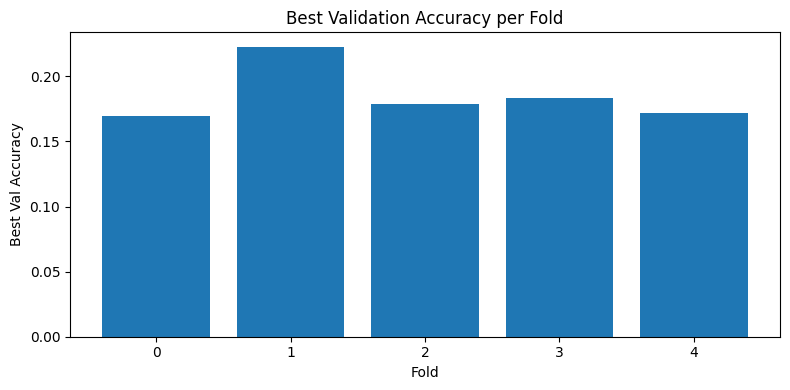

CV bar plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/cv_best_val_acc_per_fold.png
OOF probabilities salvate in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/validation_artifacts/oof_probabilities.csv
OOF probabilities shape: (2152, 54)
OOF predictions salvate in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/validation_artifacts/oof_predictions.csv
OOF predictions shape: (2152, 57)


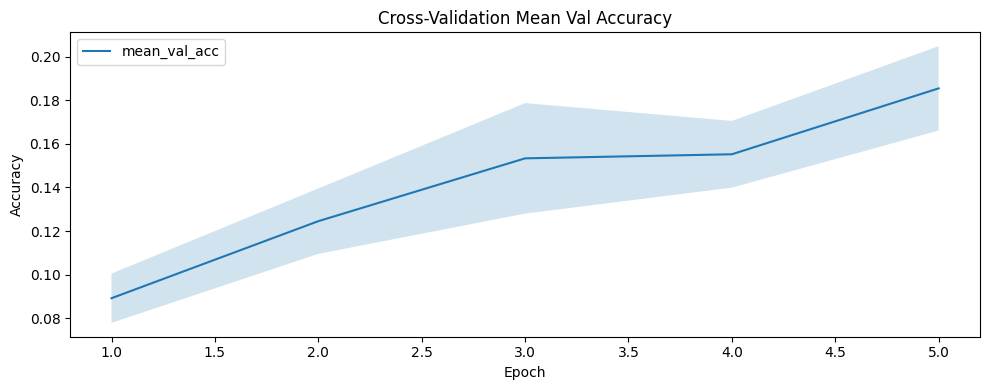

CV mean accuracy plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/cv_mean_val_acc.png


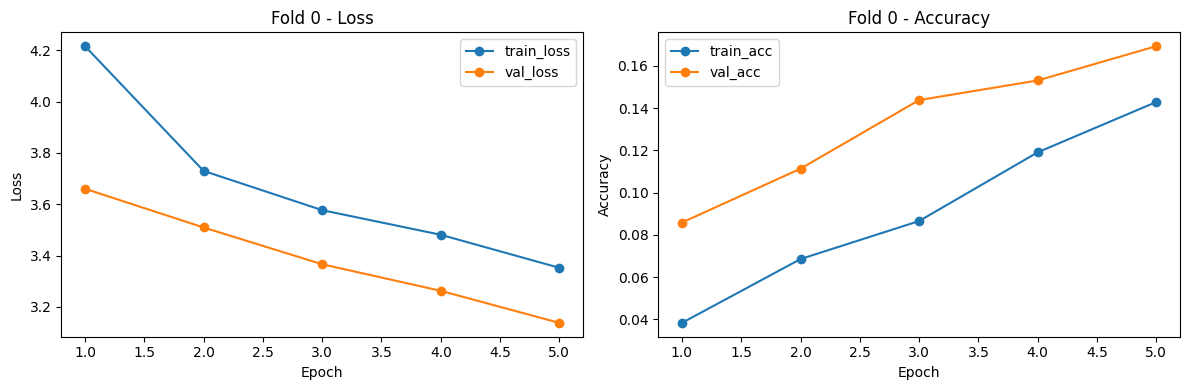

Plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_fold_0.png


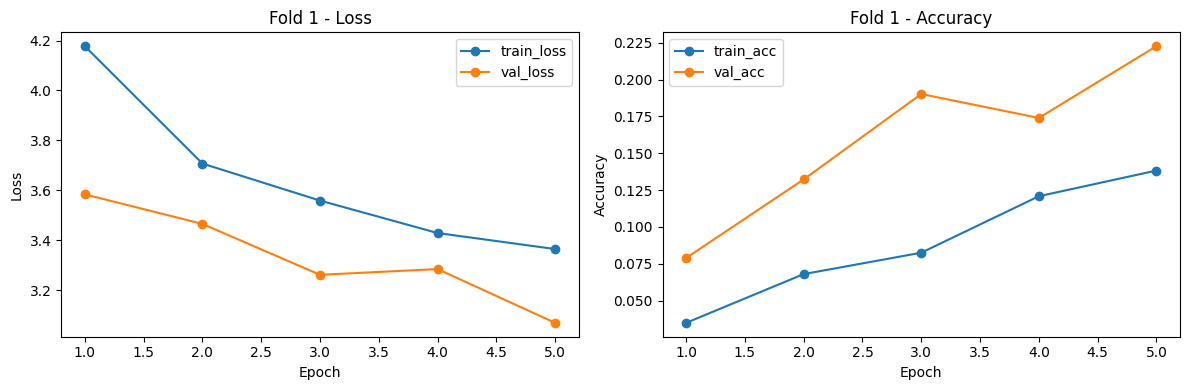

Plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_fold_1.png


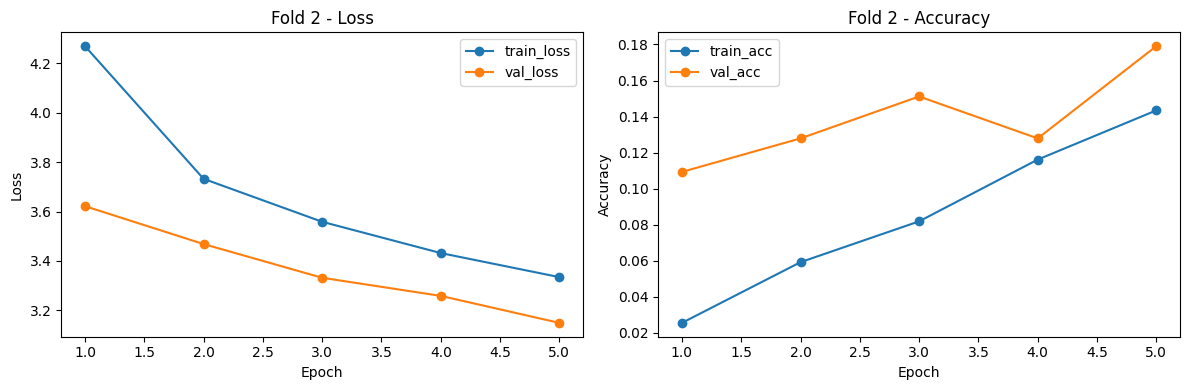

Plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_fold_2.png


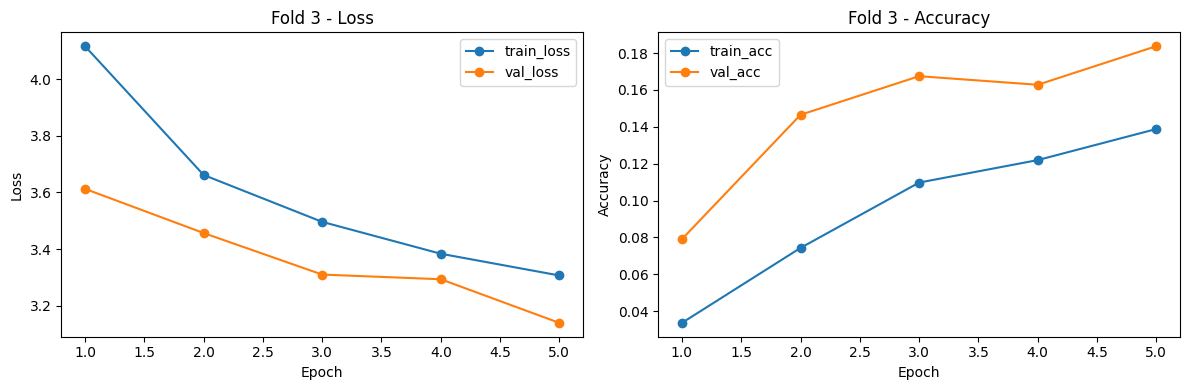

Plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_fold_3.png


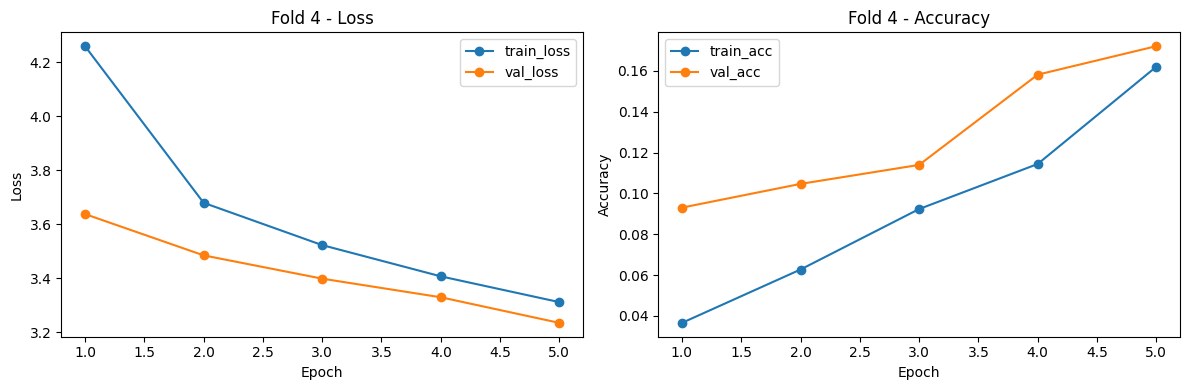

Plot salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_fold_4.png

===== FINAL REFIT SU TUTTO IL CV POOL =====
Train final size prima offline aug: 2152
NaN train final paths: 0
Train final size dopo eventuale offline aug: 2152
Precaricamento immagini in RAM...


Caching images:   0%|          | 0/2152 [00:00<?, ?it/s]

Precaricamento completato in 1.91 sec.
Scheduler final refit effettivo: plateau

Final Refit - Epoch 1/5


Training:   0%|          | 0/68 [00:00<?, ?it/s]

train_loss: 4.0877 | train_acc: 0.0455 | lr: 0.000100
epoch_time: 23.69 sec

Final Refit - Epoch 2/5


...

train_loss: 3.5310 | train_acc: 0.1018 | lr: 0.000100
epoch_time: 11.48 sec

Final Refit - Epoch 4/5


Training:   0%|          | 0/68 [00:00<?, ?it/s]

train_loss: 3.4167 | train_acc: 0.1283 | lr: 0.000100
epoch_time: 12.35 sec

Final Refit - Epoch 5/5


Training:   0%|          | 0/68 [00:00<?, ?it/s]

train_loss: 3.3229 | train_acc: 0.1431 | lr: 0.000100
epoch_time: 12.44 sec

Final refit model salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/models/resnet18_final_refit.pt
Final refit history salvata in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/histories/history_final_refit.csv
Final epoch usata: 5
Final train loss: 3.3229


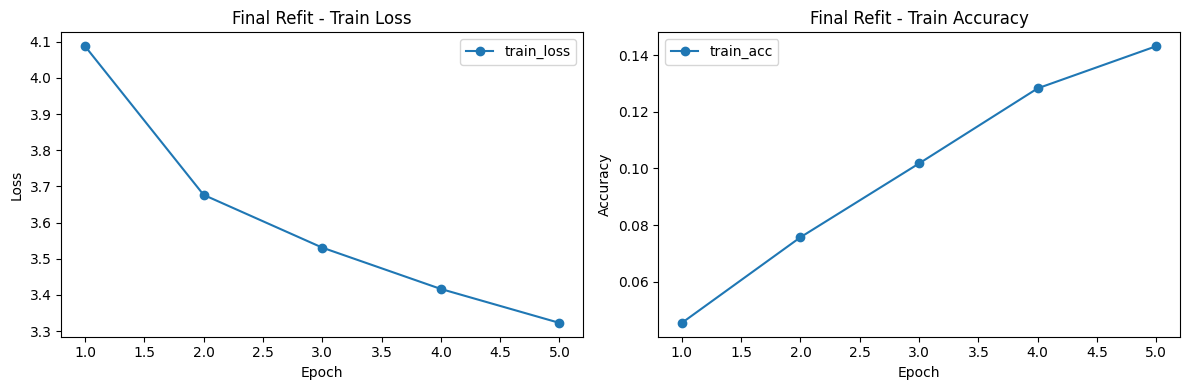

Plot history final refit salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_final_refit.png


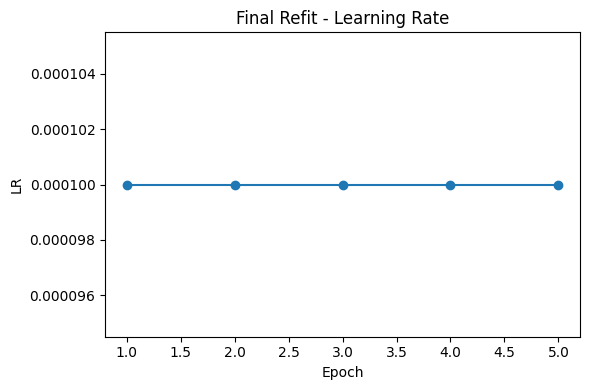

Plot LR final refit salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/plots/history_final_refit_lr.png


In [ ]:
# ============================================================
# 16. RISULTATI CROSS-VALIDATION, FINAL REFIT E GRAFICI
# ============================================================

df_cv_results = pd.DataFrame(cv_results)

cv_results_path = EXPERIMENT_DIR / "cv_results.csv"
df_cv_results.to_csv(cv_results_path, index=False, encoding="utf-8-sig")

print("\n===== RISULTATI CROSS-VALIDATION =====")
print("Mean best val accuracy:", df_cv_results["best_val_acc"].mean())
print("Std best val accuracy:", df_cv_results["best_val_acc"].std())
print("Best single fold accuracy:", df_cv_results["best_val_acc"].max())
print("Salvato in:", cv_results_path)

plt.figure(figsize=(8, 4))
plt.bar(df_cv_results["fold"].astype(str), df_cv_results["best_val_acc"])
plt.title("Best Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Best Val Accuracy")
plt.tight_layout()

cv_barplot_path = PLOTS_DIR / "cv_best_val_acc_per_fold.png"
plt.savefig(cv_barplot_path, bbox_inches="tight")
plt.show()

print("CV bar plot salvato in:", cv_barplot_path)

# ============================================================
# CREAZIONE OOF VALIDATION PREDICTIONS
# ============================================================

validation_artifacts_dir = EXPERIMENT_DIR / "validation_artifacts"

val_prob_files = sorted(validation_artifacts_dir.glob("probabilities_fold_*.csv"))
val_pred_files = sorted(validation_artifacts_dir.glob("predictions_fold_*.csv"))

if len(val_prob_files) > 0:
    df_oof_probs = pd.concat(
        [pd.read_csv(p) for p in val_prob_files],
        ignore_index=True
    )

    oof_prob_path = validation_artifacts_dir / "oof_probabilities.csv"
    df_oof_probs.to_csv(oof_prob_path, index=False, encoding="utf-8-sig")

    print("OOF probabilities salvate in:", oof_prob_path)
    print("OOF probabilities shape:", df_oof_probs.shape)

if len(val_pred_files) > 0:
    df_oof_preds = pd.concat(
        [pd.read_csv(p) for p in val_pred_files],
        ignore_index=True
    )

    oof_pred_path = validation_artifacts_dir / "oof_predictions.csv"
    df_oof_preds.to_csv(oof_pred_path, index=False, encoding="utf-8-sig")

    print("OOF predictions salvate in:", oof_pred_path)
    print("OOF predictions shape:", df_oof_preds.shape)

if history_all_folds:
    all_val_acc = []
    all_val_loss = []

    for fold_idx, history in history_all_folds.items():
        all_val_acc.append(history["val_acc"])
        all_val_loss.append(history["val_loss"])

    min_len = min(len(x) for x in all_val_acc)

    val_acc_mat = np.array([x[:min_len] for x in all_val_acc])
    mean_val_acc = val_acc_mat.mean(axis=0)
    std_val_acc = val_acc_mat.std(axis=0)

    epochs = np.arange(1, min_len + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, mean_val_acc, label="mean_val_acc")
    plt.fill_between(
        epochs,
        mean_val_acc - std_val_acc,
        mean_val_acc + std_val_acc,
        alpha=0.2
    )
    plt.title("Cross-Validation Mean Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()

    cv_mean_acc_path = PLOTS_DIR / "cv_mean_val_acc.png"
    plt.savefig(cv_mean_acc_path, bbox_inches="tight")
    plt.show()

    print("CV mean accuracy plot salvato in:", cv_mean_acc_path)

else:
    print("history_all_folds vuoto: salto i grafici medi per epoca.")

for fold_idx, history in history_all_folds.items():
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
    plt.title(f"Fold {fold_idx} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
    plt.title(f"Fold {fold_idx} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()

    plot_path = PLOTS_DIR / f"history_fold_{fold_idx}.png"
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Plot salvato in:", plot_path)

# ------------------------------------------------------------
# 16ter. FINAL REFIT SU TUTTO IL CV POOL
# ------------------------------------------------------------
final_model = None
final_refit_model_path = None
final_refit_history_path = None
best_final_epoch = None
best_final_train_loss = None
final_refit_plot_path = None
final_refit_lr_plot_path = None

if SAMPLING_MODE == "subsampling":
    # Dopo la 5-fold CV scegliamo il numero di epoche dal comportamento medio dei fold
    # e rialleniamo un modello finale su tutto il CV pool. Il test set resta separato.
    print("\n===== FINAL REFIT SU TUTTO IL CV POOL =====")

    train_final_df = df_cv_pool.copy().reset_index(drop=True)

    print("Train final size prima offline aug:", len(train_final_df))
    print("NaN train final paths:", train_final_df["image_path"].isna().sum())

    if SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE:
        final_aug_dir = EXPERIMENT_DIR / "offline_augmented_subsampling" / "final_refit"

        train_final_df = augment_subsampling_train_offline(
            df_train=train_final_df,
            aug_root=final_aug_dir,
            ratio=SUBSAMPLING_TRAIN_AUGMENT_RATIO,
            seed=SEED + 999
        )

        final_aug_meta_path = HISTORIES_DIR / "train_metadata_final_refit_with_offline_aug.csv"
        train_final_df.to_csv(final_aug_meta_path, index=False, encoding="utf-8-sig")
        print("Metadata train final refit con augmentation offline salvati in:", final_aug_meta_path)

    print("Train final size dopo eventuale offline aug:", len(train_final_df))

    train_final_dataset = ComicsDatasetCachedAugmented(
        df=train_final_df,
        image_size=IMAGE_SIZE,
        train=True,
        preload_to_ram=PRELOAD_TO_RAM,
        resize_mode=RESIZE_MODE
    )

    train_final_loader = make_loader(
        dataset=train_final_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    final_model, custom_init_final = build_model(
        model_name=MODEL_NAME,
        num_classes=NUM_CLASSES,
        use_pretrained=USE_PRETRAINED,
        transfer_mode=TRANSFER_MODE
    )
    final_model = final_model.to(device)

    if custom_init_final:
        final_model.apply(init_weights_custom)

    criterion_final = nn.CrossEntropyLoss()

    trainable_params_final = [p for p in final_model.parameters() if p.requires_grad]

    optimizer_final = build_optimizer(
        optimizer_name=OPTIMIZER_NAME,
        params=trainable_params_final,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_final = None
    effective_scheduler_name_final = "none"

    if LR_SCHEDULER_ENABLED:
        scheduler_final, effective_scheduler_name_final = build_lr_scheduler(
            optimizer=optimizer_final,
            scheduler_name=LR_SCHEDULER_NAME,
            model_name=MODEL_NAME,
            transfer_mode=TRANSFER_MODE,
            num_epochs=FINAL_NUM_EPOCHS,
            learning_rate=LEARNING_RATE,
            plateau_factor=LR_SCHEDULER_FACTOR,
            plateau_patience=LR_SCHEDULER_PATIENCE,
            plateau_min_lr=LR_SCHEDULER_MIN_LR,
            warmup_epochs=WARMUP_EPOCHS,
            cosine_min_lr=COSINE_MIN_LR,
        )

    print("Scheduler final refit effettivo:", effective_scheduler_name_final)

    final_history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "epoch_time_sec": [],
        "lr": []
    }

    for epoch in range(FINAL_NUM_EPOCHS):
        print(f"\nFinal Refit - Epoch {epoch+1}/{FINAL_NUM_EPOCHS}")
        epoch_start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            final_model, train_final_loader, criterion_final, optimizer_final, device, gradient_clipping_enabled=GRADIENT_CLIPPING_EFFECTIVE, gradient_clip_max_norm=GRADIENT_CLIP_MAX_NORM,
        )

        if scheduler_final is not None:
            step_lr_scheduler(
                scheduler=scheduler_final,
                scheduler_name=effective_scheduler_name_final,
                metric_value=train_loss,
                optimizer=optimizer_final,
                prefix="Final refit - "
            )

        current_lr = optimizer_final.param_groups[0]["lr"]
        epoch_time = time.time() - epoch_start_time

        final_history["epoch"].append(epoch + 1)
        final_history["train_loss"].append(train_loss)
        final_history["train_acc"].append(train_acc)
        final_history["epoch_time_sec"].append(epoch_time)
        final_history["lr"].append(current_lr)

        print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | lr: {current_lr:.6f}")
        print(f"epoch_time: {epoch_time:.2f} sec")

    best_final_epoch = FINAL_NUM_EPOCHS
    best_final_train_loss = final_history["train_loss"][-1] if len(final_history["train_loss"]) > 0 else None

    final_refit_model_path = MODELS_DIR / f"{MODEL_NAME}_final_refit.pt"
    torch.save(final_model.state_dict(), final_refit_model_path)

    final_refit_history_df = pd.DataFrame(final_history)
    final_refit_history_path = HISTORIES_DIR / "history_final_refit.csv"
    final_refit_history_df.to_csv(final_refit_history_path, index=False)

    print("\nFinal refit model salvato in:", final_refit_model_path)
    print("Final refit history salvata in:", final_refit_history_path)
    print(f"Final epoch usata: {best_final_epoch}")
    print(f"Final train loss: {best_final_train_loss:.4f}" if best_final_train_loss is not None else "Final train loss: None")

    epochs_final = range(1, len(final_history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_final, final_history["train_loss"], marker="o", label="train_loss")
    plt.title("Final Refit - Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_final, final_history["train_acc"], marker="o", label="train_acc")
    plt.title("Final Refit - Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()

    final_refit_plot_path = PLOTS_DIR / "history_final_refit.png"
    plt.savefig(final_refit_plot_path, bbox_inches="tight")
    plt.show()

    print("Plot history final refit salvato in:", final_refit_plot_path)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs_final, final_history["lr"], marker="o")
    plt.title("Final Refit - Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.tight_layout()

    final_refit_lr_plot_path = PLOTS_DIR / "history_final_refit_lr.png"
    plt.savefig(final_refit_lr_plot_path, bbox_inches="tight")
    plt.show()

    print("Plot LR final refit salvato in:", final_refit_lr_plot_path)

else:
    print("\n===== FINAL REFIT SKIPPATO =====")
    print("Preset upsampling: il training fixed appena eseguito è già il modello finale da testare.")


In [ ]:
# ============================================================
# 17. TEST FINALE, EXPLAINABILITY E FEATURE SPACE
# ============================================================

# Questa cella testa sempre il modello principale prodotto dal preset:
# - upsampling: il modello fixed allenato sul train upsampled;
# - subsampling: il best fold della CV e anche il modello final refit.
# Per il report finale, nel subsampling viene selezionato il final refit come risultato principale.

best_row = None
best_model_path = None
best_fold = None
selected_test_results = None
selected_test_artifacts = None
selected_test_model_type = None

test_dataset = ComicsDatasetCachedAugmented(
    df=df_test_final,
    image_size=IMAGE_SIZE,
    train=False,
    preload_to_ram=False,
    resize_mode=RESIZE_MODE
)

test_loader = make_loader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

criterion_test = nn.CrossEntropyLoss()

best_cv_test_results = None
final_refit_test_results = None

# ------------------------------------------------------------
# 17.1 Test del modello prodotto dalla fase CV/training fixed
# ------------------------------------------------------------
# Nel preset upsampling esiste una sola riga "fixed" in df_cv_results.
# Nel preset subsampling scegliamo invece il fold con migliore validation accuracy.

test_section_title = (
    "TEST SUL MODELLO FIXED UPSAMPLING"
    if SAMPLING_MODE == "upsampling"
    else "TEST SUL MIGLIOR MODELLO DELLA CV"
)

print(f"\n===== {test_section_title} =====")

best_row = df_cv_results.sort_values("best_val_acc", ascending=False).iloc[0]

model_path_local = Path(best_row["model_path_local"])
model_path_drive = (
    Path(best_row["model_path_drive"])
    if "model_path_drive" in best_row and pd.notna(best_row["model_path_drive"])
    else None
)

if model_path_local.exists():
    best_model_path = model_path_local
elif model_path_drive is not None and model_path_drive.exists():
    best_model_path = model_path_drive
else:
    raise FileNotFoundError(
        f"Modello non trovato né in locale né su Drive.\n"
        f"Local: {model_path_local}\n"
        f"Drive: {model_path_drive}"
    )

best_fold = best_row["fold"]

print("Best fold/run:", best_fold)
print("Best val accuracy:", best_row["best_val_acc"])
print("Best model path:", best_model_path)

best_cv_model, _ = build_model(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    use_pretrained=USE_PRETRAINED,
    transfer_mode=TRANSFER_MODE
)
best_cv_model = best_cv_model.to(device)
best_cv_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_start_time = time.time()

test_loss, test_acc, y_true, y_pred, y_prob = evaluate_with_predictions(
    best_cv_model, test_loader, criterion_test, device, desc="Test Best CV / Fixed Model"
)

test_time_sec = time.time() - test_start_time

best_cv_test_results = {
    "test_loss": test_loss,
    "test_acc": test_acc,
    "y_true": y_true,
    "y_pred": y_pred,
    "y_prob": y_prob,
    "test_time_sec": test_time_sec,
    "best_fold": best_fold,
    "best_row": best_row,
    "best_model_path": best_model_path,
    "total_params": sum(p.numel() for p in best_cv_model.parameters()),
    "trainable_params": sum(p.numel() for p in best_cv_model.parameters() if p.requires_grad),
}

test_model_label = "Upsampling fixed model" if SAMPLING_MODE == "upsampling" else "Best CV model"

print(f"{test_model_label} test loss: {test_loss:.4f}")
print(f"{test_model_label} test acc:  {test_acc:.4f}")
print(f"{test_model_label} test time: {test_time_sec:.2f} sec")

# ------------------------------------------------------------
# 17.2 Test del final refit, solo per il preset subsampling
# ------------------------------------------------------------
# Il final refit non usa validation durante il riallenamento finale: sfrutta tutto il CV pool
# e viene valutato una sola volta sul test set tenuto separato.

if SAMPLING_MODE == "subsampling":
    if final_model is None:
        raise ValueError("final_model non esiste: il final refit non è stato eseguito correttamente.")

    print("\n===== TEST SUL MODELLO FINAL REFIT =====")

    test_start_time = time.time()

    test_loss, test_acc, y_true, y_pred, y_prob = evaluate_with_predictions(
        final_model, test_loader, criterion_test, device, desc="Test Final Refit Model"
    )

    test_time_sec = time.time() - test_start_time

    final_refit_test_results = {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "test_time_sec": test_time_sec,
        "total_params": sum(p.numel() for p in final_model.parameters()),
        "trainable_params": sum(p.numel() for p in final_model.parameters() if p.requires_grad),
    }

    print(f"Final refit test loss: {test_loss:.4f}")
    print(f"Final refit test acc:  {test_acc:.4f}")
    print(f"Final refit test time: {test_time_sec:.2f} sec")

# ------------------------------------------------------------
# 17.3 Salvataggio artefatti del test
# ------------------------------------------------------------

best_cv_artifacts = None
final_refit_artifacts = None

best_cv_output_dir = EXPERIMENT_DIR / "test_artifacts_best_cv"
best_cv_test_tag = "upsampling_fixed" if SAMPLING_MODE == "upsampling" else "best_cv"
best_cv_artifacts = evaluate_and_save_test_artifacts(
    results_dict=best_cv_test_results,
    tag=best_cv_test_tag,
    output_dir=best_cv_output_dir,
    df_test_final=df_test_final,
    inv_label_map=inv_label_map,
    label_map=label_map,
    num_classes=NUM_CLASSES,
)

if final_refit_test_results is not None:
    final_refit_output_dir = EXPERIMENT_DIR / "test_artifacts_final_refit"
    final_refit_artifacts = evaluate_and_save_test_artifacts(
        results_dict=final_refit_test_results,
        tag="final_refit",
        output_dir=final_refit_output_dir,
        df_test_final=df_test_final,
        inv_label_map=inv_label_map,
        label_map=label_map,
        num_classes=NUM_CLASSES,
    )

# Il risultato principale del subsampling è il final refit; per upsampling è il fixed model.
if SAMPLING_MODE == "subsampling":
    selected_test_results = final_refit_test_results
    selected_test_artifacts = final_refit_artifacts
    selected_test_model_type = "final_refit"
else:
    selected_test_results = best_cv_test_results
    selected_test_artifacts = best_cv_artifacts
    selected_test_model_type = "upsampling_fixed"

print(f"\nRisultato principale selezionato per metriche/report: {selected_test_model_type}")

test_loss = selected_test_results["test_loss"]
test_acc = selected_test_results["test_acc"]
y_true = selected_test_results["y_true"]
y_pred = selected_test_results["y_pred"]
y_prob = selected_test_results["y_prob"]
test_time_sec = selected_test_results["test_time_sec"]
total_params = selected_test_results["total_params"]
trainable_params = selected_test_results["trainable_params"]

print("\n===== TEST SET PRINCIPALE =====")
print(f"Selected test model type: {selected_test_model_type}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test time: {test_time_sec:.2f} sec")

mean_cv_acc = df_cv_results["best_val_acc"].mean()
std_cv_acc = df_cv_results["best_val_acc"].std()
best_single_fold_acc = df_cv_results["best_val_acc"].max()

mean_epoch_time = df_cv_results["mean_epoch_time_sec"].mean()
total_cv_time = df_cv_results["fold_time_sec"].sum()
mean_train_preload_time = df_cv_results["train_preload_time_sec"].mean()
mean_val_preload_time = df_cv_results["val_preload_time_sec"].mean()

# ============================================================
# 17.4 GRAD-CAM / ATTENTION ROLLOUT AUTOMATICO
# ============================================================

def run_gradcam_for_available_tested_models():
    is_transformer_attention_model = (MODEL_NAME.startswith("vit") or MODEL_NAME.startswith("dinov2"))

    method_name = "attention_rollout" if is_transformer_attention_model else "gradcam"
    method_label = "Attention Rollout" if is_transformer_attention_model else "Grad-CAM"

    if is_transformer_attention_model:
        print("Modello Transformer/ViT rilevato: verrà usato Attention Rollout invece di Grad-CAM.")
    else:
        print("Modello CNN rilevato: verrà usato Grad-CAM.")

    gradcam_jobs = []

    if SAMPLING_MODE == "upsampling":
        gradcam_jobs.append({
            "tag": "upsampling_fixed",
            "model_path": MODELS_DIR / f"{MODEL_NAME}_fold_fixed.pt",
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_best_cv" / "test_predictions_upsampling_fixed.csv",
            "output_dir": PLOTS_DIR / f"{method_name}_upsampling_fixed"
        })

    if SAMPLING_MODE == "subsampling":
        if "df_cv_results" not in globals():
            raise RuntimeError("df_cv_results non disponibile: impossibile identificare il best fold.")

        best_row = df_cv_results.sort_values("best_val_acc", ascending=False).iloc[0]
        best_fold = best_row["fold"]

        gradcam_jobs.append({
            "tag": "best_cv",
            "model_path": MODELS_DIR / f"{MODEL_NAME}_fold_{best_fold}.pt",
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_best_cv" / "test_predictions_best_cv.csv",
            "output_dir": PLOTS_DIR / f"{method_name}_subsampling_best_cv"
        })

        gradcam_jobs.append({
            "tag": "final_refit",
            "model_path": MODELS_DIR / f"{MODEL_NAME}_final_refit.pt",
            "predictions_csv": EXPERIMENT_DIR / "test_artifacts_final_refit" / "test_predictions_final_refit.csv",
            "output_dir": PLOTS_DIR / f"{method_name}_subsampling_final_refit"
        })

    for job in gradcam_jobs:
        print(f"\n===== {method_label} [{job['tag']}] =====")
        print("Model path:", job["model_path"])
        print("Predictions CSV:", job["predictions_csv"])
        print("Output dir:", job["output_dir"])

        if not job["model_path"].exists():
            raise FileNotFoundError(f"Modello non trovato: {job['model_path']}")

        if not job["predictions_csv"].exists():
            raise FileNotFoundError(f"CSV predizioni non trovato: {job['predictions_csv']}")

        model, _ = build_model(
            model_name=MODEL_NAME,
            num_classes=NUM_CLASSES,
            use_pretrained=USE_PRETRAINED,
            transfer_mode=TRANSFER_MODE
        )

        model.load_state_dict(torch.load(job["model_path"], map_location=device))
        model = model.to(device)
        model.eval()

        if is_transformer_attention_model:
            generate_vit_attention_rollout_gallery(
                model=model,
                test_predictions_csv=job["predictions_csv"],
                output_dir=job["output_dir"],
                image_size=IMAGE_SIZE,
                top_k_best=20,
                top_k_worst=20,
                device=device,
                discard_ratio=0.0
            )
        else:
            generate_gradcam_gallery(
                model=model,
                model_name=MODEL_NAME,
                test_predictions_csv=job["predictions_csv"],
                output_dir=job["output_dir"],
                inv_label_map=inv_label_map,
                image_size=IMAGE_SIZE,
                top_k_best=20,
                top_k_worst=20,
                device=device
            )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


run_gradcam_for_available_tested_models()

run_feature_space_visualizations_for_available_tested_models()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# 20. RUN SUMMARY ED EXPORT FINALE
# ============================================================

# ------------------------------------------------------------
# 20.0 Utility per salvare dettagli optimizer/scheduler/early stopping
# ------------------------------------------------------------
def get_optimizer_summary(
    optimizer_name: str,
    learning_rate: float,
    weight_decay: float
):
    """
    Riassume gli iperparametri effettivi dell'optimizer usato.
    Deve essere coerente con build_optimizer().
    """
    optimizer_name = optimizer_name.lower()

    summary = {
        "optimizer_name": optimizer_name,
        "learning_rate": float(learning_rate),
        "weight_decay": float(weight_decay),
    }

    if optimizer_name == "sgd":
        summary.update({
            "momentum": 0.0,
            "nesterov": False,
        })

    elif optimizer_name == "sgd_momentum":
        summary.update({
            "momentum": 0.9,
            "nesterov": False,
        })

    elif optimizer_name == "nesterov":
        summary.update({
            "momentum": 0.9,
            "nesterov": True,
        })

    elif optimizer_name == "rmsprop":
        summary.update({
            "alpha": 0.99,
            "eps": 1e-8,
            "momentum": 0.0,
        })

    elif optimizer_name == "adagrad":
        summary.update({
            "eps": 1e-10,
        })

    elif optimizer_name == "adadelta":
        summary.update({
            "rho": 0.9,
            "eps": 1e-6,
        })

    elif optimizer_name in {"adam", "adamax", "amsgrad", "adamw"}:
        summary.update({
            "betas": [0.9, 0.999],
            "eps": 1e-8,
        })

        if optimizer_name == "amsgrad":
            summary["amsgrad"] = True
        else:
            summary["amsgrad"] = False

    return summary


def get_scheduler_summary():
    """
    Riassume lo scheduler configurato e quello effettivamente atteso.
    """
    try:
        expected_effective_scheduler = resolve_scheduler_name(
            scheduler_name=LR_SCHEDULER_NAME,
            model_name=MODEL_NAME,
            transfer_mode=TRANSFER_MODE
        )
    except Exception:
        expected_effective_scheduler = None

    return {
        "lr_scheduler_enabled": bool(LR_SCHEDULER_ENABLED),
        "lr_scheduler_name_config": LR_SCHEDULER_NAME,
        "lr_scheduler_name_effective_expected": expected_effective_scheduler,

        "plateau": {
            "factor": float(LR_SCHEDULER_FACTOR),
            "patience": int(LR_SCHEDULER_PATIENCE),
            "min_lr": float(LR_SCHEDULER_MIN_LR),
            "monitor": "val_loss",
            "mode": "min",
            "used_when": "scheduler effettivo = plateau",
        },

        "warmup_cosine": {
            "warmup_epochs": int(WARMUP_EPOCHS),
            "cosine_min_lr": float(COSINE_MIN_LR),
            "base_learning_rate": float(LEARNING_RATE),
            "step_granularity": "epoch",
            "used_when": "scheduler effettivo = warmup_cosine",
        },
    }


def get_early_stopping_summary():
    """
    Riassume la logica di early stopping.
    Nel tuo training loop il miglior modello viene scelto su val_acc.
    """
    return {
        "early_stopping_enabled": bool(EARLY_STOPPING_ENABLED),
        "monitor": "val_acc",
        "mode": "max",
        "patience": int(EARLY_STOPPING_PATIENCE),
        "min_delta": float(EARLY_STOPPING_MIN_DELTA),
        "restore_best_weights": True,
        "restore_best_weights_note": (
            "Il codice salva best_model_wts quando val_acc migliora "
            "e alla fine ricarica model.load_state_dict(best_model_wts)."
        ),
    }


def get_gradient_clipping_summary():
    return {
        "gradient_clipping_enabled_config": bool(GRADIENT_CLIPPING_ENABLED),
        "gradient_clipping_mode": GRADIENT_CLIPPING_MODE,
        "gradient_clipping_effective": bool(GRADIENT_CLIPPING_EFFECTIVE),
        "gradient_clip_max_norm": float(GRADIENT_CLIP_MAX_NORM),
    }


run_summary = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "sampling_mode": SAMPLING_MODE,
    "device": str(device),

    "label_mapping": {str(k): v for k, v in inv_label_map.items()},

    "config": {
        "fast_dev_run": FAST_DEV_RUN,
        "use_pretrained": USE_PRETRAINED,
        "transfer_mode": TRANSFER_MODE,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMAGE_SIZE,
        "resize_mode": RESIZE_MODE,
        "optimizer_name": OPTIMIZER_NAME,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": get_optimizer_summary(optimizer_name=OPTIMIZER_NAME,learning_rate=LEARNING_RATE,weight_decay=WEIGHT_DECAY ),
        "scheduler": get_scheduler_summary(),
        "early_stopping": get_early_stopping_summary(),
        "gradient_clipping": get_gradient_clipping_summary(),
        "early_stopping_enabled": bool(EARLY_STOPPING_ENABLED),
        "early_stopping_patience": int(EARLY_STOPPING_PATIENCE),
        "early_stopping_min_delta": float(EARLY_STOPPING_MIN_DELTA),

        "lr_scheduler_enabled": bool(LR_SCHEDULER_ENABLED),
        "lr_scheduler_patience": int(LR_SCHEDULER_PATIENCE),
        "lr_scheduler_factor": float(LR_SCHEDULER_FACTOR),
        "lr_scheduler_min_lr": float(LR_SCHEDULER_MIN_LR),
        "subsampling_train_augment_offline": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE),
        "subsampling_train_augment_offline_effective": bool(SUBSAMPLING_TRAIN_AUGMENT_OFFLINE_EFFECTIVE),
        "subsampling_train_augment_ratio": float(SUBSAMPLING_TRAIN_AUGMENT_RATIO),
        "num_classes": NUM_CLASSES,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "preload_to_ram": PRELOAD_TO_RAM,

        "protocol": "subsampling_cv_plus_final_refit" if SAMPLING_MODE == "subsampling" else "upsampling_fixed_train_test",
        "runs_kfold_cv": bool(SAMPLING_MODE == "subsampling"),
        "runs_final_refit": bool(SAMPLING_MODE == "subsampling"),
        "tests_fixed_or_best_cv_model": True,
        "tests_final_refit_model": bool(SAMPLING_MODE == "subsampling"),
        "original_dataset_root": str(ORIGINAL_DATASET_ROOT),
        "effective_dataset_root": str(DATASET_ROOT),

        "folds_run": (
            [int(x) for x in FOLDS_TO_RUN]
            if SAMPLING_MODE == "subsampling"
            else ["fixed"]
        ),

        "selected_hparams": {
            k: (
                int(v) if isinstance(v, np.integer)
                else float(v) if isinstance(v, np.floating)
                else v
            )
            for k, v in HPARAMS.items()
        },
    },

    "cv": {
        "mean_cv_best_val_acc": float(mean_cv_acc),
        "std_cv_best_val_acc": float(std_cv_acc),
        "best_single_fold_acc": float(best_single_fold_acc),
        "best_fold": None if best_cv_test_results is None else (
            int(best_cv_test_results["best_fold"])
            if SAMPLING_MODE == "subsampling"
            else best_cv_test_results["best_fold"]
        ),
        "best_epoch": None if best_cv_test_results is None else int(best_cv_test_results["best_row"]["best_epoch"]),
    },

    "final_refit": {
        "run_final_refit": bool(SAMPLING_MODE == "subsampling"),
        "final_num_epochs": None if SAMPLING_MODE != "subsampling" else int(FINAL_NUM_EPOCHS),
        "final_epoch_used": None if best_final_epoch is None else int(best_final_epoch),
        "final_train_loss": None if best_final_train_loss is None else float(best_final_train_loss),
        "final_refit_model_path_local": None if final_refit_model_path is None else str(final_refit_model_path),
        "final_refit_history_path_local": None if final_refit_history_path is None else str(final_refit_history_path),
        "final_refit_plot_path_local": None if final_refit_plot_path is None else str(final_refit_plot_path),
        "final_refit_lr_plot_path_local": None if final_refit_lr_plot_path is None else str(final_refit_lr_plot_path),
    },

    "test": {
        "selected_test_model_type": selected_test_model_type,
        "tested_fixed_or_best_cv_model": True,
        "tested_final_refit_model": bool(SAMPLING_MODE == "subsampling"),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "top3_acc": float(selected_test_artifacts["top3_acc"]),
        "top5_acc": float(selected_test_artifacts["top5_acc"]),
        "precision_macro": float(selected_test_artifacts["precision_macro"]),
        "recall_macro": float(selected_test_artifacts["recall_macro"]),
        "f1_macro": float(selected_test_artifacts["f1_macro"]),
        "precision_weighted": float(selected_test_artifacts["precision_weighted"]),
        "recall_weighted": float(selected_test_artifacts["recall_weighted"]),
        "f1_weighted": float(selected_test_artifacts["f1_weighted"]),
        "balanced_accuracy": float(selected_test_artifacts["balanced_accuracy"]),
        "log_loss": float(selected_test_artifacts["log_loss"]),
    },

    "test_artifacts": {
        "best_cv": best_cv_artifacts,
        "final_refit": final_refit_artifacts,
    },

    "model": {
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "best_model_path_used": None if best_cv_test_results is None else str(best_cv_test_results["best_model_path"]),
        "best_model_path_drive": None if best_cv_test_results is None or "model_path_drive" not in best_cv_test_results["best_row"] else str(best_cv_test_results["best_row"]["model_path_drive"]),
        "final_refit_model_path_local": None if final_refit_model_path is None else str(final_refit_model_path),
    },

    "timing": {
        "mean_epoch_time_sec": float(mean_epoch_time),
        "total_cv_time_sec": float(total_cv_time),
        "mean_train_preload_time_sec": float(mean_train_preload_time),
        "mean_val_preload_time_sec": float(mean_val_preload_time),
        "test_time_sec": float(test_time_sec),
    },

    "files": {
        "cv_results": "cv_results.csv",
        "final_refit_history_csv": None if final_refit_history_path is None else Path(final_refit_history_path).name,
        "final_refit_history_plot": None if final_refit_plot_path is None else Path(final_refit_plot_path).name,
        "final_refit_lr_plot": None if final_refit_lr_plot_path is None else Path(final_refit_lr_plot_path).name,
    },
}

def json_converter(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

run_summary_path = EXPERIMENT_DIR / "run_summary.json"
with open(run_summary_path, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2, ensure_ascii=False, default=json_converter)

print("Run summary salvato in:", run_summary_path)


Run summary salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/run_summary.json


In [ ]:
# ============================================================
# 21. ANALISI ARCHITETTURA MODELLO
# ============================================================

# ------------------------------------------------------------
# 21.1 Torchinfo summary
# ------------------------------------------------------------
from torchinfo import summary

model, _ = build_model(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    use_pretrained=USE_PRETRAINED,
    transfer_mode=TRANSFER_MODE
)

model_summary = summary(
    model,
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=4,
    verbose=0
)

print(model_summary)

summary_path = EXPERIMENT_DIR / "architecture_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(str(model_summary))

print("Architecture summary salvata in:", summary_path)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet18Scratch                          [1, 3, 224, 224]          [1, 46]                   --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    │ 

Architecture graph salvato in: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736/architecture_graph.png


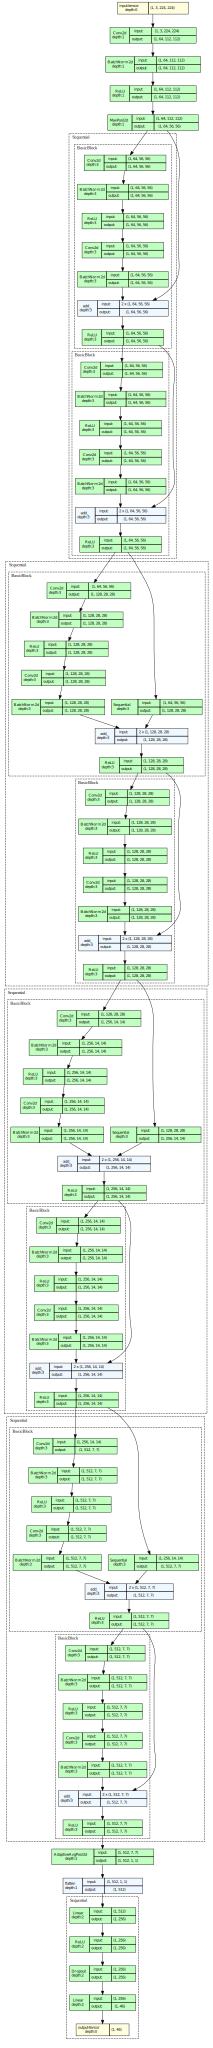

In [ ]:
# ------------------------------------------------------------
# 21.2 Torchview graph
# ------------------------------------------------------------

from torchview import draw_graph

model_for_graph, _ = build_model(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    use_pretrained=USE_PRETRAINED,
    transfer_mode=TRANSFER_MODE
)

graph = draw_graph(
    model_for_graph,
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
    expand_nested=True,
    save_graph=True,
    directory=str(EXPERIMENT_DIR),
    filename="architecture_graph"
)

print("Architecture graph salvato in:", EXPERIMENT_DIR / "architecture_graph.png")
graph.visual_graph

In [ ]:
# ============================================================
# 22. SYNC FINALE E CHIUSURA SESSIONE
# ============================================================

# ------------------------------------------------------------
# 22.1 Sync finale su Drive
# ------------------------------------------------------------
sync_dir_to_drive(
    local_dir=EXPERIMENT_DIR,
    drive_dir=DRIVE_EXPERIMENTS_ROOT / RUN_NAME,
    exclude_dirs=["_tmp_offline_augmented_subsampling"]
)

tmp_aug_dir = EXPERIMENT_DIR / "_tmp_offline_augmented_subsampling"

if tmp_aug_dir.exists():
    shutil.rmtree(tmp_aug_dir)
    print("Cartella augmentation temporanea rimossa:", tmp_aug_dir)


[SYNC] La directory di destinazione esiste già: /content/drive/MyDrive/Dataset Fargetta_224x224/results/subsampling/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736
[SYNC] I file con lo stesso nome verranno sovrascritti.
[SYNC] Copia file su Drive in corso...
[SYNC] Copia completata: 188 file
[SYNC] File saltati: 0
  da: /content/results/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736
  a:  /content/drive/MyDrive/Dataset Fargetta_224x224/results/subsampling/resnet18/resnet18_scratch_original_cv_plus_final_refit_full_20260616_232736


In [ ]:
# ============================================================
# CLEANUP FINALE DEL RUN
# ============================================================

vars_to_delete = [
    # modelli / ottimizzazione
    "model", "optimizer", "criterion",
    "best_cv_model", "final_model",
    "criterion_test", "criterion_final",
    "optimizer_final", "scheduler_final",

    # dataset / loader
    "train_dataset", "val_dataset", "test_dataset",
    "train_loader", "val_loader", "test_loader",
    "train_final_dataset", "train_final_loader",

    # smoke test
    "images_batch", "labels_batch", "outputs_smoke",
    "model_smoke", "train_dataset_smoke", "train_loader_smoke",

    # risultati CV / refit
    "cv_results", "df_cv_results", "history_all_folds",
    "final_history", "final_refit_history_df",
    "best_model_wts", "best_final_model_wts",

    # risultati test
    "best_cv_test_results", "final_refit_test_results",
    "best_cv_artifacts", "final_refit_artifacts",
    "selected_test_results", "selected_test_artifacts",

    # predizioni / metriche
    "y_true", "y_pred", "y_prob",
    "test_pred_df", "df_class_metrics",
    "cm_df", "cm_norm_df",
    "report_dict", "y_true_np", "y_pred_np",

    # variabili varie
    "best_row", "best_model_path", "best_fold",
    "hist_df", "train_df", "val_df", "train_final_df"
]

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("🧹 Cleanup finale del run completato")

🧹 Cleanup finale del run completato
